# Эксперименты с ковариацией для Improving Adversarial Transferability via Neuron Attribution-Based Attacks

Этот ноутбук вынесен из `ImprovingAdvTransViaAttrib.ipynb` и содержит только базовую инициализацию и эксперименты, связанные с covariance-term.


### Импорты и базовая конфигурация
Подключаем библиотеки, включаем градиенты и определяем устройство для вычислений.


In [21]:
import math
import gc

import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO
from torch.func import jvp

torch.set_grad_enabled(True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu")
DTYPE = torch.float32

print("device:", DEVICE)
print("torch:", torch.__version__)

device: mps
torch: 2.9.1


### Загрузка модели классификации
Инициализируем YOLO-классификатор, переводим модель на нужное устройство и проверяем классы.


In [22]:
# Загрузка классификатора
yolo = YOLO("yolo11s-cls.pt")
model = yolo.model.to(DEVICE).eval()
class_names = yolo.names

print(type(model).__name__)
print("num classes:", len(class_names))
print("first 10 classes:", {k: class_names[k] for k in range(10)})

ClassificationModel
num classes: 1000
first 10 classes: {0: 'tench', 1: 'goldfish', 2: 'great_white_shark', 3: 'tiger_shark', 4: 'hammerhead', 5: 'electric_ray', 6: 'stingray', 7: 'cock', 8: 'hen', 9: 'ostrich'}


### Подготовка входа и служебные утилиты
Определяем размер изображения, функции загрузки/препроцессинга и очистки кэша backend.


In [23]:
IMG_SIZE = 224
DEFAULT_LAYER_NAME = "model.9"

def load_image(path, img_size=IMG_SIZE, pad_value=0.0):
    """Load an image, apply letterbox-style resizing, and return both tensor and padded RGB array."""
    img = Image.open(path).convert("RGB")
    img_np = np.asarray(img).astype(np.float32) / 255.0
    h, w = img_np.shape[:2]
    if h == 0 or w == 0:
        raise ValueError(f"Некорректный размер изображения: {(h, w)}")

    scale = img_size / max(h, w)
    new_h = max(1, int(round(h * scale)))
    new_w = max(1, int(round(w * scale)))

    resized = np.asarray(
        Image.fromarray((img_np * 255).astype(np.uint8)).resize((new_w, new_h), Image.Resampling.BILINEAR)
    ).astype(np.float32) / 255.0

    canvas = np.full((img_size, img_size, 3), pad_value, dtype=np.float32)
    top = (img_size - new_h) // 2
    left = (img_size - new_w) // 2
    canvas[top:top + new_h, left:left + new_w] = resized

    x = torch.from_numpy(canvas).permute(2, 0, 1).unsqueeze(0).to(DEVICE, DTYPE)
    return x, canvas


def black_baseline_like(x):
    """Create a zero baseline tensor with the same shape and device as the input."""
    return torch.zeros_like(x)

def list_named_modules(model):
    """Return all non-empty named submodules of the given model."""
    return [(name, module) for name, module in model.named_modules() if name != ""]

def clear_backend_cache():
    """Trigger Python garbage collection and clear CUDA/MPS caches when available."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    if hasattr(torch, "mps") and torch.mps.is_available():
        try:
            torch.mps.empty_cache()
        except Exception:
            pass

def print_named_modules_detailed(model, max_name_len=45):
    """Print a detailed list of all named submodules with their types."""
    rows = []
    for name, module in model.named_modules():
        if name == "":
            continue
        rows.append((name, type(module).__name__))

    print(f"{'idx':>4}  {'module name':<{max_name_len}}  type")
    print("-" * (max_name_len + 20))
    for i, (name, typ) in enumerate(rows):
        short_name = name if len(name) <= max_name_len else name[:max_name_len - 3] + "..."
        print(f"{i:4d}  {short_name:<{max_name_len}}  {typ}")

    return rows


all_modules = print_named_modules_detailed(model)

 idx  module name                                    type
-----------------------------------------------------------------
   0  model                                          Sequential
   1  model.0                                        Conv
   2  model.0.conv                                   Conv2d
   3  model.0.bn                                     BatchNorm2d
   4  model.0.act                                    SiLU
   5  model.1                                        Conv
   6  model.1.conv                                   Conv2d
   7  model.1.bn                                     BatchNorm2d
   8  model.2                                        C3k2
   9  model.2.cv1                                    Conv
  10  model.2.cv1.conv                               Conv2d
  11  model.2.cv1.bn                                 BatchNorm2d
  12  model.2.cv2                                    Conv
  13  model.2.cv2.conv                               Conv2d
  14  model.2.cv2.bn         

### Хуки, парсинг выходов и визуализация
Добавляем вспомогательные функции для получения активаций слоя, агрегации и построения карт attribution.


In [24]:
# Вспомогательные утилиты для layer hook, output parsing и plotting

def split_classifier_output(out):
    """Normalize classifier output into a tuple of optional probabilities and logits tensor."""
    if isinstance(out, (tuple, list)):
        if len(out) >= 2 and torch.is_tensor(out[1]):
            return out[0], out[1]
        if len(out) >= 1 and torch.is_tensor(out[0]):
            return None, out[0]
    if torch.is_tensor(out):
        return None, out
    raise TypeError(f"Не удалось интерпретировать output классификатора типа {type(out).__name__}")

def unwrap_tensor(output):
    """Extract the first tensor object from a model output container."""
    if torch.is_tensor(output):
        return output
    if isinstance(output, (list, tuple)):
        for item in output:
            if torch.is_tensor(item):
                return item
    raise TypeError(f"Не удалось извлечь tensor activation из output типа {type(output).__name__}")

class LayerHook:
    def __init__(self, model, layer_name):
        """Initialize a forward hook for the selected layer and allocate activation storage."""
        self.layer_name = layer_name
        self.layer_store = {}
        modules = dict(model.named_modules())
        if layer_name not in modules:
            raise KeyError(f"Слой '{layer_name}' не найден в model.named_modules()")
        self.handle = modules[layer_name].register_forward_hook(self._hook)

    def _hook(self, module, inp, out):
        """Store the latest hooked layer output during forward execution."""
        self.layer_store[self.layer_name] = out

    def clear(self):
        """Clear cached layer activations from the hook storage."""
        self.layer_store.clear()

    def get(self):
        """Return the latest cached activation for the hooked layer."""
        return self.layer_store[self.layer_name]

    def remove(self):
        """Detach the forward hook from the model layer."""
        self.handle.remove()

def reduce_filter_scores(cond_tensor):
    """Aggregate attribution over non-filter axes to produce one score per filter."""
    if cond_tensor.ndim < 2:
        raise ValueError(
            f"Ожидался tensor с batch-осью и хотя бы одной feature-осью, получено shape={tuple(cond_tensor.shape)}"
        )

    per_sample = cond_tensor[0]
    if per_sample.ndim == 1:
        return per_sample

    reduce_dims = tuple(range(1, per_sample.ndim))
    return per_sample.sum(dim=reduce_dims)

def _normalize_map(arr):
    """Normalize a 2D map by its maximum absolute value for stable visualization."""
    arr = arr.astype(np.float32)
    max_abs = np.max(np.abs(arr))
    if max_abs > 0:
        arr = arr / max_abs
    return arr

def _resize_map_nearest(arr, out_hw):
    # Без сглаживания: nearest-neighbor upsampling
    """Resize a 2D map to target height and width using nearest-neighbor sampling."""
    h_out, w_out = out_hw
    h_in, w_in = arr.shape

    row_idx = np.floor(np.arange(h_out) * (h_in / h_out)).astype(int)
    col_idx = np.floor(np.arange(w_out) * (w_in / w_out)).astype(int)

    row_idx = np.clip(row_idx, 0, h_in - 1)
    col_idx = np.clip(col_idx, 0, w_in - 1)

    return arr[row_idx][:, col_idx]

def plot_total_attribution_overlay(image_np, cond_tensor, title=None):
    """Plot an image with an overlay of total spatial attribution summed over filters."""
    cond_np = cond_tensor[0].detach().cpu().numpy()

    if cond_np.ndim < 3:
        print("Общий spatial plot пропущен: у слоя нет пространственных осей.")
        return

    # Общая spatial attribution:
    # сумма по фильтрам |Cond_{c,h,w}|
    total_map = cond_np.sum(axis=0)
    total_map = _normalize_map(total_map)
    total_map = _resize_map_nearest(total_map, image_np.shape[:2])

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(image_np, interpolation="nearest")
    heat = ax.imshow(total_map, cmap="seismic", vmin=-1.0, vmax=1.0, alpha=0.45, interpolation="nearest")
    ax.axis("off")
    ax.set_title(title or "Total attribution overlay")

    cbar = fig.colorbar(heat, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Normalized attribution", rotation=90)

    plt.show()

def plot_top_filter_overlays(image_np, cond_tensor, filter_scores, top_idx, top_n=5):
    """Plot attribution overlays for the top-ranked filters on the input image."""
    cond_np = cond_tensor[0].detach().cpu().numpy()

    if cond_np.ndim < 3:
        print("Spatial overlays для отдельных фильтров пропущены: у слоя нет пространственных осей.")
        return

    top_n = min(top_n, len(top_idx))

    for rank, idx in enumerate(top_idx[:top_n].tolist(), start=1):
        fmap = cond_np[idx]
        fmap = _normalize_map(fmap)
        fmap = _resize_map_nearest(fmap, image_np.shape[:2])

        plt.figure(figsize=(6, 6))
        plt.imshow(image_np, interpolation="nearest")
        plt.imshow(fmap, cmap="seismic", vmin=-1.0, vmax=1.0, alpha=0.45, interpolation="nearest")
        plt.title(f"Filter {idx} attribution = {float(filter_scores[idx]):+.6f} (rank {rank})")
        plt.show()

## Проверка предположения о нулевой ковариации

In [25]:
def compute_zero_covariance_diagnostics(
    model,
    hook,
    x,
    x0,
    target_class,
    n_steps=30,
    clear_every=8,
):
    """
    Численно проверяет предположение о нулевой ковариации:
    cov_j = mean_m[a_m^{(j)} b_m^{(j)}] - mean_m[a_m^{(j)}] mean_m[b_m^{(j)}]
    для каждого нейрона выбранного слоя.
    """
    x = x.contiguous()
    x0 = x0.contiguous()
    delta_x = (x - x0).contiguous()

    def forward_with_layer(x_in):
        hook.clear()
        out = model(x_in)
        act = unwrap_tensor(hook.get())
        return out, act

    def layer_activation(x_in):
        _, act = forward_with_layer(x_in)
        return act

    a_seq = []
    b_seq = []

    for m in range(1, n_steps + 1):
        alpha = m / n_steps
        x_alpha = (x0 + alpha * delta_x).contiguous().detach().requires_grad_(True)

        # a_m = dF/dy (в точке x_alpha)
        out, act = forward_with_layer(x_alpha)
        _, logits = split_classifier_output(out)
        score = logits[0, target_class]
        grad_y = torch.autograd.grad(score, act, retain_graph=False, create_graph=False)[0]

        # b_m = sum_i (x_i - x'_i) * dy/dx_i
        # это directional derivative слоя по направлению delta_x
        hook.clear()
        _, jvp_out = jvp(layer_activation, (x_alpha,), (delta_x,))
        dir_y = jvp_out.detach()

        a_seq.append(grad_y.detach())
        b_seq.append(dir_y)

        del x_alpha, out, act, logits, score, grad_y, jvp_out, dir_y
        hook.clear()

        if m % clear_every == 0:
            clear_backend_cache()

    a_seq = torch.stack(a_seq, dim=0)   # [n_steps, ...layer_shape]
    b_seq = torch.stack(b_seq, dim=0)   # [n_steps, ...layer_shape]

    mean_a = a_seq.mean(dim=0)
    mean_b = b_seq.mean(dim=0)
    mean_ab = (a_seq * b_seq).mean(dim=0)

    cov = mean_ab - mean_a * mean_b
    cov_flat = cov.detach().reshape(-1)

    stats = {
        "cov_tensor": cov.detach(),
        "cov_flat": cov_flat,
        "mean_abs_cov": float(cov.abs().mean().item()),
        "max_abs_cov": float(cov.abs().max().item()),
        "mean_cov": float(cov.mean().item()),
        "var_cov": float(cov_flat.var(unbiased=False).item()),
        "std_cov": float(cov_flat.std(unbiased=False).item()),
        "sum_cov": float(cov.sum().item()),
        "sum_exact_mean_ab": float(mean_ab.sum().item()),
        "sum_prod_of_means": float((mean_a * mean_b).sum().item()),
    }
    clear_backend_cache()
    return stats

def plot_covariance_diagnostics(cov_stats, top_k=50):
    cov_flat = cov_stats["cov_flat"].detach().cpu().numpy()
    abs_sorted_idx = np.argsort(np.abs(cov_flat))[::-1]
    top_k = min(top_k, len(cov_flat))

    plt.figure(figsize=(8, 5))
    plt.hist(cov_flat, bins=60)
    plt.xlabel("Covariance value")
    plt.ylabel("Count")
    plt.title("Distribution of per-neuron covariance values")
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(np.sort(cov_flat))
    plt.xlabel("Neuron index after sorting by covariance")
    plt.ylabel("Covariance")
    plt.title("Sorted per-neuron covariance values")
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.bar(np.arange(top_k), cov_flat[abs_sorted_idx[:top_k]])
    plt.xlabel("Rank by |covariance|")
    plt.ylabel("Covariance")
    plt.title(f"Top-{top_k} neurons by |covariance|")
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()

def run_zero_covariance_analysis(
    image_path,
    layer_name,
    n_steps=128,
    clear_every=8,
    top_k=50,
):
    x, _ = load_image(image_path)
    x0 = black_baseline_like(x)

    hook = LayerHook(model, layer_name)
    try:
        hook.clear()
        out = model(x)
        _, logits = split_classifier_output(out)
        target_class = int(logits[0].argmax().item())
        target_name = class_names[target_class]

        cov_stats = compute_zero_covariance_diagnostics(
            model=model,
            hook=hook,
            x=x,
            x0=x0,
            target_class=target_class,
            n_steps=n_steps,
            clear_every=clear_every,
        )
    finally:
        hook.remove()
        clear_backend_cache()

    print("image:", image_path)
    print("layer:", layer_name)
    print("target class:", target_class, target_name)
    print("n_steps:", n_steps)
    print("mean |cov|         =", cov_stats["mean_abs_cov"])
    print("max  |cov|         =", cov_stats["max_abs_cov"])
    print("mean cov           =", cov_stats["mean_cov"])
    print("var  cov           =", cov_stats["var_cov"])
    print("std  cov           =", cov_stats["std_cov"])
    print("sum cov            =", cov_stats["sum_cov"])
    print("sum mean(a*b)      =", cov_stats["sum_exact_mean_ab"])
    print("sum mean(a)mean(b) =", cov_stats["sum_prod_of_means"])

    plot_covariance_diagnostics(cov_stats, top_k=top_k)

    return {
        "image_path": image_path,
        "layer_name": layer_name,
        "target_class": target_class,
        "target_name": target_name,
        "n_steps": n_steps,
        "cov_stats": cov_stats,
        "x": x.detach(),
        "x0": x0.detach(),
    }

image: data/jess.jpg
layer: model.5
target class: 151 Chihuahua
n_steps: 128
mean |cov|         = 0.0026986771263182163
max  |cov|         = 0.4904577136039734
mean cov           = 0.00028983462834730744
var  cov           = 7.321194425458089e-05
std  cov           = 0.008556397631764412
sum cov            = 14.542742729187012
sum mean(a*b)      = 10.906742095947266
sum mean(a)mean(b) = -3.6360013484954834


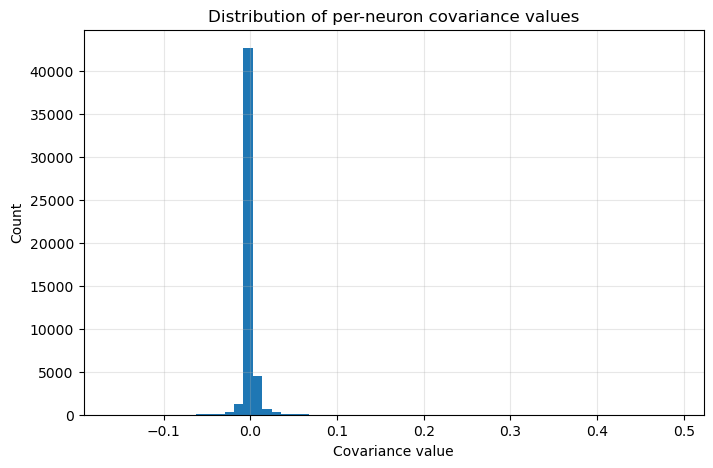

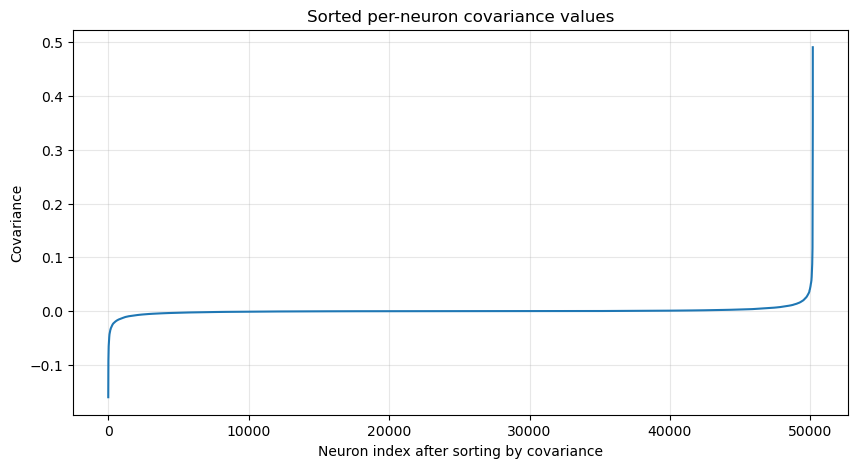

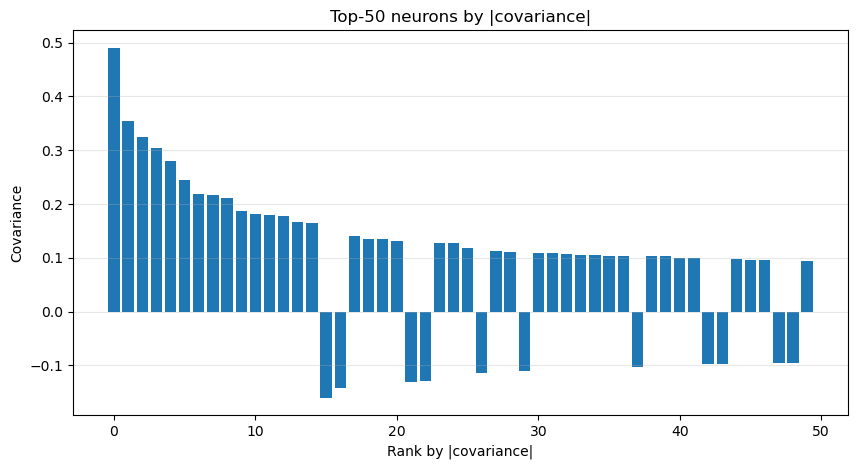

In [26]:
cov_result = run_zero_covariance_analysis(
    image_path="data/jess.jpg",
    layer_name="model.5",
    n_steps=128,
    clear_every=8,
    top_k=50,
)

image: data/jess.jpg
layer: model.6
target class: 151 Chihuahua
n_steps: 128
mean |cov|         = 0.0022126897238194942
max  |cov|         = 0.44253724813461304
mean cov           = 0.0002546297328080982
var  cov           = 6.501132156699896e-05
std  cov           = 0.008062959648668766
sum cov            = 12.776302337646484
sum mean(a*b)      = 10.906742095947266
sum mean(a)mean(b) = -1.869560718536377


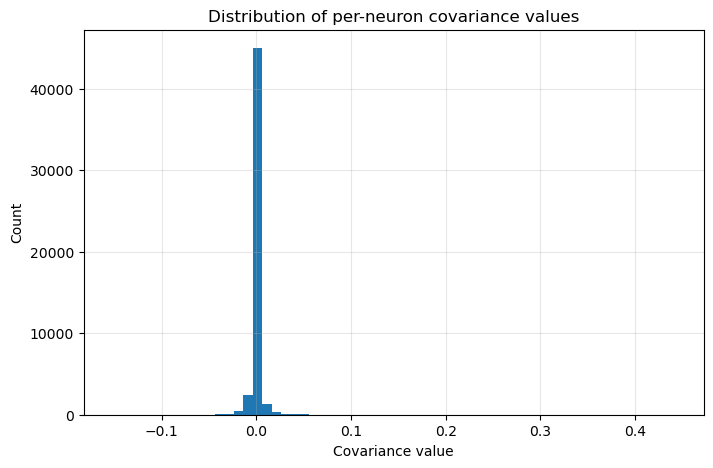

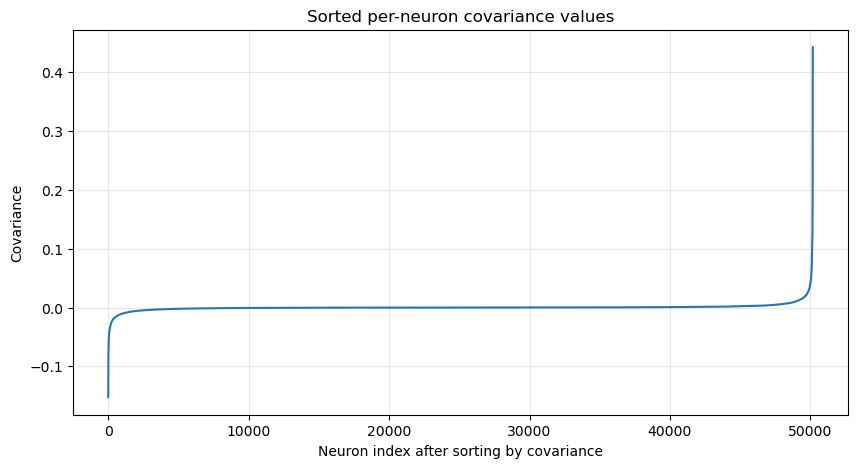

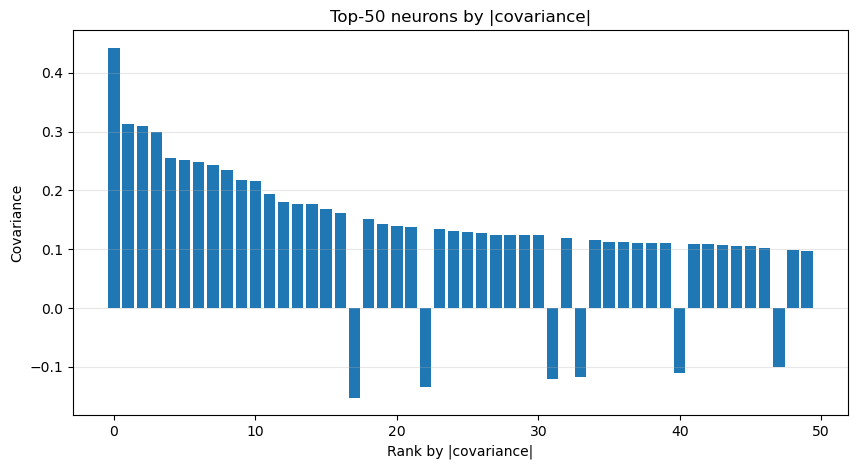

In [27]:
cov_result = run_zero_covariance_analysis(
    image_path="data/jess.jpg",
    layer_name="model.6",
    n_steps=128,
    clear_every=8,
    top_k=50,
)

image: data/jess.jpg
layer: model.9
target class: 151 Chihuahua
n_steps: 128
mean |cov|         = 0.002239217748865485
max  |cov|         = 0.24477767944335938
mean cov           = -0.0001608779712114483
var  cov           = 3.4061085898429155e-05
std  cov           = 0.005836187396198511
sum cov            = -4.036106586456299
sum mean(a*b)      = 10.906742095947266
sum mean(a)mean(b) = 14.942848205566406


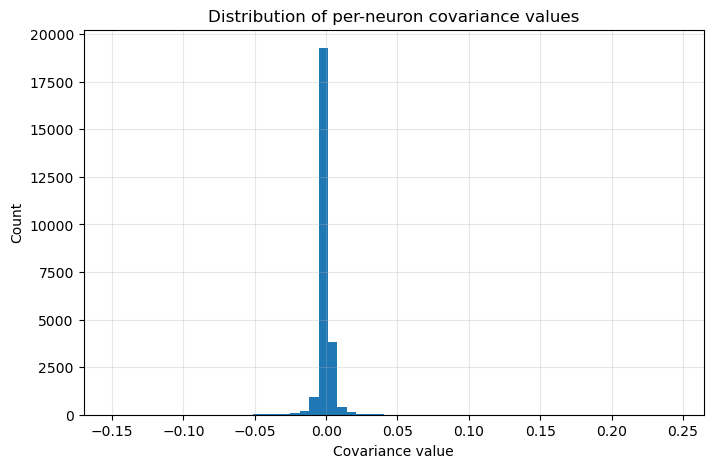

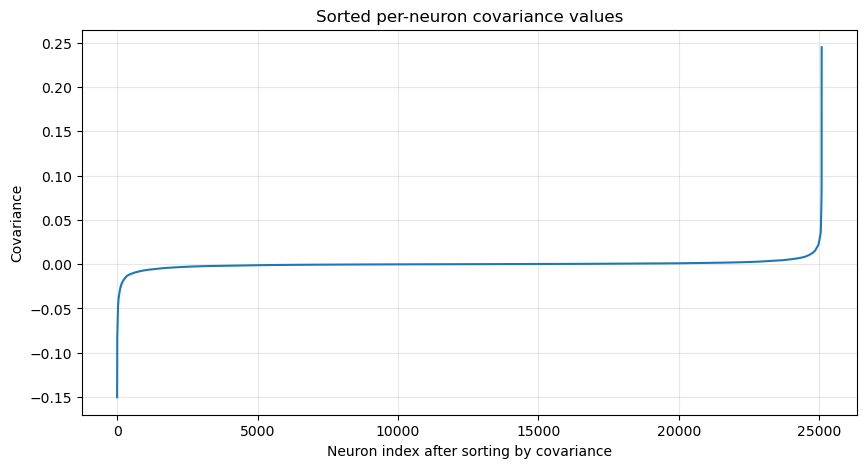

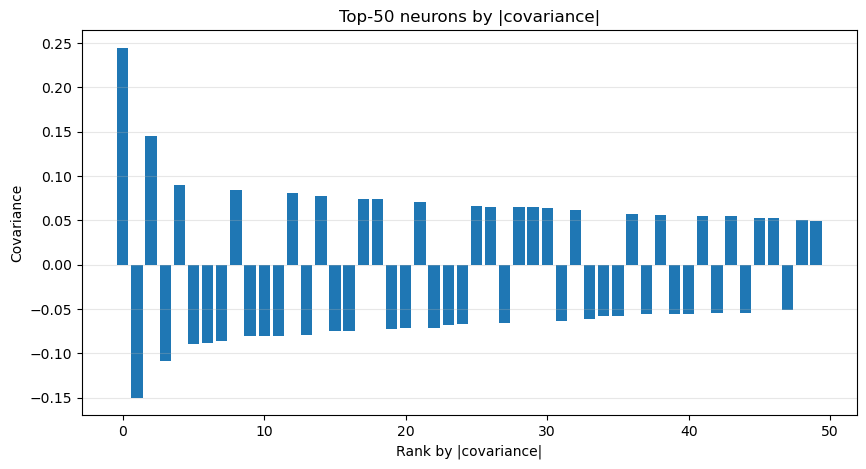

In [28]:
cov_result = run_zero_covariance_analysis(
    image_path="data/jess.jpg",
    layer_name="model.9",
    n_steps=128,
    clear_every=8,
    top_k=50,
)

image: data/jess.jpg
layer: model.5
target class: 151 Chihuahua
n_steps: 128
mean |cov|         = 0.0026986771263182163
max  |cov|         = 0.4904577136039734
mean cov           = 0.00028983462834730744
var  cov           = 7.321194425458089e-05
std  cov           = 0.008556397631764412
sum cov            = 14.542742729187012
sum mean(a*b)      = 10.906742095947266
sum mean(a)mean(b) = -3.6360013484954834


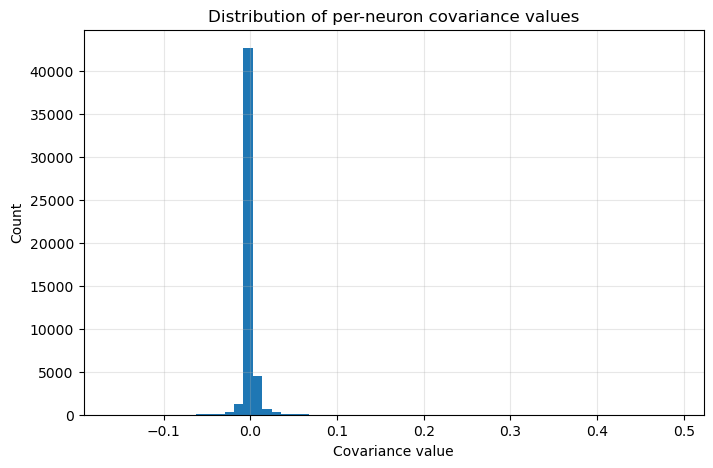

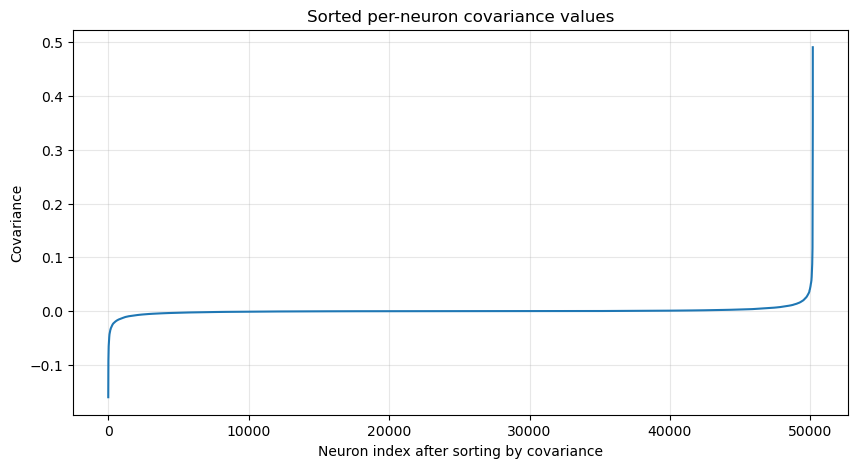

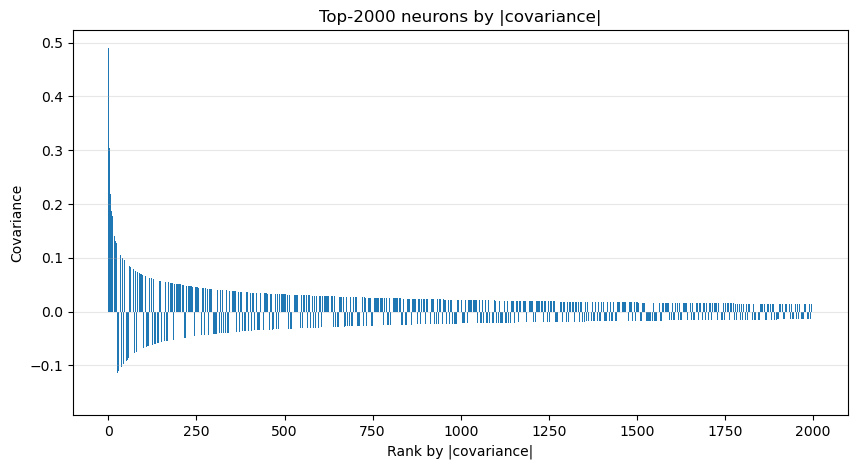

In [29]:
cov_result = run_zero_covariance_analysis(
    image_path="data/jess.jpg",
    layer_name="model.5",
    n_steps=128,
    clear_every=8,
    top_k=2000,
)

In [30]:
def compute_exact_approx_neuron_statistics(
    model,
    hook,
    x,
    x0,
    target_class,
    n_steps=128,
    clear_every=8,
):
    x = x.contiguous()
    x0 = x0.contiguous()
    delta_x = (x - x0).contiguous()

    def forward_with_layer(x_in):
        hook.clear()
        out = model(x_in)
        act = unwrap_tensor(hook.get())
        return out, act

    def layer_activation(x_in):
        _, act = forward_with_layer(x_in)
        return act

    with torch.no_grad():
        _, act_x = forward_with_layer(x)
        _, act_x0 = forward_with_layer(x0)
        delta_y = (act_x - act_x0).detach()

    a_seq = []
    b_seq = []

    for m in range(1, n_steps + 1):
        alpha = m / n_steps
        x_alpha = (x0 + alpha * delta_x).contiguous().detach().requires_grad_(True)

        out, act = forward_with_layer(x_alpha)
        _, logits = split_classifier_output(out)
        score = logits[0, target_class]
        grad_y = torch.autograd.grad(score, act, retain_graph=False, create_graph=False)[0]

        hook.clear()
        _, jvp_out = jvp(layer_activation, (x_alpha,), (delta_x,))
        dir_y = jvp_out.detach()

        a_seq.append(grad_y.detach())
        b_seq.append(dir_y)

        del x_alpha, out, act, logits, score, grad_y, jvp_out, dir_y
        hook.clear()

        if m % clear_every == 0:
            clear_backend_cache()

    a_seq = torch.stack(a_seq, dim=0)
    b_seq = torch.stack(b_seq, dim=0)

    mean_a = a_seq.mean(dim=0)
    mean_b = b_seq.mean(dim=0)
    mean_ab = (a_seq * b_seq).mean(dim=0)
    cov = mean_ab - mean_a * mean_b

    stats = {
        "cov": cov.detach(),
        "exact_attr": mean_ab.detach(),
        "approx_attr": (mean_a * mean_b).detach(),
        "delta_y": delta_y.detach(),
        "ia": mean_a.detach(),
        "directional_mean": mean_b.detach(),
    }
    clear_backend_cache()
    return stats

def _safe_rankdata(values):
    order = np.argsort(values)
    ranks = np.empty_like(order, dtype=np.float64)
    ranks[order] = np.arange(len(values), dtype=np.float64)
    return ranks


def _pearson_np(x, y):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    x = x - x.mean()
    y = y - y.mean()
    denom = np.sqrt((x * x).sum() * (y * y).sum())
    if denom == 0:
        return float("nan")
    return float((x * y).sum() / denom)


def _spearman_np(x, y):
    rx = _safe_rankdata(np.asarray(x, dtype=np.float64))
    ry = _safe_rankdata(np.asarray(y, dtype=np.float64))
    return _pearson_np(rx, ry)


def compute_covariance_importance_relationships(
    neuron_stats,
    top_ks=(10, 25, 50, 100, 250, 500),
):
    cov_abs = neuron_stats["cov"].abs().reshape(-1).detach().cpu().numpy()
    exact_abs = neuron_stats["exact_attr"].abs().reshape(-1).detach().cpu().numpy()
    approx_abs = neuron_stats["approx_attr"].abs().reshape(-1).detach().cpu().numpy()
    delta_abs = neuron_stats["delta_y"].abs().reshape(-1).detach().cpu().numpy()
    ia_abs = neuron_stats["ia"].abs().reshape(-1).detach().cpu().numpy()
    directional_abs = neuron_stats["directional_mean"].abs().reshape(-1).detach().cpu().numpy()

    metrics = {
        "|cov|": cov_abs,
        "|exact_attr|": exact_abs,
        "|approx_attr|": approx_abs,
        "|delta_y|": delta_abs,
        "|IA|": ia_abs,
        "|mean_dir|": directional_abs,
    }

    corr_table = {}
    metric_names = list(metrics.keys())
    for name_x in metric_names:
        corr_table[name_x] = {}
        for name_y in metric_names:
            corr_table[name_x][name_y] = {
                "pearson": _pearson_np(metrics[name_x], metrics[name_y]),
                "spearman": _spearman_np(metrics[name_x], metrics[name_y]),
            }

    overlap_table = {}
    cov_order = np.argsort(cov_abs)[::-1]

    for metric_name, values in metrics.items():
        metric_order = np.argsort(values)[::-1]
        overlap_table[metric_name] = {}

        for k in top_ks:
            k_eff = min(k, len(values))
            cov_top = set(cov_order[:k_eff].tolist())
            metric_top = set(metric_order[:k_eff].tolist())
            intersection = len(cov_top & metric_top)

            overlap_table[metric_name][k_eff] = {
                "intersection": intersection,
                "overlap_fraction": intersection / k_eff,
                "mean_metric_in_cov_top": float(values[cov_order[:k_eff]].mean()),
                "global_mean_metric": float(values.mean()),
                "enrichment": float(values[cov_order[:k_eff]].mean() / (values.mean() + 1e-12)),
            }

    return {
        "metrics": metrics,
        "corr_table": corr_table,
        "overlap_table": overlap_table,
    }

def print_covariance_importance_relationships(
    relationship_stats,
    top_ks=(10, 25, 50, 100, 250, 500),
):
    corr_table = relationship_stats["corr_table"]
    overlap_table = relationship_stats["overlap_table"]

    print("Pearson / Spearman correlations with |cov|:")
    for metric_name in ["|exact_attr|", "|approx_attr|", "|delta_y|", "|IA|", "|mean_dir|"]:
        pearson = corr_table["|cov|"][metric_name]["pearson"]
        spearman = corr_table["|cov|"][metric_name]["spearman"]
        print(f"  {metric_name:14s} | pearson = {pearson:+.6f} | spearman = {spearman:+.6f}")

    print("\nTop-k overlap / enrichment for neurons ranked by |cov|:")
    for metric_name in ["|exact_attr|", "|approx_attr|", "|delta_y|", "|IA|", "|mean_dir|"]:
        print(f"\n{metric_name}:")
        for k in top_ks:
            if k not in overlap_table[metric_name]:
                continue
            row = overlap_table[metric_name][k]
            print(
                f"  k={k:4d} | overlap={row['overlap_fraction']:.4f} "
                f"| intersection={row['intersection']:4d} "
                f"| enrichment={row['enrichment']:.4f}"
            )

def plot_covariance_importance_relationships(
    relationship_stats,
    scatter_metric="|exact_attr|",
    top_k_plot=100,
):
    metrics = relationship_stats["metrics"]
    cov_abs = metrics["|cov|"]
    y_vals = metrics[scatter_metric]

    plt.figure(figsize=(6, 5))
    plt.scatter(cov_abs, y_vals, s=8, alpha=0.35)
    plt.xlabel("|covariance|")
    plt.ylabel(scatter_metric)
    plt.title(f"|covariance| vs {scatter_metric}")
    plt.grid(True, alpha=0.3)
    plt.show()

    order = np.argsort(cov_abs)[::-1]
    k_eff = min(top_k_plot, len(order))

    cov_ranked = cov_abs[order[:k_eff]]
    exact_ranked = metrics["|exact_attr|"][order[:k_eff]]
    approx_ranked = metrics["|approx_attr|"][order[:k_eff]]

    plt.figure(figsize=(10, 5))
    plt.plot(np.arange(k_eff), cov_ranked, label="|covariance|")
    plt.plot(np.arange(k_eff), exact_ranked, label="|exact_attr|")
    plt.plot(np.arange(k_eff), approx_ranked, label="|approx_attr|")
    plt.xlabel("Rank by |covariance|")
    plt.ylabel("Value")
    plt.title(f"Top-{k_eff} neurons ranked by |covariance|")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    smooth_window = min(15, max(3, k_eff // 20))
    if smooth_window % 2 == 0:
        smooth_window += 1

    def moving_average(arr, window):
        if len(arr) < window:
            return arr.copy()
        kernel = np.ones(window, dtype=np.float64) / window
        return np.convolve(arr, kernel, mode="same")

    cov_smooth = moving_average(cov_ranked, smooth_window)
    exact_smooth = moving_average(exact_ranked, smooth_window)
    approx_smooth = moving_average(approx_ranked, smooth_window)

    plt.figure(figsize=(10, 5))
    plt.plot(np.arange(k_eff), cov_smooth, label=f"|covariance| (MA, w={smooth_window})")
    plt.plot(np.arange(k_eff), exact_smooth, label=f"|exact_attr| (MA, w={smooth_window})")
    plt.plot(np.arange(k_eff), approx_smooth, label=f"|approx_attr| (MA, w={smooth_window})")
    plt.xlabel("Rank by |covariance|")
    plt.ylabel("Smoothed value")
    plt.title(f"Smoothed top-{k_eff} neurons ranked by |covariance|")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    top_ks = sorted(next(iter(relationship_stats["overlap_table"].values())).keys())
    exact_overlap = [relationship_stats["overlap_table"]["|exact_attr|"][k]["overlap_fraction"] for k in top_ks]
    approx_overlap = [relationship_stats["overlap_table"]["|approx_attr|"][k]["overlap_fraction"] for k in top_ks]
    ia_overlap = [relationship_stats["overlap_table"]["|IA|"][k]["overlap_fraction"] for k in top_ks]

    plt.figure(figsize=(8, 5))
    plt.plot(top_ks, exact_overlap, marker="o", label="top-k overlap with |exact_attr|")
    plt.plot(top_ks, approx_overlap, marker="o", label="top-k overlap with |approx_attr|")
    plt.plot(top_ks, ia_overlap, marker="o", label="top-k overlap with |IA|")
    plt.xlabel("k")
    plt.ylabel("Overlap fraction")
    plt.title("Overlap of top-k |covariance| neurons with important neurons")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

def run_covariance_vs_importance_analysis(
    image_path,
    layer_name,
    n_steps=128,
    clear_every=8,
    top_ks=(10, 25, 50, 100, 250, 500),
    scatter_metric="|exact_attr|",
    top_k_plot=100,
):
    base_result = run_zero_covariance_analysis(
        image_path=image_path,
        layer_name=layer_name,
        n_steps=n_steps,
        clear_every=clear_every,
        top_k=50,
    )

    x = base_result["x"]
    x0 = base_result["x0"]
    target_class = base_result["target_class"]

    hook = LayerHook(model, layer_name)
    try:
        neuron_stats = compute_exact_approx_neuron_statistics(
            model=model,
            hook=hook,
            x=x,
            x0=x0,
            target_class=target_class,
            n_steps=n_steps,
            clear_every=clear_every,
        )
    finally:
        hook.remove()
        clear_backend_cache()

    relationship_stats = compute_covariance_importance_relationships(
        neuron_stats,
        top_ks=top_ks,
    )

    print_covariance_importance_relationships(relationship_stats, top_ks=top_ks)
    plot_covariance_importance_relationships(
        relationship_stats,
        scatter_metric=scatter_metric,
        top_k_plot=top_k_plot,
    )

    return {
        "base_result": base_result,
        "neuron_stats": neuron_stats,
        "relationship_stats": relationship_stats,
    }

image: data/jess.jpg
layer: model.5
target class: 151 Chihuahua
n_steps: 128
mean |cov|         = 0.0026986771263182163
max  |cov|         = 0.4904577136039734
mean cov           = 0.00028983462834730744
var  cov           = 7.321194425458089e-05
std  cov           = 0.008556397631764412
sum cov            = 14.542742729187012
sum mean(a*b)      = 10.906742095947266
sum mean(a)mean(b) = -3.6360013484954834


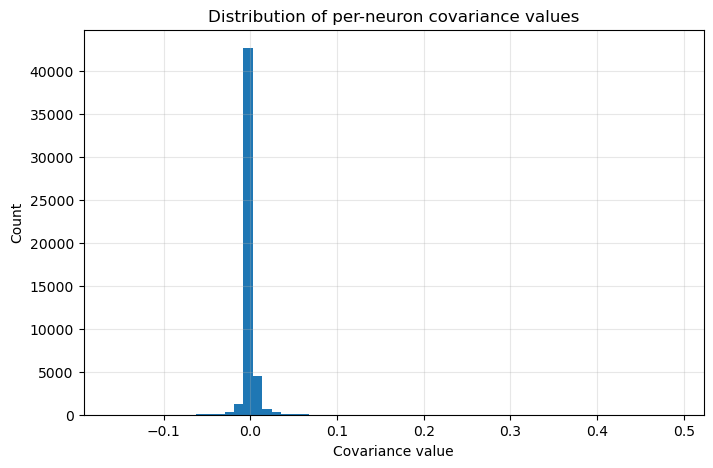

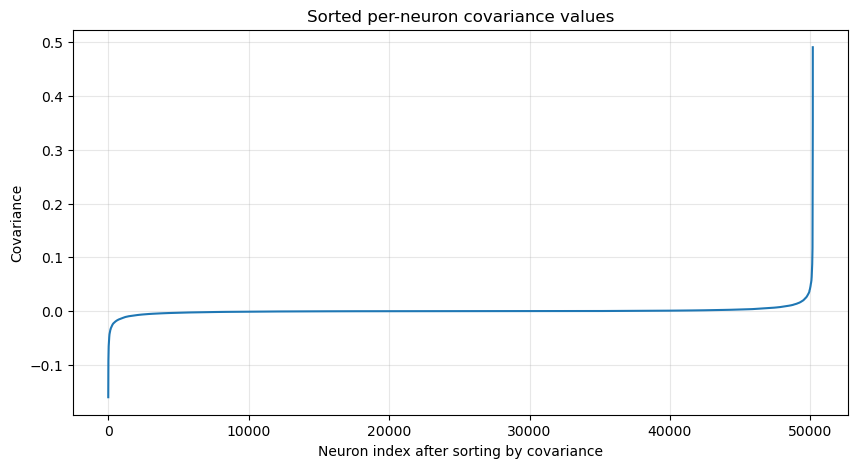

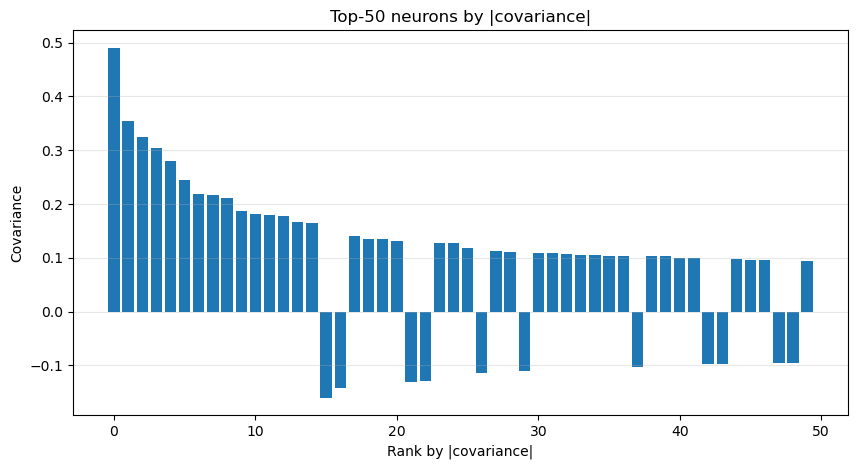

Pearson / Spearman correlations with |cov|:
  |exact_attr|   | pearson = +0.744543 | spearman = +0.834107
  |approx_attr|  | pearson = +0.593034 | spearman = +0.741793
  |delta_y|      | pearson = +0.372678 | spearman = +0.588431
  |IA|           | pearson = +0.450777 | spearman = +0.581534
  |mean_dir|     | pearson = +0.418792 | spearman = +0.642676

Top-k overlap / enrichment for neurons ranked by |cov|:

|exact_attr|:
  k=  10 | overlap=0.5000 | intersection=   5 | enrichment=81.7845
  k=  25 | overlap=0.5200 | intersection=  13 | enrichment=62.7121
  k=  50 | overlap=0.5200 | intersection=  26 | enrichment=50.2926
  k= 100 | overlap=0.5100 | intersection=  51 | enrichment=37.4864
  k= 250 | overlap=0.4800 | intersection= 120 | enrichment=24.0271
  k= 500 | overlap=0.5080 | intersection= 254 | enrichment=17.9448

|approx_attr|:
  k=  10 | overlap=0.1000 | intersection=   1 | enrichment=48.0138
  k=  25 | overlap=0.2400 | intersection=   6 | enrichment=42.8951
  k=  50 | overlap=0.3

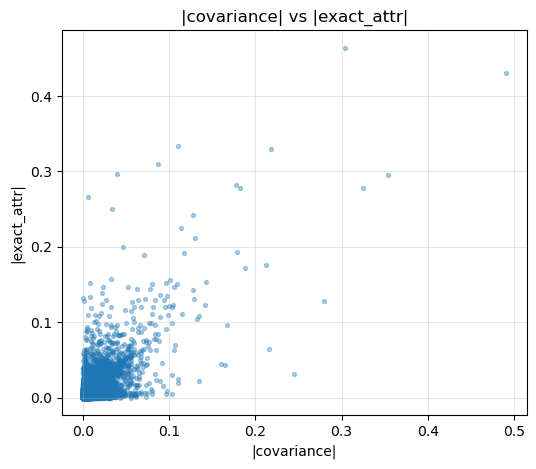

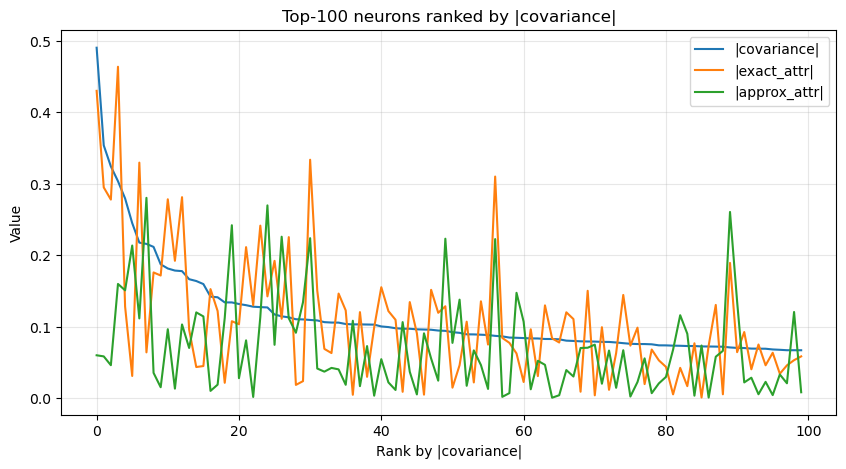

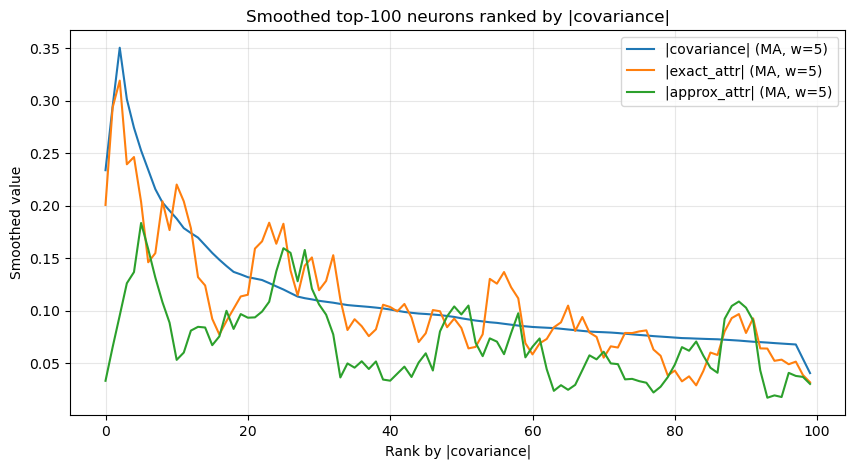

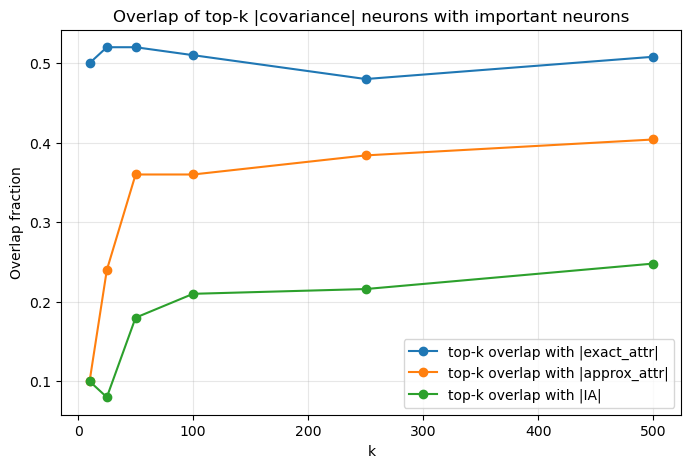

In [31]:
cov_importance_result = run_covariance_vs_importance_analysis(
    image_path="data/jess.jpg",
    layer_name="model.5",
    n_steps=128,
    clear_every=8,
    top_ks=(10, 25, 50, 100, 250, 500),
    scatter_metric="|exact_attr|",
    top_k_plot=100,
)

image: data/jess.jpg
layer: model.5
target class: 151 Chihuahua
n_steps: 128
mean |cov|         = 0.0026986771263182163
max  |cov|         = 0.4904577136039734
mean cov           = 0.00028983462834730744
var  cov           = 7.321194425458089e-05
std  cov           = 0.008556397631764412
sum cov            = 14.542742729187012
sum mean(a*b)      = 10.906742095947266
sum mean(a)mean(b) = -3.6360013484954834


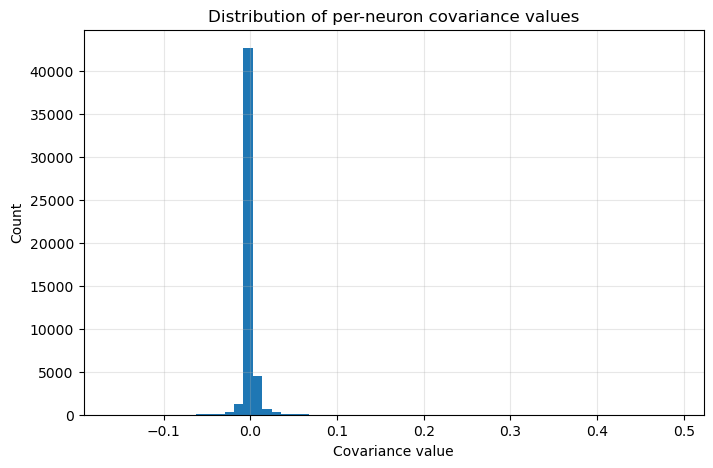

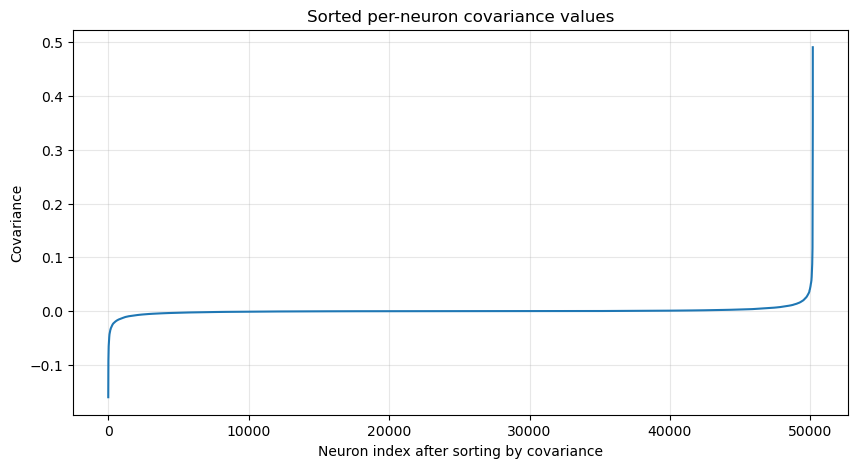

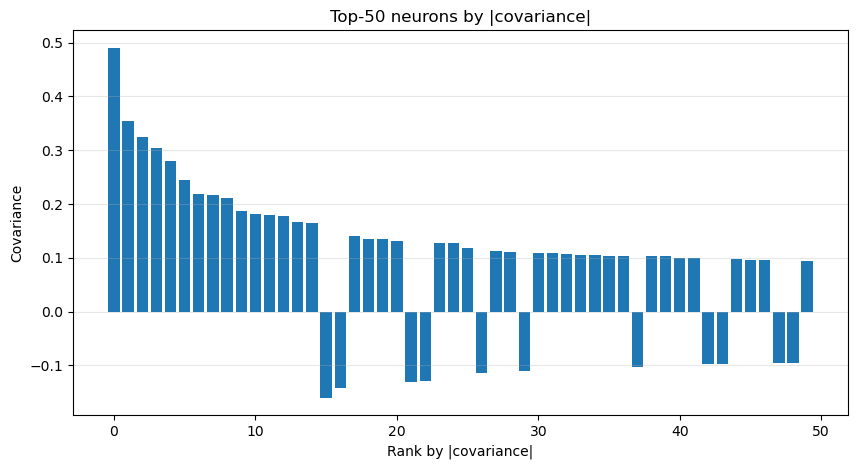

Pearson / Spearman correlations with |cov|:
  |exact_attr|   | pearson = +0.744543 | spearman = +0.834107
  |approx_attr|  | pearson = +0.593034 | spearman = +0.741793
  |delta_y|      | pearson = +0.372678 | spearman = +0.588431
  |IA|           | pearson = +0.450777 | spearman = +0.581534
  |mean_dir|     | pearson = +0.418792 | spearman = +0.642676

Top-k overlap / enrichment for neurons ranked by |cov|:

|exact_attr|:
  k=  10 | overlap=0.5000 | intersection=   5 | enrichment=81.7845
  k=  25 | overlap=0.5200 | intersection=  13 | enrichment=62.7121
  k=  50 | overlap=0.5200 | intersection=  26 | enrichment=50.2926
  k= 100 | overlap=0.5100 | intersection=  51 | enrichment=37.4864
  k= 250 | overlap=0.4800 | intersection= 120 | enrichment=24.0271
  k= 500 | overlap=0.5080 | intersection= 254 | enrichment=17.9448

|approx_attr|:
  k=  10 | overlap=0.1000 | intersection=   1 | enrichment=48.0138
  k=  25 | overlap=0.2400 | intersection=   6 | enrichment=42.8951
  k=  50 | overlap=0.3

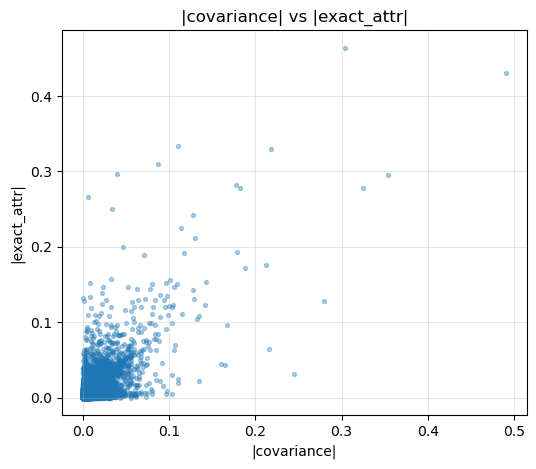

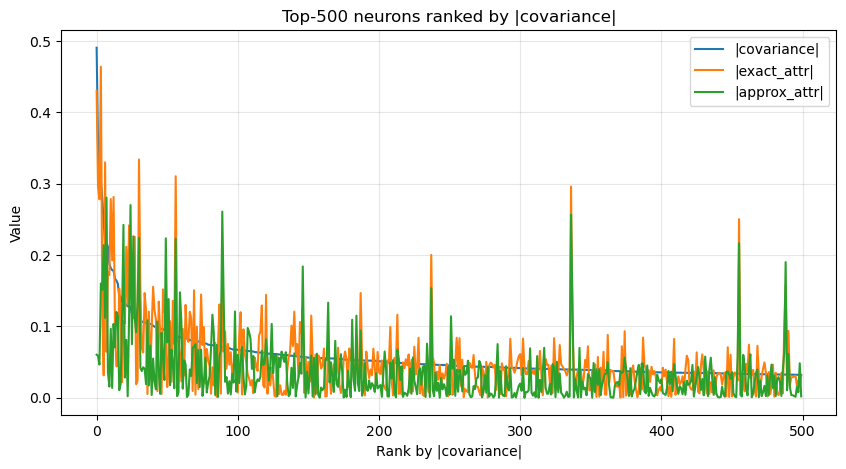

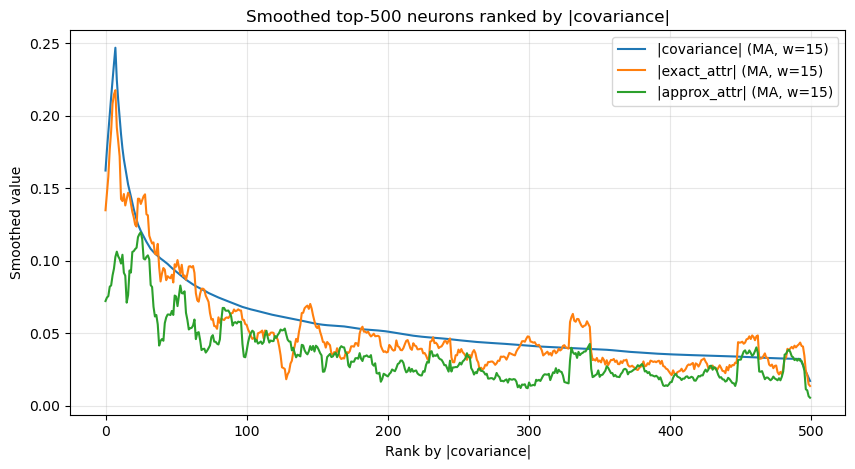

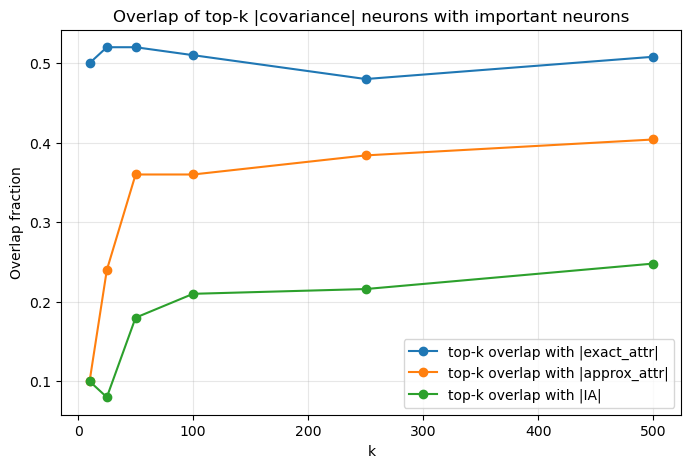

In [32]:
cov_importance_result = run_covariance_vs_importance_analysis(
    image_path="data/jess.jpg",
    layer_name="model.5",
    n_steps=128,
    clear_every=8,
    top_ks=(10, 25, 50, 100, 250, 500),
    scatter_metric="|exact_attr|",
    top_k_plot=500,
)

## Диагностика структуры ковариации
Ниже — серия экспериментов, которые не пытаются сразу минимизировать ошибку, а исследуют структуру covariance-term.

Идея: понять, зависит ли ковариация в основном от положения на пути baseline→input, от малой доли «подозрительных» нейронов, от грубых статистик вроде `|Δy|`, `|IA|`, `|mean_dir|`, а также от spatial/channel-агрегации.

Если эти зависимости окажутся устойчивыми, по ним уже можно будет выбирать осмысленный correction method.

In [33]:
def _stack_path_statistics(a_seq, b_seq):
    """Return basic per-neuron path statistics for gradient and directional-derivative sequences."""
    mean_a = a_seq.mean(dim=0)
    mean_b = b_seq.mean(dim=0)
    mean_ab = (a_seq * b_seq).mean(dim=0)

    var_a = ((a_seq - mean_a) ** 2).mean(dim=0)
    var_b = ((b_seq - mean_b) ** 2).mean(dim=0)
    std_a = torch.sqrt(torch.clamp(var_a, min=0.0))
    std_b = torch.sqrt(torch.clamp(var_b, min=0.0))

    cov = mean_ab - mean_a * mean_b
    corr = cov / (std_a * std_b + 1e-12)

    sign_flip_a = (a_seq[1:] * a_seq[:-1] < 0).float().mean(dim=0) if a_seq.shape[0] > 1 else torch.zeros_like(mean_a)
    sign_flip_b = (b_seq[1:] * b_seq[:-1] < 0).float().mean(dim=0) if b_seq.shape[0] > 1 else torch.zeros_like(mean_b)

    mean_abs_diff_a = (a_seq[1:] - a_seq[:-1]).abs().mean(dim=0) if a_seq.shape[0] > 1 else torch.zeros_like(mean_a)
    mean_abs_diff_b = (b_seq[1:] - b_seq[:-1]).abs().mean(dim=0) if b_seq.shape[0] > 1 else torch.zeros_like(mean_b)

    return {
        "mean_a": mean_a,
        "mean_b": mean_b,
        "mean_ab": mean_ab,
        "var_a": var_a,
        "var_b": var_b,
        "std_a": std_a,
        "std_b": std_b,
        "cov": cov,
        "corr": corr,
        "sign_flip_a": sign_flip_a,
        "sign_flip_b": sign_flip_b,
        "mean_abs_diff_a": mean_abs_diff_a,
        "mean_abs_diff_b": mean_abs_diff_b,
    }


def compute_path_covariance_structure(
        model,
        hook,
        x,
        x0,
        target_class,
        n_steps=128,
        clear_every=8,
):
    """Collect full a_m / b_m sequences and summarize structural diagnostics of the covariance term."""
    x = x.contiguous()
    x0 = x0.contiguous()
    delta_x = (x - x0).contiguous()

    def forward_with_layer(x_in):
        hook.clear()
        out = model(x_in)
        act = unwrap_tensor(hook.get())
        return out, act

    def layer_activation(x_in):
        _, act = forward_with_layer(x_in)
        return act

    with torch.no_grad():
        _, act_x = forward_with_layer(x)
        _, act_x0 = forward_with_layer(x0)
        delta_y = (act_x - act_x0).detach()

    a_seq = []
    b_seq = []
    alphas = []

    for m in range(1, n_steps + 1):
        alpha = m / n_steps
        x_alpha = (x0 + alpha * delta_x).contiguous().detach().requires_grad_(True)

        out, act = forward_with_layer(x_alpha)
        _, logits = split_classifier_output(out)
        score = logits[0, target_class]
        grad_y = torch.autograd.grad(score, act, retain_graph=False, create_graph=False)[0]

        hook.clear()
        _, jvp_out = jvp(layer_activation, (x_alpha,), (delta_x,))
        dir_y = jvp_out.detach()

        a_seq.append(grad_y.detach())
        b_seq.append(dir_y)
        alphas.append(alpha)

        del x_alpha, out, act, logits, score, grad_y, jvp_out, dir_y
        hook.clear()

        if m % clear_every == 0:
            clear_backend_cache()

    a_seq = torch.stack(a_seq, dim=0)
    b_seq = torch.stack(b_seq, dim=0)
    stats = _stack_path_statistics(a_seq, b_seq)

    exact_attr = stats["mean_ab"].detach()
    approx_attr = (stats["mean_a"] * stats["mean_b"]).detach()
    cov = stats["cov"].detach()

    out = {
        "alphas": np.asarray(alphas, dtype=np.float64),
        "a_seq": a_seq.detach(),
        "b_seq": b_seq.detach(),
        "delta_y": delta_y.detach(),
        "exact_attr": exact_attr,
        "approx_attr": approx_attr,
        "cov": cov,
    }
    out.update({k: v.detach() for k, v in stats.items()})
    clear_backend_cache()
    return out


def summarize_topk_covariance_mass(cov_tensor, top_ks=(10, 25, 50, 100, 250, 500, 1000)):
    cov_abs = cov_tensor.abs().reshape(-1).detach().cpu().numpy()
    total_mass = float(cov_abs.sum()) + 1e-12
    order = np.argsort(cov_abs)[::-1]

    rows = []
    for k in top_ks:
        k_eff = min(k, len(cov_abs))
        mass = float(cov_abs[order[:k_eff]].sum())
        rows.append({
            "k": k_eff,
            "mass_fraction": mass / total_mass,
            "mean_abs_cov_topk": float(cov_abs[order[:k_eff]].mean()),
            "global_mean_abs_cov": float(cov_abs.mean()),
        })
    return rows


def summarize_spatial_channel_pooling(structure):
    """Compare covariance before and after common channel/spatial aggregations."""
    cov = structure["cov"]
    exact_attr = structure["exact_attr"]
    approx_attr = structure["approx_attr"]

    result = {}

    if cov.ndim == 4:
        cov_per_filter = cov[0].sum(dim=(1, 2))
        exact_per_filter = exact_attr[0].sum(dim=(1, 2))
        approx_per_filter = approx_attr[0].sum(dim=(1, 2))

        cov_spatial = cov[0].sum(dim=0)
        exact_spatial = exact_attr[0].sum(dim=0)
        approx_spatial = approx_attr[0].sum(dim=0)

        result["filter_level"] = {
            "cov": cov_per_filter.detach().cpu().numpy(),
            "exact": exact_per_filter.detach().cpu().numpy(),
            "approx": approx_per_filter.detach().cpu().numpy(),
        }
        result["spatial_level"] = {
            "cov": cov_spatial.detach().cpu().numpy(),
            "exact": exact_spatial.detach().cpu().numpy(),
            "approx": approx_spatial.detach().cpu().numpy(),
        }
    else:
        result["flat_level"] = {
            "cov": cov.reshape(-1).detach().cpu().numpy(),
            "exact": exact_attr.reshape(-1).detach().cpu().numpy(),
            "approx": approx_attr.reshape(-1).detach().cpu().numpy(),
        }

    return result

In [34]:
def print_covariance_structure_report(structure, top_ks=(10, 25, 50, 100, 250, 500, 1000)):
    cov_abs = structure["cov"].abs().reshape(-1).detach().cpu().numpy()
    exact_abs = structure["exact_attr"].abs().reshape(-1).detach().cpu().numpy()
    approx_abs = structure["approx_attr"].abs().reshape(-1).detach().cpu().numpy()
    delta_abs = structure["delta_y"].abs().reshape(-1).detach().cpu().numpy()
    mean_a_abs = structure["mean_a"].abs().reshape(-1).detach().cpu().numpy()
    mean_b_abs = structure["mean_b"].abs().reshape(-1).detach().cpu().numpy()
    var_a = structure["var_a"].reshape(-1).detach().cpu().numpy()
    var_b = structure["var_b"].reshape(-1).detach().cpu().numpy()
    sign_flip_a = structure["sign_flip_a"].reshape(-1).detach().cpu().numpy()
    sign_flip_b = structure["sign_flip_b"].reshape(-1).detach().cpu().numpy()
    mean_abs_diff_a = structure["mean_abs_diff_a"].reshape(-1).detach().cpu().numpy()
    mean_abs_diff_b = structure["mean_abs_diff_b"].reshape(-1).detach().cpu().numpy()

    metrics = {
        "|exact_attr|": exact_abs,
        "|approx_attr|": approx_abs,
        "|delta_y|": delta_abs,
        "|mean_a|": mean_a_abs,
        "|mean_b|": mean_b_abs,
        "var_a": var_a,
        "var_b": var_b,
        "sign_flip_a": sign_flip_a,
        "sign_flip_b": sign_flip_b,
        "mean_abs_diff_a": mean_abs_diff_a,
        "mean_abs_diff_b": mean_abs_diff_b,
    }

    print("Correlations with |cov|:")
    for name, values in metrics.items():
        print(
            f"  {name:16s} | pearson = {_pearson_np(cov_abs, values):+.6f} | "
            f"spearman = {_spearman_np(cov_abs, values):+.6f}"
        )

    print("\nTop-k covariance mass concentration:")
    for row in summarize_topk_covariance_mass(structure["cov"], top_ks=top_ks):
        print(
            f"  k={row['k']:5d} | mass_fraction={row['mass_fraction']:.4f} | "
            f"mean|cov|_topk={row['mean_abs_cov_topk']:.6f} | global_mean|cov|={row['global_mean_abs_cov']:.6f}"
        )


def plot_covariance_structure_diagnostics(structure, scatter_metric="|exact_attr|", top_k_mass=500):
    cov_abs = structure["cov"].abs().reshape(-1).detach().cpu().numpy()
    metric_map = {
        "|exact_attr|": structure["exact_attr"].abs().reshape(-1).detach().cpu().numpy(),
        "|approx_attr|": structure["approx_attr"].abs().reshape(-1).detach().cpu().numpy(),
        "|delta_y|": structure["delta_y"].abs().reshape(-1).detach().cpu().numpy(),
        "|mean_a|": structure["mean_a"].abs().reshape(-1).detach().cpu().numpy(),
        "|mean_b|": structure["mean_b"].abs().reshape(-1).detach().cpu().numpy(),
        "var_a": structure["var_a"].reshape(-1).detach().cpu().numpy(),
        "var_b": structure["var_b"].reshape(-1).detach().cpu().numpy(),
        "sign_flip_a": structure["sign_flip_a"].reshape(-1).detach().cpu().numpy(),
        "sign_flip_b": structure["sign_flip_b"].reshape(-1).detach().cpu().numpy(),
        "mean_abs_diff_a": structure["mean_abs_diff_a"].reshape(-1).detach().cpu().numpy(),
        "mean_abs_diff_b": structure["mean_abs_diff_b"].reshape(-1).detach().cpu().numpy(),
    }

    y_vals = metric_map[scatter_metric]

    plt.figure(figsize=(6, 5))
    plt.scatter(cov_abs, y_vals, s=8, alpha=0.35)
    plt.xlabel("|covariance|")
    plt.ylabel(scatter_metric)
    plt.title(f"|covariance| vs {scatter_metric}")
    plt.grid(True, alpha=0.3)
    plt.show()

    order = np.argsort(cov_abs)[::-1]
    k_eff = min(top_k_mass, len(order))
    cum_mass = np.cumsum(cov_abs[order[:k_eff]]) / (cov_abs.sum() + 1e-12)

    plt.figure(figsize=(8, 5))
    plt.plot(np.arange(1, k_eff + 1), cum_mass)
    plt.xlabel("Top-k neurons ranked by |covariance|")
    plt.ylabel("Cumulative |covariance| mass fraction")
    plt.title("Concentration of |covariance| mass")
    plt.grid(True, alpha=0.3)
    plt.show()

    if structure["cov"].ndim == 4:
        pooled = summarize_spatial_channel_pooling(structure)
        for level_name, payload in pooled.items():
            plt.figure(figsize=(6, 5))
            plt.scatter(np.abs(payload["cov"]), np.abs(payload["exact"]), s=12, alpha=0.4, label="exact")
            plt.scatter(np.abs(payload["cov"]), np.abs(payload["approx"]), s=12, alpha=0.4, label="approx")
            plt.xlabel(f"|covariance| ({level_name})")
            plt.ylabel("|aggregated attribution|")
            plt.title(f"Pooled comparison at {level_name}")
            plt.grid(True, alpha=0.3)
            plt.legend()
            plt.show()


def plot_path_localization_diagnostics(structure, top_k=6):
    """Show whether covariance-heavy neurons concentrate their mismatch on specific alpha ranges."""
    a_seq = structure["a_seq"].detach().cpu().numpy()
    b_seq = structure["b_seq"].detach().cpu().numpy()
    alphas = structure["alphas"]

    cov_abs = np.abs(structure["cov"].reshape(-1).detach().cpu().numpy())
    order = np.argsort(cov_abs)[::-1]
    top_k = min(top_k, len(order))

    a_flat = a_seq.reshape(a_seq.shape[0], -1)
    b_flat = b_seq.reshape(b_seq.shape[0], -1)

    for rank, idx in enumerate(order[:top_k], start=1):
        a = a_flat[:, idx]
        b = b_flat[:, idx]
        prod = a * b

        plt.figure(figsize=(8, 4))
        plt.plot(alphas, a, label="a_m = dF/dy")
        plt.plot(alphas, b, label="b_m = dy/dα")
        plt.plot(alphas, prod, label="a_m * b_m", linewidth=2)
        plt.xlabel("alpha")
        plt.ylabel("value")
        plt.title(f"Top-{rank} covariance neuron, flat idx={idx}, |cov|={cov_abs[idx]:.6f}")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

In [35]:
def run_covariance_structure_experiments(
        image_path,
        layer_name,
        n_steps=128,
        clear_every=8,
        scatter_metric="var_a",
        top_ks=(10, 25, 50, 100, 250, 500, 1000),
        top_k_path=6,
):
    x, _ = load_image(image_path)
    x0 = black_baseline_like(x)

    hook = LayerHook(model, layer_name)
    try:
        hook.clear()
        out = model(x)
        _, logits = split_classifier_output(out)
        target_class = int(logits[0].argmax().item())
        target_name = class_names[target_class]

        structure = compute_path_covariance_structure(
            model=model,
            hook=hook,
            x=x,
            x0=x0,
            target_class=target_class,
            n_steps=n_steps,
            clear_every=clear_every,
        )
    finally:
        hook.remove()
        clear_backend_cache()

    print("image:", image_path)
    print("layer:", layer_name)
    print("target class:", target_class, target_name)
    print("n_steps:", n_steps)
    print("sum exact_attr :", float(structure["exact_attr"].sum().item()))
    print("sum approx_attr:", float(structure["approx_attr"].sum().item()))
    print("sum cov        :", float(structure["cov"].sum().item()))
    print("mean |cov|     :", float(structure["cov"].abs().mean().item()))
    print("max  |cov|     :", float(structure["cov"].abs().max().item()))

    print_covariance_structure_report(structure, top_ks=top_ks)
    plot_covariance_structure_diagnostics(structure, scatter_metric=scatter_metric, top_k_mass=max(top_ks))
    plot_path_localization_diagnostics(structure, top_k=top_k_path)

    return {
        "image_path": image_path,
        "layer_name": layer_name,
        "target_class": target_class,
        "target_name": target_name,
        "structure": structure,
    }

### Запуски диагностики структуры ковариации
Сначала полезно посмотреть:
1. насколько сильно `|cov|` концентрируется в top-k нейронах;
2. сильнее ли она связана с `|exact_attr|`, `|approx_attr|`, variance/sign-flips или smoothness вдоль пути;
3. становится ли структура проще после filter-level / spatial pooling;
4. локализуется ли основной mismatch на отдельных участках пути по `alpha`.

image: data/jess.jpg
layer: model.5
target class: 151 Chihuahua
n_steps: 128
sum exact_attr : 10.906742095947266
sum approx_attr: -3.6360013484954834
sum cov        : 14.542742729187012
mean |cov|     : 0.0026986771263182163
max  |cov|     : 0.4904577136039734
Correlations with |cov|:
  |exact_attr|     | pearson = +0.744543 | spearman = +0.834107
  |approx_attr|    | pearson = +0.593034 | spearman = +0.741793
  |delta_y|        | pearson = +0.372678 | spearman = +0.588431
  |mean_a|         | pearson = +0.450777 | spearman = +0.581534
  |mean_b|         | pearson = +0.418792 | spearman = +0.642676
  var_a            | pearson = +0.543927 | spearman = +0.746355
  var_b            | pearson = +0.257499 | spearman = +0.749140
  sign_flip_a      | pearson = -0.062750 | spearman = -0.065605
  sign_flip_b      | pearson = -0.133283 | spearman = -0.195689
  mean_abs_diff_a  | pearson = +0.532647 | spearman = +0.725900
  mean_abs_diff_b  | pearson = +0.324030 | spearman = +0.709884

Top-k cov

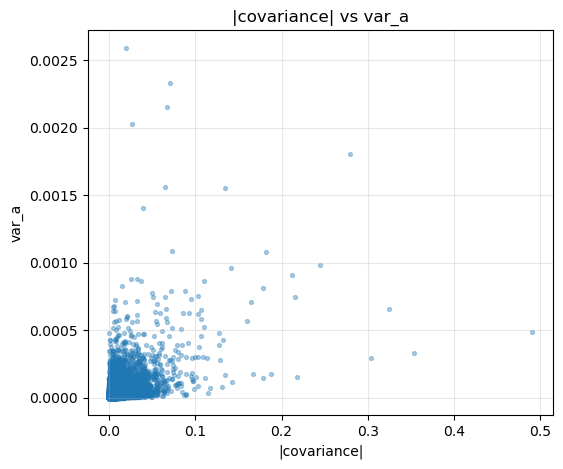

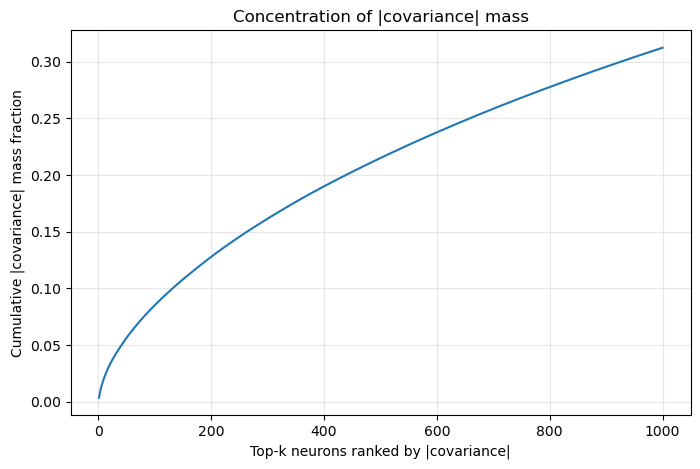

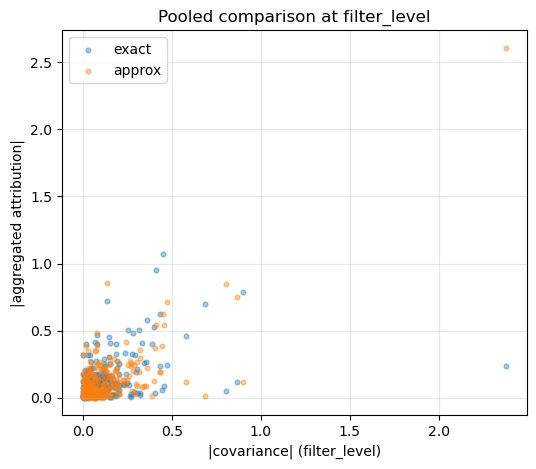

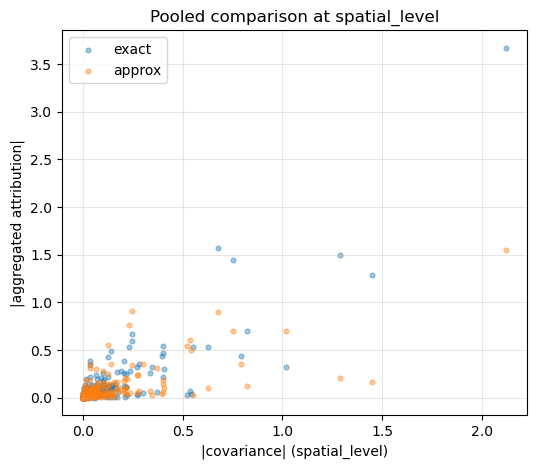

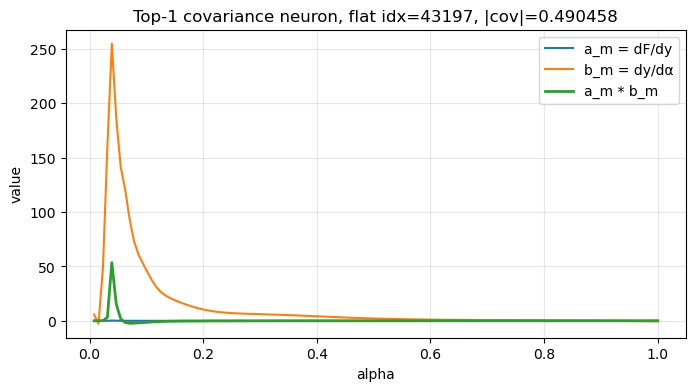

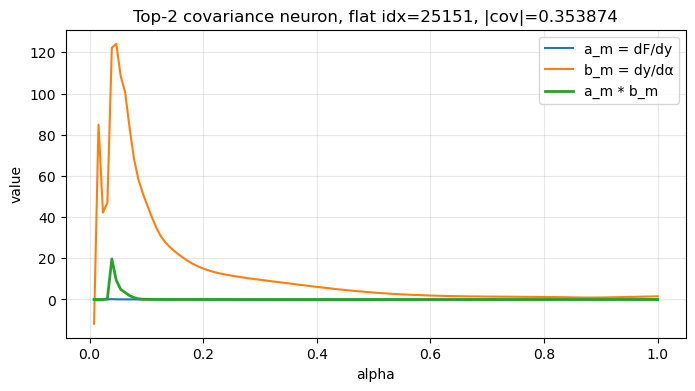

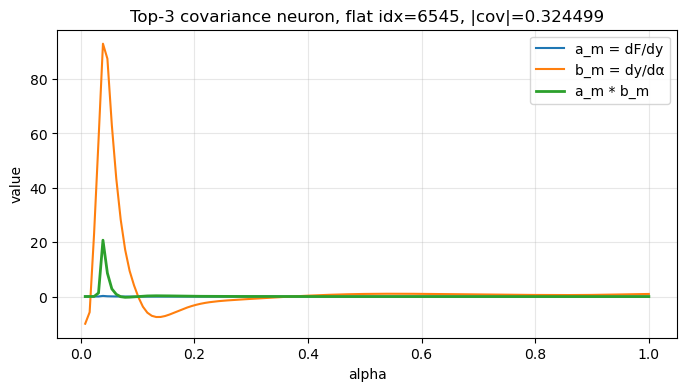

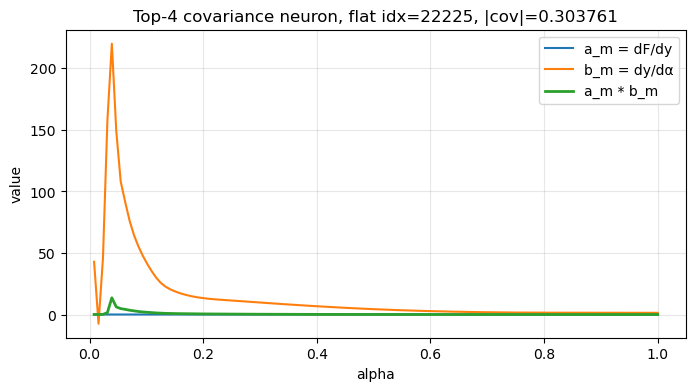

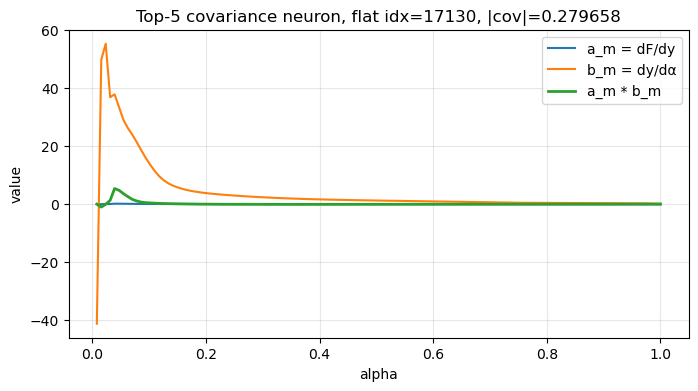

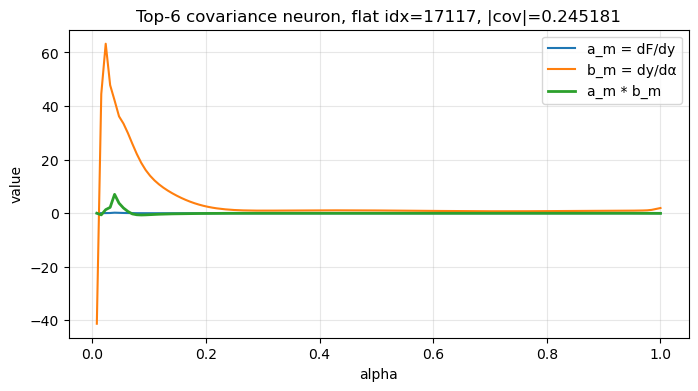

In [36]:
cov_structure_result = run_covariance_structure_experiments(
    image_path="data/jess.jpg",
    layer_name="model.5",
    n_steps=128,
    clear_every=8,
    scatter_metric="var_a",
    top_ks=(10, 25, 50, 100, 250, 500, 1000),
    top_k_path=6,
)

image: data/jess.jpg
layer: model.5
target class: 151 Chihuahua
n_steps: 128
sum exact_attr : 10.906742095947266
sum approx_attr: -3.6360013484954834
sum cov        : 14.542742729187012
mean |cov|     : 0.0026986771263182163
max  |cov|     : 0.4904577136039734
Correlations with |cov|:
  |exact_attr|     | pearson = +0.744543 | spearman = +0.834107
  |approx_attr|    | pearson = +0.593034 | spearman = +0.741793
  |delta_y|        | pearson = +0.372678 | spearman = +0.588431
  |mean_a|         | pearson = +0.450777 | spearman = +0.581534
  |mean_b|         | pearson = +0.418792 | spearman = +0.642676
  var_a            | pearson = +0.543927 | spearman = +0.746355
  var_b            | pearson = +0.257499 | spearman = +0.749140
  sign_flip_a      | pearson = -0.062750 | spearman = -0.065605
  sign_flip_b      | pearson = -0.133283 | spearman = -0.195689
  mean_abs_diff_a  | pearson = +0.532647 | spearman = +0.725900
  mean_abs_diff_b  | pearson = +0.324030 | spearman = +0.709884

Top-k cov

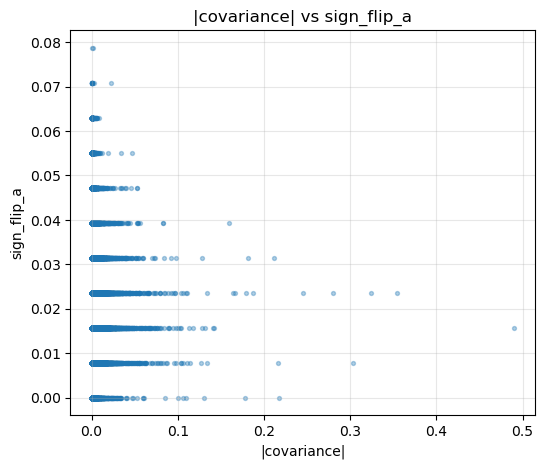

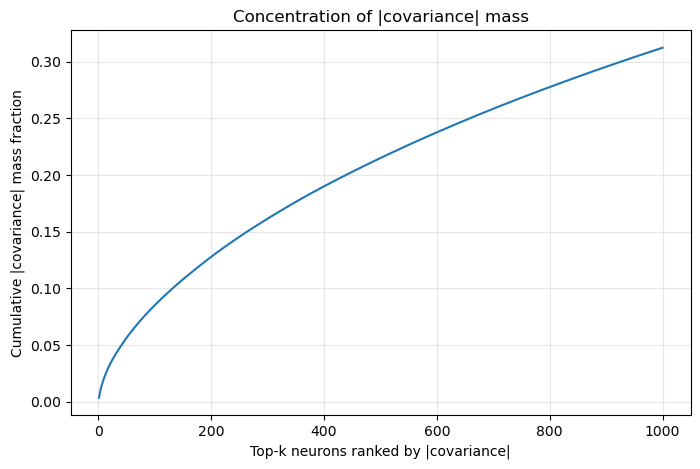

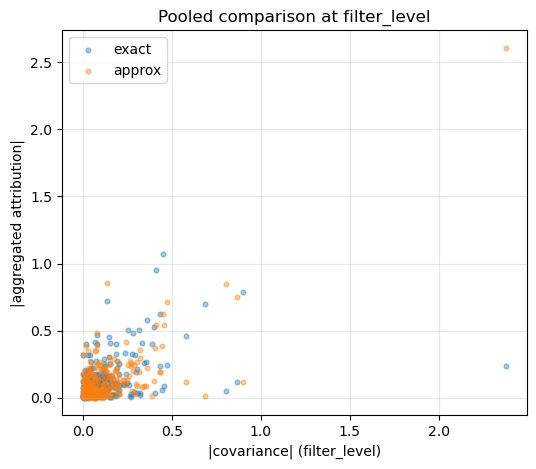

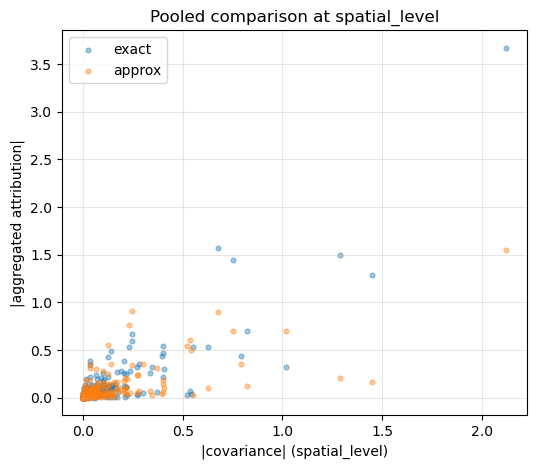

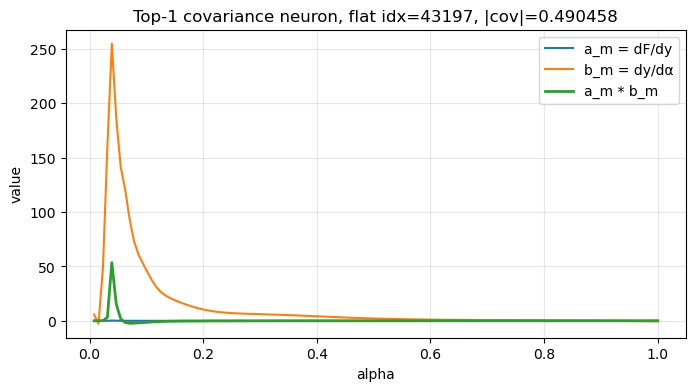

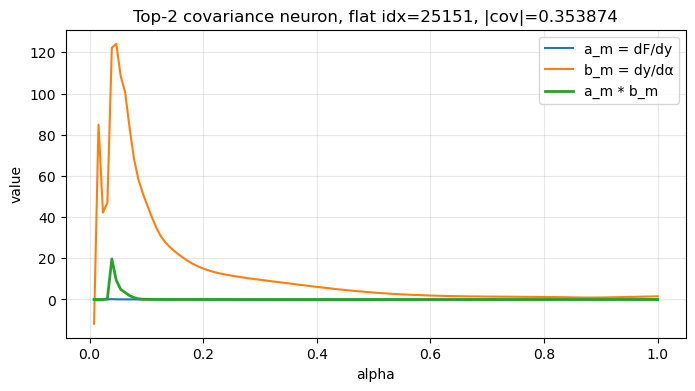

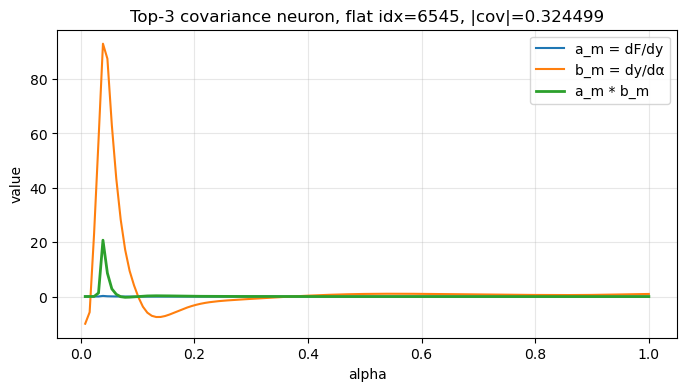

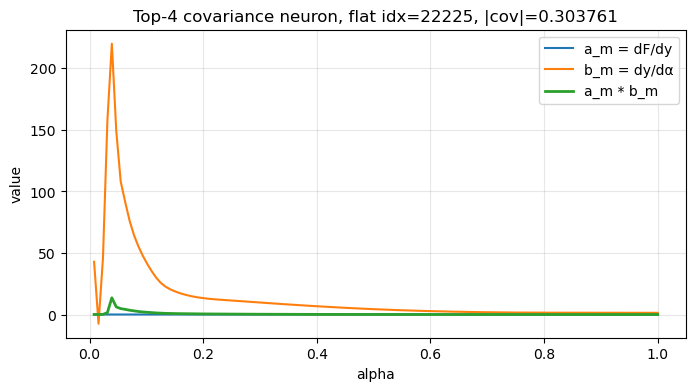

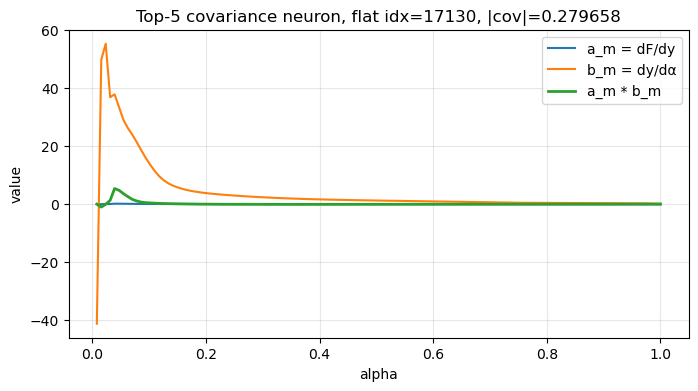

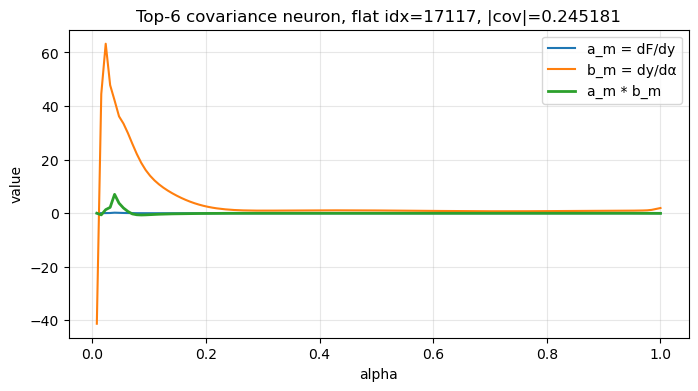

In [37]:
cov_structure_result = run_covariance_structure_experiments(
    image_path="data/jess.jpg",
    layer_name="model.5",
    n_steps=128,
    clear_every=8,
    scatter_metric="sign_flip_a",
    top_ks=(10, 25, 50, 100, 250, 500, 1000),
    top_k_path=6,
)

image: data/jess.jpg
layer: model.6
target class: 151 Chihuahua
n_steps: 128
sum exact_attr : 10.906742095947266
sum approx_attr: -1.869560718536377
sum cov        : 12.776302337646484
mean |cov|     : 0.0022126897238194942
max  |cov|     : 0.44253724813461304
Correlations with |cov|:
  |exact_attr|     | pearson = +0.783619 | spearman = +0.803187
  |approx_attr|    | pearson = +0.569229 | spearman = +0.638396
  |delta_y|        | pearson = +0.456619 | spearman = +0.411174
  |mean_a|         | pearson = +0.320865 | spearman = +0.482482
  |mean_b|         | pearson = +0.482118 | spearman = +0.519281
  var_a            | pearson = +0.465903 | spearman = +0.648122
  var_b            | pearson = +0.390000 | spearman = +0.734689
  sign_flip_a      | pearson = -0.029813 | spearman = -0.045958
  sign_flip_b      | pearson = -0.100173 | spearman = -0.098431
  mean_abs_diff_a  | pearson = +0.451114 | spearman = +0.653453
  mean_abs_diff_b  | pearson = +0.377924 | spearman = +0.689189

Top-k cov

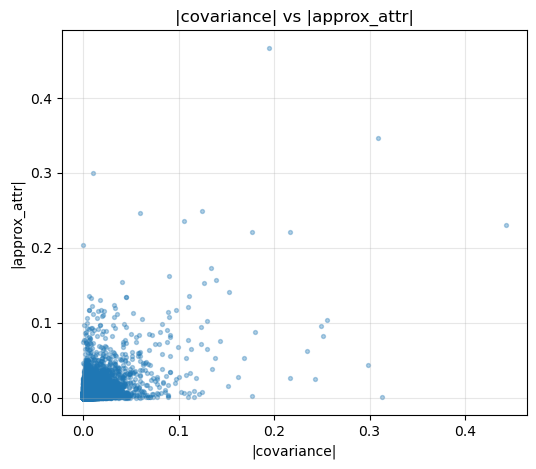

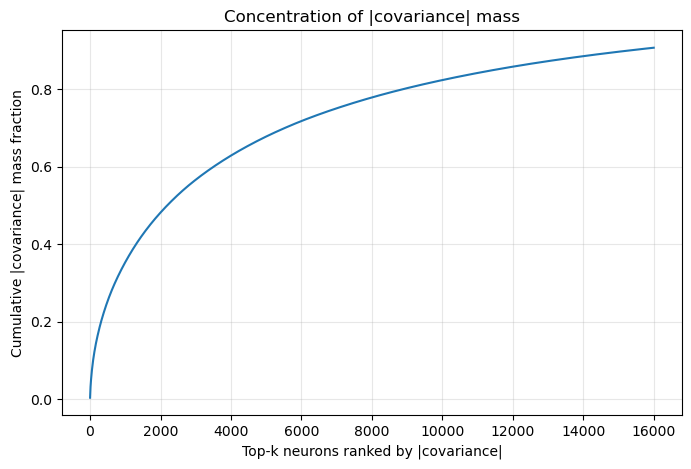

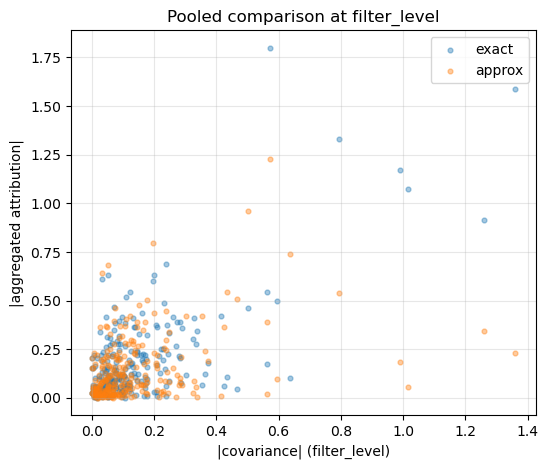

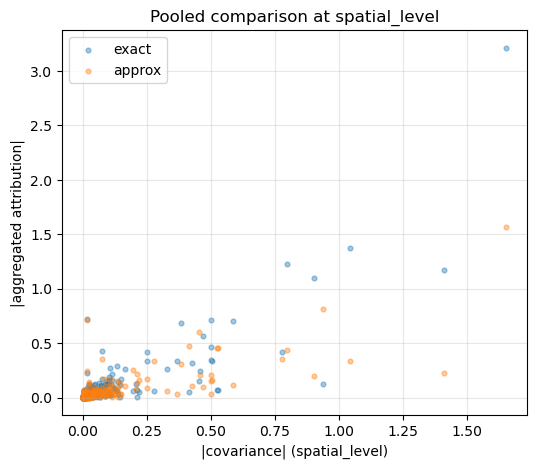

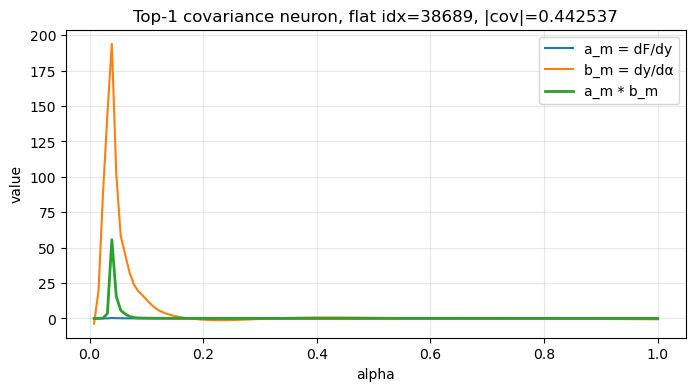

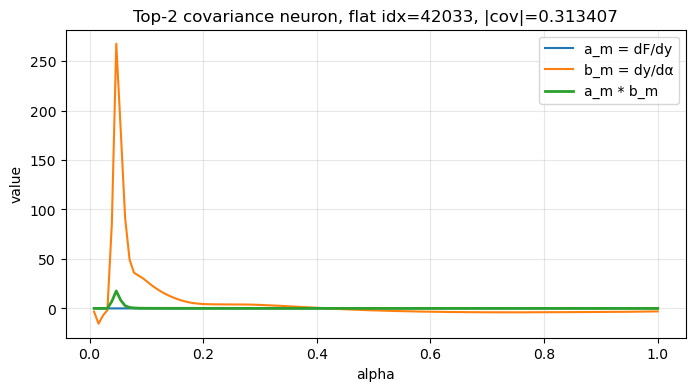

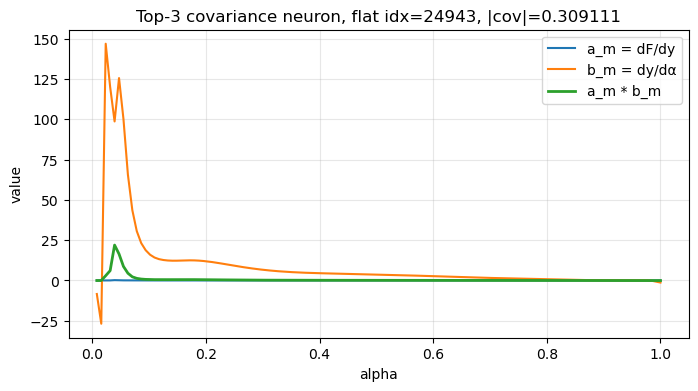

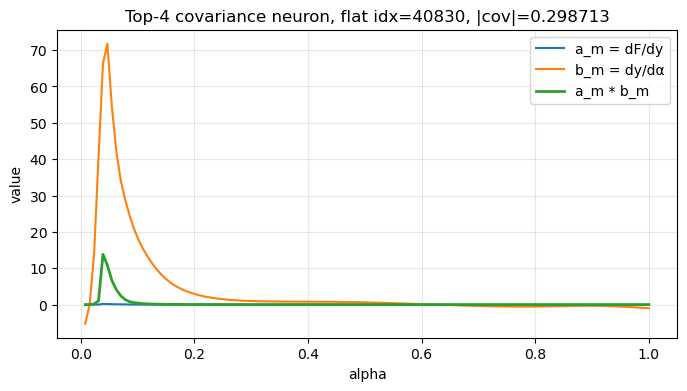

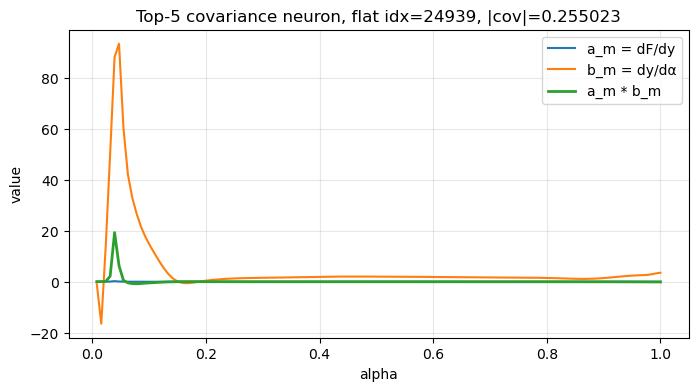

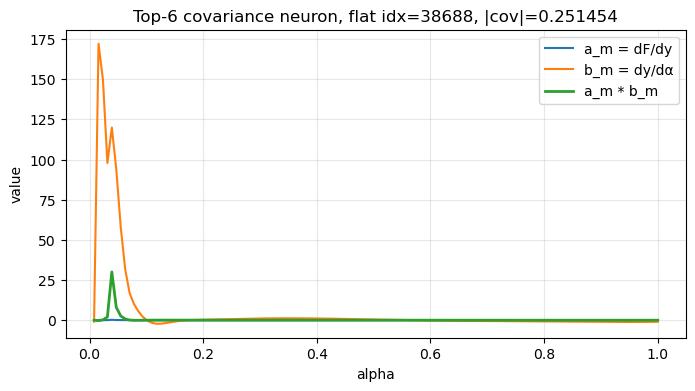

In [44]:
cov_structure_result = run_covariance_structure_experiments(
    image_path="data/jess.jpg",
    layer_name="model.6",
    n_steps=128,
    clear_every=8,
    scatter_metric="|approx_attr|",
    top_ks=(10, 25, 50, 100, 250, 500, 1000, 2000, 4000, 6000, 8000, 10000, 12000, 14000, 16000),
    top_k_path=6,
)

image: data/jess.jpg
layer: model.9
target class: 151 Chihuahua
n_steps: 128
sum exact_attr : 10.906742095947266
sum approx_attr: 14.942848205566406
sum cov        : -4.036106586456299
mean |cov|     : 0.002239217748865485
max  |cov|     : 0.24477767944335938
Correlations with |cov|:
  |exact_attr|     | pearson = +0.493391 | spearman = +0.688430
  |approx_attr|    | pearson = +0.479850 | spearman = +0.565604
  |delta_y|        | pearson = +0.360300 | spearman = +0.258155
  |mean_a|         | pearson = +0.440412 | spearman = +0.465226
  |mean_b|         | pearson = +0.501981 | spearman = +0.419207
  var_a            | pearson = +0.337705 | spearman = +0.555760
  var_b            | pearson = +0.506227 | spearman = +0.645432
  sign_flip_a      | pearson = -0.062852 | spearman = -0.048527
  sign_flip_b      | pearson = -0.058897 | spearman = -0.061040
  mean_abs_diff_a  | pearson = +0.446652 | spearman = +0.603789
  mean_abs_diff_b  | pearson = +0.619469 | spearman = +0.594040

Top-k cova

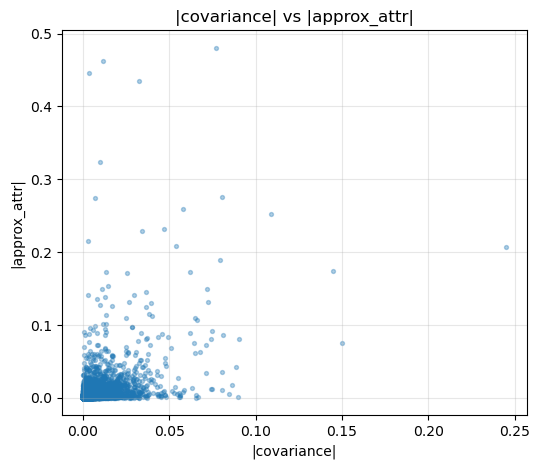

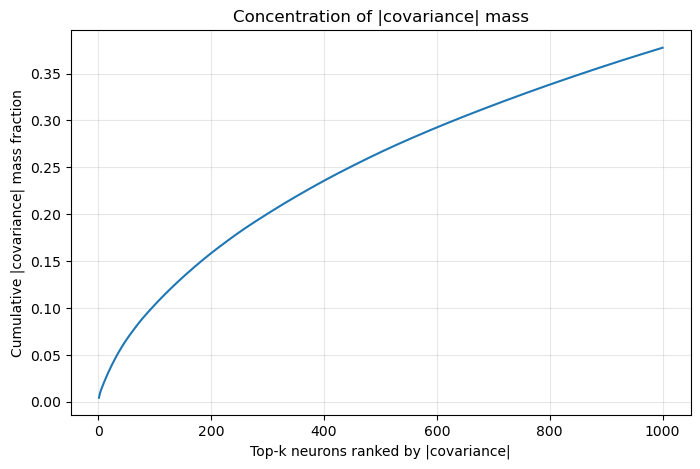

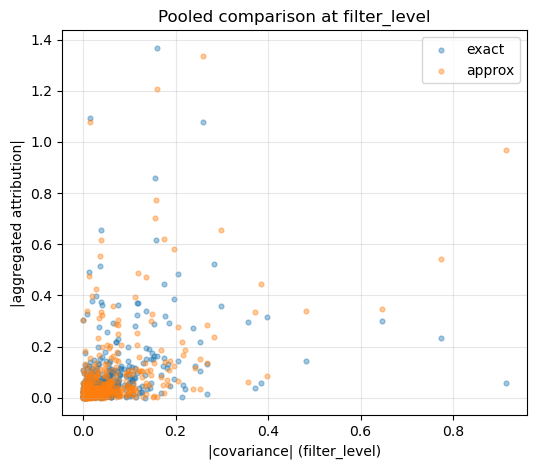

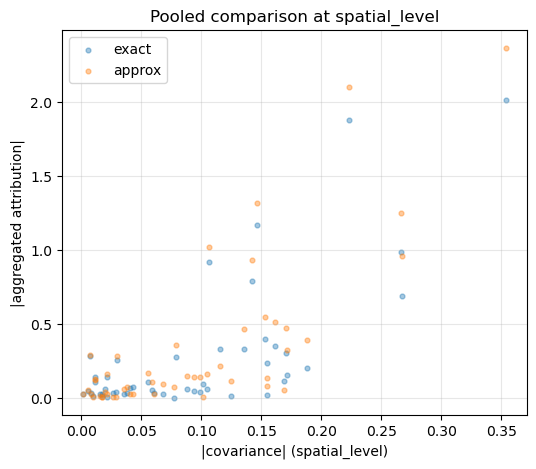

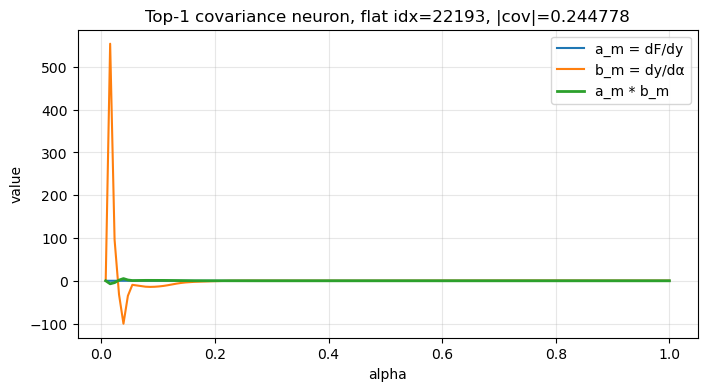

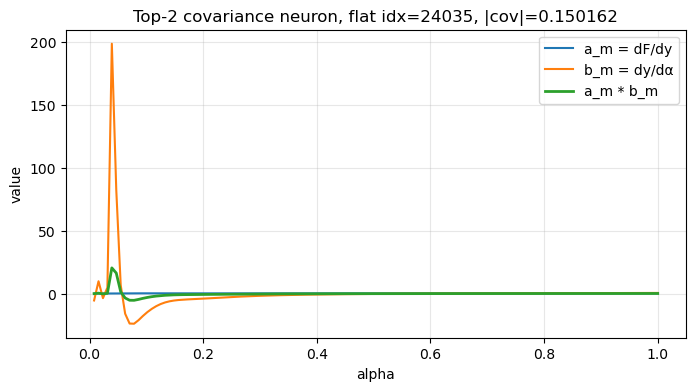

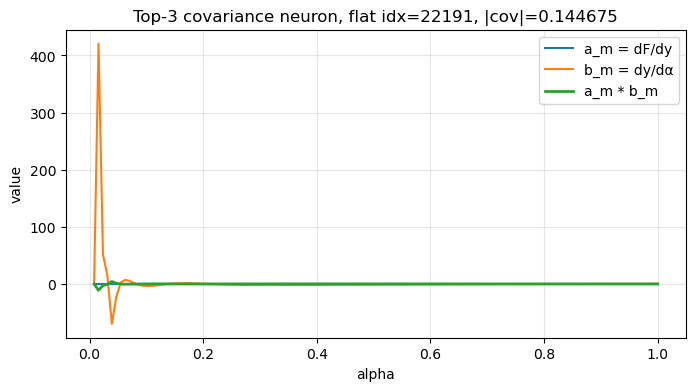

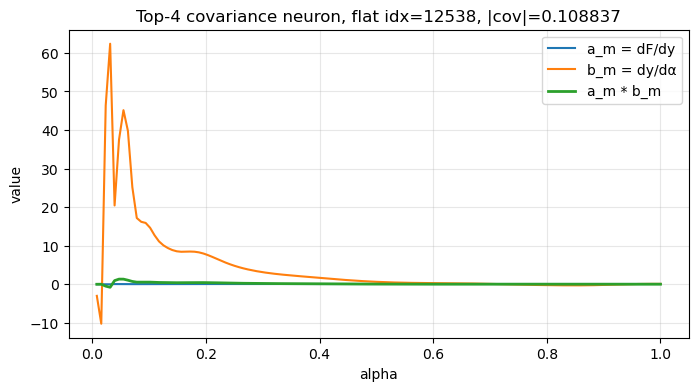

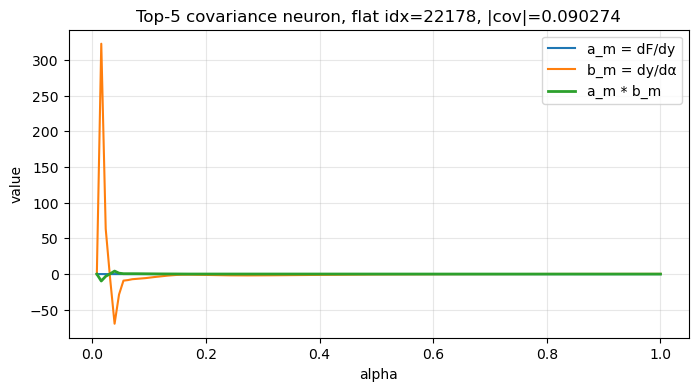

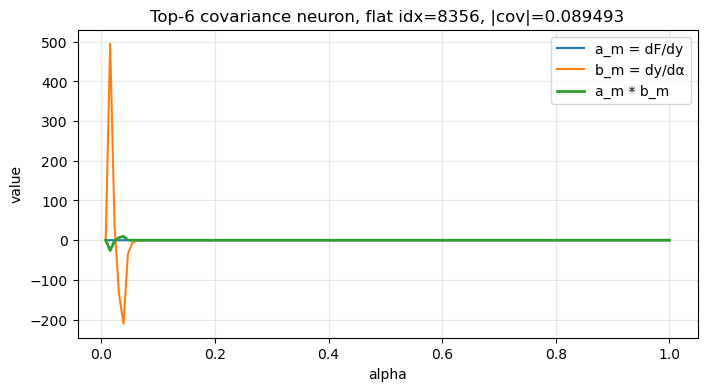

In [38]:
cov_structure_result = run_covariance_structure_experiments(
    image_path="data/jess.jpg",
    layer_name="model.9",
    n_steps=128,
    clear_every=8,
    scatter_metric="|approx_attr|",
    top_ks=(10, 25, 50, 100, 250, 500, 1000, 2000, 4000, 8000),
    top_k_path=6,
)

## Микровывод

Видно, что значения b_m резко взрываются на ранних этапах $\alpha$, а затем затухают.

Это значит, что большая часть ошибки идёт отсюда, и если мы и хотим корректировать значение, то в основном это нужно делать здесь.

При этом мы уже выводим значения с наибольшей ковариацией. Фактически ковариация есть ошибка усреднения по всей оси х в данном случае, и очевидно по графику, что большая часть ошибки идет из начала. Мы видим, что среднее произведения очень-очень сильно сглаживает этот пик, в то время как произведение средних сильно доминируется ранними слагаемыми.

In [39]:
from pathlib import Path


def _list_image_files(folder_path):
    """Return sorted image file paths from a folder."""
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    folder = Path(folder_path)
    if not folder.exists() or not folder.is_dir():
        raise ValueError(f"Папка не найдена или не является директорией: {folder_path}")

    files = [p for p in sorted(folder.iterdir()) if p.is_file() and p.suffix.lower() in exts]
    if not files:
        raise ValueError(f"В папке {folder_path} не найдено изображений поддерживаемых форматов: {sorted(exts)}")
    return files


def _build_segment_edges_from_quant(step_quant):
    """Build path segment edges in [0, 1] with the given quantization step."""
    if step_quant <= 0 or step_quant > 1:
        raise ValueError(f"step_quant должен быть в диапазоне (0, 1], получено {step_quant}")

    num_segments = int(np.ceil(1.0 / step_quant))
    edges = np.linspace(0.0, 1.0, num_segments + 1, dtype=np.float64)
    edges[-1] = 1.0
    return edges


def _summarize_covariance_tensor(cov_tensor):
    cov_flat = cov_tensor.reshape(-1)
    return {
        "cov_tensor": cov_tensor.detach().cpu(),
        "cov_flat": cov_flat.detach().cpu().numpy().astype(np.float64),
        "sum_cov": float(cov_tensor.sum().item()),
        "mean_cov": float(cov_tensor.mean().item()),
        "mean_abs_cov": float(cov_tensor.abs().mean().item()),
        "max_abs_cov": float(cov_tensor.abs().max().item()),
        "std_cov": float(cov_flat.std(unbiased=False).item()),
    }


def compute_segmented_covariance_statistics(
        model,
        hook,
        x,
        x0,
        target_class,
        n_steps=128,
        clear_every=8,
        step_quant=0.1,
):
    """Compute covariance statistics on the full path and on path segments."""
    structure = compute_path_covariance_structure(
        model=model,
        hook=hook,
        x=x,
        x0=x0,
        target_class=target_class,
        n_steps=n_steps,
        clear_every=clear_every,
    )

    a_seq = structure["a_seq"]
    b_seq = structure["b_seq"]
    alphas = structure["alphas"]
    edges = _build_segment_edges_from_quant(step_quant)

    segments = []
    global_stats = _summarize_covariance_tensor(structure["cov"])
    segments.append({
        "label": "[0.0, 1.0]",
        "start": 0.0,
        "end": 1.0,
        "num_steps": int(a_seq.shape[0]),
        **global_stats,
    })

    for start, end in zip(edges[:-1], edges[1:]):
        if end < 1.0:
            mask = (alphas >= start) & (alphas < end)
        else:
            mask = (alphas >= start) & (alphas <= end)

        idx = np.nonzero(mask)[0]
        if len(idx) == 0:
            continue

        a_seg = a_seq[idx]
        b_seg = b_seq[idx]
        seg_stats = _stack_path_statistics(a_seg, b_seg)
        cov_seg = seg_stats["cov"]

        segments.append({
            "label": f"[{start:.1f}, {end:.1f}]",
            "start": float(start),
            "end": float(end),
            "num_steps": int(len(idx)),
            **_summarize_covariance_tensor(cov_seg),
        })

    return {
        "structure": structure,
        "segments": segments,
    }


def _segment_stats(values):
    arr = np.asarray(values, dtype=np.float64)
    if arr.size == 0:
        return {"mean": float("nan"), "std": float("nan")}
    return {
        "mean": float(np.nanmean(arr)),
        "std": float(np.nanstd(arr)),
    }


def _compute_pairwise_corr_matrix(cov_stack):
    cov_stack = np.asarray(cov_stack, dtype=np.float64)
    n = cov_stack.shape[0]
    corr = np.full((n, n), np.nan, dtype=np.float64)

    for i in range(n):
        corr[i, i] = 1.0
        for j in range(i + 1, n):
            value = _pearson_np(cov_stack[i], cov_stack[j])
            corr[i, j] = value
            corr[j, i] = value
    return corr


def _build_dataset_covariance_statistics(records, segment_order):
    dataset_stats = {}

    for segment_label in segment_order:
        rows = [row for row in records if row["segment_label"] == segment_label]
        cov_stack = np.stack([row["cov_flat"] for row in rows], axis=0)
        mean_map = cov_stack.mean(axis=0)
        std_map = cov_stack.std(axis=0)
        corr_matrix = _compute_pairwise_corr_matrix(cov_stack)
        tri_upper = corr_matrix[np.triu_indices(corr_matrix.shape[0], k=1)]
        tri_upper = tri_upper[~np.isnan(tri_upper)]

        dataset_stats[segment_label] = {
            "mean_map": mean_map,
            "std_map": std_map,
            "dataset_mean_map_std": float(mean_map.std()),
            "dataset_neuron_std_mean": float(std_map.mean()),
            "pairwise_corr_matrix": corr_matrix,
            "pairwise_corr_mean": float(np.nanmean(tri_upper)) if tri_upper.size else float("nan"),
            "pairwise_corr_std": float(np.nanstd(tri_upper)) if tri_upper.size else float("nan"),
        }

        for row, cov_flat in zip(rows, cov_stack):
            row["mean_abs_delta_to_dataset"] = float(np.abs(cov_flat - mean_map).mean())
            row["rmse_to_dataset"] = float(np.sqrt(np.mean((cov_flat - mean_map) ** 2)))
            row["corr_to_dataset_mean"] = _pearson_np(cov_flat, mean_map)
            row["dataset_mean_map_std"] = dataset_stats[segment_label]["dataset_mean_map_std"]
            row["dataset_neuron_std_mean"] = dataset_stats[segment_label]["dataset_neuron_std_mean"]
            row["pairwise_corr_mean"] = dataset_stats[segment_label]["pairwise_corr_mean"]
            row["pairwise_corr_std"] = dataset_stats[segment_label]["pairwise_corr_std"]

    return dataset_stats


def _plot_metric_with_errorbars(records, metric_key, ylabel, title_suffix, segment_labels=None, raw_alpha=0.18):
    if segment_labels is None:
        segment_labels = []
        for row in records:
            if row["segment_label"] not in segment_labels:
                segment_labels.append(row["segment_label"])

    xs = np.arange(len(segment_labels), dtype=np.float64)
    means = []
    stds = []

    plt.figure(figsize=(10, 5))
    for x_pos, segment_label in zip(xs, segment_labels):
        vals = [row[metric_key] for row in records if row["segment_label"] == segment_label]
        stats = _segment_stats(vals)
        means.append(stats["mean"])
        stds.append(stats["std"])
        jitter = np.linspace(-0.08, 0.08, num=len(vals)) if len(vals) > 1 else np.array([0.0])
        plt.scatter(np.full(len(vals), x_pos) + jitter, vals, s=24, alpha=raw_alpha, color="tab:blue")

    plt.errorbar(xs, means, yerr=stds, fmt="o-", capsize=4, color="tab:red", linewidth=2)
    plt.xticks(xs, segment_labels, rotation=45)
    plt.xlabel("Path segment")
    plt.ylabel(ylabel)
    plt.title(title_suffix)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def _plot_dataset_covariance_gap(records, segment_labels=None):
    if segment_labels is None:
        segment_labels = []
        for row in records:
            if row["segment_label"] not in segment_labels:
                segment_labels.append(row["segment_label"])

    xs = np.arange(len(segment_labels), dtype=np.float64)
    image_std_mean = []
    image_std_std = []
    dataset_mean_map_std = []
    dataset_neuron_std_mean = []
    mean_abs_delta = []
    mean_abs_delta_std = []
    corr_to_dataset = []
    corr_to_dataset_std = []
    pairwise_corr_mean = []
    pairwise_corr_std = []

    for segment_label in segment_labels:
        rows = [row for row in records if row["segment_label"] == segment_label]
        std_stats = _segment_stats([row["std_cov"] for row in rows])
        delta_stats = _segment_stats([row["mean_abs_delta_to_dataset"] for row in rows])
        corr_stats = _segment_stats([row["corr_to_dataset_mean"] for row in rows])

        image_std_mean.append(std_stats["mean"])
        image_std_std.append(std_stats["std"])
        dataset_mean_map_std.append(rows[0]["dataset_mean_map_std"])
        dataset_neuron_std_mean.append(rows[0]["dataset_neuron_std_mean"])
        mean_abs_delta.append(delta_stats["mean"])
        mean_abs_delta_std.append(delta_stats["std"])
        corr_to_dataset.append(corr_stats["mean"])
        corr_to_dataset_std.append(corr_stats["std"])
        pairwise_corr_mean.append(rows[0]["pairwise_corr_mean"])
        pairwise_corr_std.append(rows[0]["pairwise_corr_std"])

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].errorbar(xs, image_std_mean, yerr=image_std_std, fmt="o-", capsize=4, label="image std across neurons")
    axes[0].plot(xs, dataset_mean_map_std, "s--", label="std of dataset mean map")
    axes[0].plot(xs, dataset_neuron_std_mean, "^--", label="mean neuron std across dataset")
    axes[0].set_xticks(xs)
    axes[0].set_xticklabels(segment_labels, rotation=45)
    axes[0].set_ylabel("std")
    axes[0].set_title("Neuron-wise spread: image vs dataset")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(fontsize=8)

    axes[1].errorbar(xs, mean_abs_delta, yerr=mean_abs_delta_std, fmt="o-", capsize=4, color="tab:orange")
    axes[1].set_xticks(xs)
    axes[1].set_xticklabels(segment_labels, rotation=45)
    axes[1].set_ylabel("mean |cov_image - mean_cov_dataset|")
    axes[1].set_title("Distance from image covariance map to dataset mean map")
    axes[1].grid(True, alpha=0.3)

    axes[2].errorbar(xs, corr_to_dataset, yerr=corr_to_dataset_std, fmt="o-", capsize=4, label="corr(image, dataset mean)")
    axes[2].errorbar(xs, pairwise_corr_mean, yerr=pairwise_corr_std, fmt="s--", capsize=4, label="pairwise corr(image_i, image_j)")
    axes[2].set_xticks(xs)
    axes[2].set_xticklabels(segment_labels, rotation=45)
    axes[2].set_ylabel("pearson correlation")
    axes[2].set_title("Similarity of covariance maps")
    axes[2].grid(True, alpha=0.3)
    axes[2].legend(fontsize=8)

    fig.tight_layout()
    plt.show()


def _plot_mean_cov_violin(records, segment_labels):
    if not segment_labels:
        return

    data = []
    means = []
    stds = []
    for segment_label in segment_labels:
        vals = [row["mean_cov"] for row in records if row["segment_label"] == segment_label]
        if not vals:
            continue
        data.append(np.asarray(vals, dtype=np.float64))
        stats = _segment_stats(vals)
        means.append(stats["mean"])
        stds.append(stats["std"])

    if not data:
        return

    xs = np.arange(1, len(data) + 1, dtype=np.float64)
    plt.figure(figsize=(9, 5))
    violin = plt.violinplot(data, positions=xs, widths=0.8, showmeans=False, showmedians=False, showextrema=False)
    for body in violin["bodies"]:
        body.set_facecolor("tab:blue")
        body.set_edgecolor("black")
        body.set_alpha(0.28)

    plt.errorbar(xs, means, yerr=stds, fmt="o-", capsize=4, color="black", linewidth=2, label="mean ± std")
    plt.xticks(xs, segment_labels, rotation=25)
    plt.xlabel("Path segment")
    plt.ylabel("Mean covariance per image")
    plt.title("Violinplot of image-level mean covariance for early path segments")
    plt.grid(True, axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()



def _plot_per_neuron_covariance_cloud(records, segment_label="[0.0, 0.1]"):
    rows = [row for row in records if row["segment_label"] == segment_label]
    if not rows:
        return

    cov_stack = np.stack([row["cov_flat"] for row in rows], axis=0)
    neuron_idx = np.arange(cov_stack.shape[1], dtype=np.int64)
    mean_cov = cov_stack.mean(axis=0)
    std_cov = cov_stack.std(axis=0)

    plt.figure(figsize=(14, 6))
    for cov_values in cov_stack:
        plt.scatter(neuron_idx, cov_values, s=5, alpha=0.06, color="tab:blue")

    plt.plot(neuron_idx, mean_cov, color="black", linewidth=1.5, label="mean")
    plt.fill_between(neuron_idx, mean_cov - std_cov, mean_cov + std_cov, color="tab:red", alpha=0.22, label="mean ± std")
    plt.xlabel("Neuron index")
    plt.ylabel("Covariance")
    plt.title(f"Per-neuron covariance values across images for segment {segment_label}")
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()


def _binary_membership_mask(values, low_fraction=None, top_k=None):
    abs_vals = np.abs(np.asarray(values, dtype=np.float64))
    n = abs_vals.size
    mask = np.zeros(n, dtype=np.float64)

    if low_fraction is not None:
        k = min(n, max(1, int(np.ceil(low_fraction * n))))
        order = np.argsort(abs_vals)
        mask[order[:k]] = 1.0
        return mask

    if top_k is not None:
        k = min(n, max(1, int(top_k)))
        order = np.argsort(abs_vals)[::-1]
        mask[order[:k]] = 1.0
        return mask

    raise ValueError("Нужно задать low_fraction или top_k")


def _compute_pairwise_jaccard_matrix(binary_stack):
    binary_stack = np.asarray(binary_stack, dtype=np.float64)
    n = binary_stack.shape[0]
    out = np.full((n, n), np.nan, dtype=np.float64)

    for i in range(n):
        out[i, i] = 1.0
        for j in range(i + 1, n):
            inter = np.sum(binary_stack[i] * binary_stack[j])
            union = np.sum((binary_stack[i] + binary_stack[j]) > 0)
            value = float(inter / union) if union > 0 else float("nan")
            out[i, j] = value
            out[j, i] = value
    return out


def _plot_zero_neuron_stability(records, segment_label="[0.0, 0.1]", zero_fraction=0.8, max_images=20):
    rows = [row for row in records if row["segment_label"] == segment_label]
    if not rows:
        return

    cov_stack = np.stack([row["cov_flat"] for row in rows], axis=0)
    zero_masks = np.stack([
        _binary_membership_mask(cov_values, low_fraction=zero_fraction)
        for cov_values in cov_stack
    ], axis=0)
    zero_frequency = zero_masks.mean(axis=0)
    sorted_frequency = np.sort(zero_frequency)[::-1]
    jaccard = _compute_pairwise_jaccard_matrix(zero_masks)
    tri_upper = jaccard[np.triu_indices(jaccard.shape[0], k=1)]
    tri_upper = tri_upper[~np.isnan(tri_upper)]
    baseline_jaccard = zero_fraction / (2.0 - zero_fraction)

    labels = [row["image_name"] for row in rows[:max_images]]
    heatmap = jaccard[:max_images, :max_images]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].plot(sorted_frequency, linewidth=1.5)
    axes[0].axhline(zero_fraction, color="tab:red", linestyle="--", label="random baseline")
    axes[0].set_xlabel("Neuron rank after sorting by near-zero frequency")
    axes[0].set_ylabel("Fraction of images where neuron is near-zero")
    axes[0].set_title(f"Near-zero neuron stability on {segment_label}")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(fontsize=8)

    axes[1].hist(zero_frequency, bins=30, alpha=0.8)
    axes[1].axvline(zero_fraction, color="tab:red", linestyle="--", label="random baseline")
    axes[1].set_xlabel("Near-zero frequency across images")
    axes[1].set_ylabel("Neuron count")
    axes[1].set_title("How concentrated are the same near-zero neurons?")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(fontsize=8)

    im = axes[2].imshow(heatmap, cmap="viridis", vmin=0.0, vmax=1.0)
    axes[2].set_xticks(range(len(labels)))
    axes[2].set_xticklabels(labels, rotation=90)
    axes[2].set_yticks(range(len(labels)))
    axes[2].set_yticklabels(labels)
    axes[2].set_title(
        f"Pairwise Jaccard of near-zero sets\nmean={np.nanmean(tri_upper):.3f}, baseline={baseline_jaccard:.3f}"
    )
    fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

    fig.tight_layout()
    plt.show()


def _plot_classwise_active_neuron_consistency(
    records,
    segment_label="[0.0, 0.1]",
    class_key="target_name",
    num_classes=5,
    images_per_class=10,
    top_k=100,
):
    rows = [row for row in records if row["segment_label"] == segment_label]
    if not rows:
        return

    class_to_rows = {}
    for row in rows:
        class_to_rows.setdefault(row[class_key], [])
        if row["image_name"] not in {item["image_name"] for item in class_to_rows[row[class_key]]}:
            class_to_rows[row[class_key]].append(row)

    eligible = [
        (class_name, class_rows)
        for class_name, class_rows in class_to_rows.items()
        if len(class_rows) >= images_per_class
    ]
    eligible.sort(key=lambda item: (-len(item[1]), item[0]))
    chosen = eligible[:num_classes]
    if not chosen:
        print(f"Не найдено {images_per_class} изображений ни для одного класса по ключу {class_key}.")
        return

    fig, axes = plt.subplots(2, len(chosen), figsize=(4.5 * len(chosen), 8))
    if len(chosen) == 1:
        axes = np.asarray(axes).reshape(2, 1)

    for col, (class_name, class_rows) in enumerate(chosen):
        class_rows = sorted(class_rows, key=lambda row: row["image_name"])[:images_per_class]
        cov_stack = np.stack([row["cov_flat"] for row in class_rows], axis=0)
        active_masks = np.stack([
            _binary_membership_mask(cov_values, top_k=top_k)
            for cov_values in cov_stack
        ], axis=0)
        active_frequency = np.sort(active_masks.mean(axis=0))[::-1]
        jaccard = _compute_pairwise_jaccard_matrix(active_masks)
        tri_upper = jaccard[np.triu_indices(jaccard.shape[0], k=1)]
        tri_upper = tri_upper[~np.isnan(tri_upper)]
        baseline = (top_k / cov_stack.shape[1]) / (2.0 - (top_k / cov_stack.shape[1]))

        axes[0, col].plot(active_frequency, linewidth=1.5)
        axes[0, col].axhline(top_k / cov_stack.shape[1], color="tab:red", linestyle="--", label="random baseline")
        axes[0, col].set_title(f"{class_name}\nactive-neuron frequency")
        axes[0, col].set_xlabel("Neuron rank")
        axes[0, col].set_ylabel("Fraction of class images in top-k")
        axes[0, col].grid(True, alpha=0.3)
        axes[0, col].legend(fontsize=7)

        im = axes[1, col].imshow(jaccard, cmap="viridis", vmin=0.0, vmax=1.0)
        labels = [row["image_name"] for row in class_rows]
        axes[1, col].set_xticks(range(len(labels)))
        axes[1, col].set_xticklabels(labels, rotation=90, fontsize=7)
        axes[1, col].set_yticks(range(len(labels)))
        axes[1, col].set_yticklabels(labels, fontsize=7)
        axes[1, col].set_title(
            f"Jaccard of top-{min(top_k, cov_stack.shape[1])} |cov| neurons\nmean={np.nanmean(tri_upper):.3f}, baseline={baseline:.3f}"
        )
        fig.colorbar(im, ax=axes[1, col], fraction=0.046, pad=0.04)

    fig.suptitle(
        f"Are covariance-heavy neurons shared inside a class? segment={segment_label}, class_key={class_key}",
        y=1.02,
    )
    fig.tight_layout()
    plt.show()


def _plot_covariance_similarity_heatmap(records, segment_label="[0.0, 1.0]", max_images=20):
    rows = [row for row in records if row["segment_label"] == segment_label]
    if not rows:
        return

    rows = rows[:max_images]
    cov_stack = np.stack([row["cov_flat"] for row in rows], axis=0)
    corr_matrix = _compute_pairwise_corr_matrix(cov_stack)
    labels = [row["image_name"] for row in rows]

    plt.figure(figsize=(8, 7))
    plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1.0, vmax=1.0)
    plt.colorbar(label="Pearson correlation")
    plt.xticks(range(len(labels)), labels, rotation=90)
    plt.yticks(range(len(labels)), labels)
    plt.title(f"Pairwise covariance-map similarity for segment {segment_label}")
    plt.tight_layout()
    plt.show()


def run_folder_segmented_covariance_analysis(
        folder_path,
        n,
        step_quant,
        layer_name=DEFAULT_LAYER_NAME,
        n_steps=128,
        clear_every=8,
):
    """Analyze covariance on the full path and path segments for up to n images in a folder."""
    if n <= 0:
        raise ValueError(f"n должен быть положительным, получено {n}")

    image_paths = _list_image_files(folder_path)[:n]
    records = []

    for image_path in image_paths:
        x, _ = load_image(str(image_path))
        x0 = black_baseline_like(x)
        source_class = image_path.stem.rsplit("_", 1)[0] if "_" in image_path.stem else image_path.stem

        hook = LayerHook(model, layer_name)
        try:
            hook.clear()
            out = model(x)
            _, logits = split_classifier_output(out)
            target_class = int(logits[0].argmax().item())
            target_name = class_names[target_class]

            segmented = compute_segmented_covariance_statistics(
                model=model,
                hook=hook,
                x=x,
                x0=x0,
                target_class=target_class,
                n_steps=n_steps,
                clear_every=clear_every,
                step_quant=step_quant,
            )
        finally:
            hook.remove()
            clear_backend_cache()

        for segment in segmented["segments"]:
            records.append({
                "image_path": str(image_path),
                "image_name": image_path.name,
                "source_class": source_class,
                "target_class": target_class,
                "target_name": target_name,
                "segment_label": segment["label"],
                "segment_start": segment["start"],
                "segment_end": segment["end"],
                "num_steps": segment["num_steps"],
                "sum_cov": segment["sum_cov"],
                "mean_cov": segment["mean_cov"],
                "mean_abs_cov": segment["mean_abs_cov"],
                "max_abs_cov": segment["max_abs_cov"],
                "std_cov": segment["std_cov"],
                "cov_flat": segment["cov_flat"],
            })

    if not records:
        raise ValueError("Не удалось собрать статистику ни для одного изображения.")

    segment_order = []
    for row in records:
        if row["segment_label"] not in segment_order:
            segment_order.append(row["segment_label"])

    dataset_stats = _build_dataset_covariance_statistics(records, segment_order)
    focus_segments = [label for label in ["[0.0, 0.1]", "[0.1, 0.2]", "[0.2, 0.3]"] if label in segment_order]

    print("folder:", folder_path)
    print("layer:", layer_name)
    print("n images:", len(image_paths))
    print("step_quant:", step_quant)
    print("n_steps:", n_steps)
    print()

    for image_name in sorted({row["image_name"] for row in records}):
        image_rows = [row for row in records if row["image_name"] == image_name]
        target_class = image_rows[0]["target_class"]
        target_name = image_rows[0]["target_name"]
        print(f"image: {image_name} | target class: {target_class} {target_name}")
        for row in image_rows:
            print(
                f"  {row['segment_label']:>10s} | steps={row['num_steps']:3d} "
                f"| sum_cov={row['sum_cov']:+.6f} "
                f"| mean_cov={row['mean_cov']:+.6f} "
                f"| mean|cov|={row['mean_abs_cov']:.6f} "
                f"| max|cov|={row['max_abs_cov']:.6f} "
                f"| std={row['std_cov']:.6f}"
            )
        print()

    print("Aggregate over images (mean ± std):")
    for segment_label in segment_order:
        rows = [row for row in records if row["segment_label"] == segment_label]
        mean_cov_stats = _segment_stats([row["mean_cov"] for row in rows])
        mean_abs_cov_stats = _segment_stats([row["mean_abs_cov"] for row in rows])
        std_cov_stats = _segment_stats([row["std_cov"] for row in rows])
        delta_stats = _segment_stats([row["mean_abs_delta_to_dataset"] for row in rows])
        corr_stats = _segment_stats([row["corr_to_dataset_mean"] for row in rows])

        print(f"segment: {segment_label}")
        print(f"  mean_cov                     = {mean_cov_stats['mean']:+.6f} ± {mean_cov_stats['std']:.6f}")
        print(f"  mean|cov|                    = {mean_abs_cov_stats['mean']:.6f} ± {mean_abs_cov_stats['std']:.6f}")
        print(f"  std_cov                      = {std_cov_stats['mean']:.6f} ± {std_cov_stats['std']:.6f}")
        print(f"  mean|cov - dataset_mean_map| = {delta_stats['mean']:.6f} ± {delta_stats['std']:.6f}")
        print(f"  corr(image, dataset_mean)    = {corr_stats['mean']:+.6f} ± {corr_stats['std']:.6f}")
        print(f"  pairwise corr(images)        = {rows[0]['pairwise_corr_mean']:+.6f} ± {rows[0]['pairwise_corr_std']:.6f}")
        print(f"  std(dataset mean map)        = {rows[0]['dataset_mean_map_std']:.6f}")
        print(f"  mean neuron std(dataset)     = {rows[0]['dataset_neuron_std_mean']:.6f}")
        print()

    _plot_mean_cov_violin(records, segment_labels=focus_segments)
    _plot_per_neuron_covariance_cloud(records, segment_label="[0.0, 0.1]")
    _plot_metric_with_errorbars(
        records,
        metric_key="mean_cov",
        ylabel="mean covariance",
        title_suffix="Segmented mean covariance (signed) for early path segments",
        segment_labels=focus_segments if focus_segments else segment_order,
    )
    _plot_metric_with_errorbars(
        records,
        metric_key="sum_cov",
        ylabel="sum covariance",
        title_suffix="Segmented covariance sum (mean ± std over images)",
        segment_labels=segment_order,
    )
    _plot_metric_with_errorbars(
        records,
        metric_key="mean_abs_cov",
        ylabel="mean |covariance|",
        title_suffix="Segmented mean absolute covariance (mean ± std over images)",
        segment_labels=segment_order,
    )
    _plot_metric_with_errorbars(
        records,
        metric_key="max_abs_cov",
        ylabel="max |covariance|",
        title_suffix="Segmented max absolute covariance (mean ± std over images)",
        segment_labels=segment_order,
    )
    _plot_dataset_covariance_gap(records, segment_labels=segment_order)
    _plot_zero_neuron_stability(records, segment_label="[0.0, 0.1]", zero_fraction=0.8, max_images=min(20, len(image_paths)))
    _plot_classwise_active_neuron_consistency(
        records,
        segment_label="[0.0, 0.1]",
        class_key="target_name",
        num_classes=5,
        images_per_class=10,
        top_k=100,
    )
    _plot_covariance_similarity_heatmap(records, segment_label="[0.0, 1.0]", max_images=min(20, len(image_paths)))

    return {
        "records": records,
        "segment_order": segment_order,
        "dataset_stats": dataset_stats,
    }


folder: ../stats/oxford_padded
layer: model.6
n images: 50
step_quant: 0.1
n_steps: 128

image: Abyssinian_1.png | target class: 435 bathtub
  [0.0, 1.0] | steps=128 | sum_cov=-0.296931 | mean_cov=-0.000006 | mean|cov|=0.001595 | max|cov|=0.134050 | std=0.005227
  [0.0, 0.1] | steps= 12 | sum_cov=-2.735511 | mean_cov=-0.000055 | mean|cov|=0.007321 | max|cov|=0.972506 | std=0.025881
  [0.1, 0.2] | steps= 13 | sum_cov=-0.188819 | mean_cov=-0.000004 | mean|cov|=0.000699 | max|cov|=0.103601 | std=0.002766
  [0.2, 0.3] | steps= 13 | sum_cov=+0.244380 | mean_cov=+0.000005 | mean|cov|=0.000135 | max|cov|=0.031948 | std=0.000493
  [0.3, 0.4] | steps= 13 | sum_cov=+0.128474 | mean_cov=+0.000003 | mean|cov|=0.000053 | max|cov|=0.011491 | std=0.000194
  [0.4, 0.5] | steps= 12 | sum_cov=+0.009567 | mean_cov=+0.000000 | mean|cov|=0.000018 | max|cov|=0.002571 | std=0.000060
  [0.5, 0.6] | steps= 13 | sum_cov=-0.005915 | mean_cov=-0.000000 | mean|cov|=0.000011 | max|cov|=0.001579 | std=0.000038
  [0.

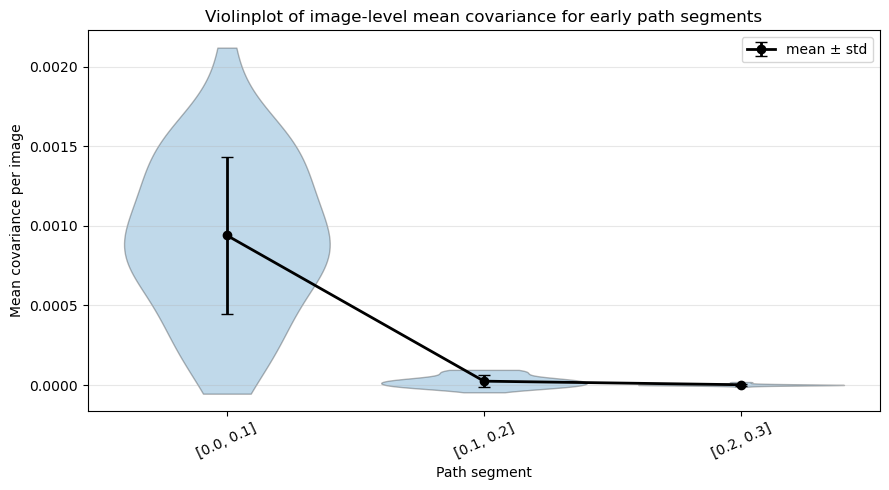

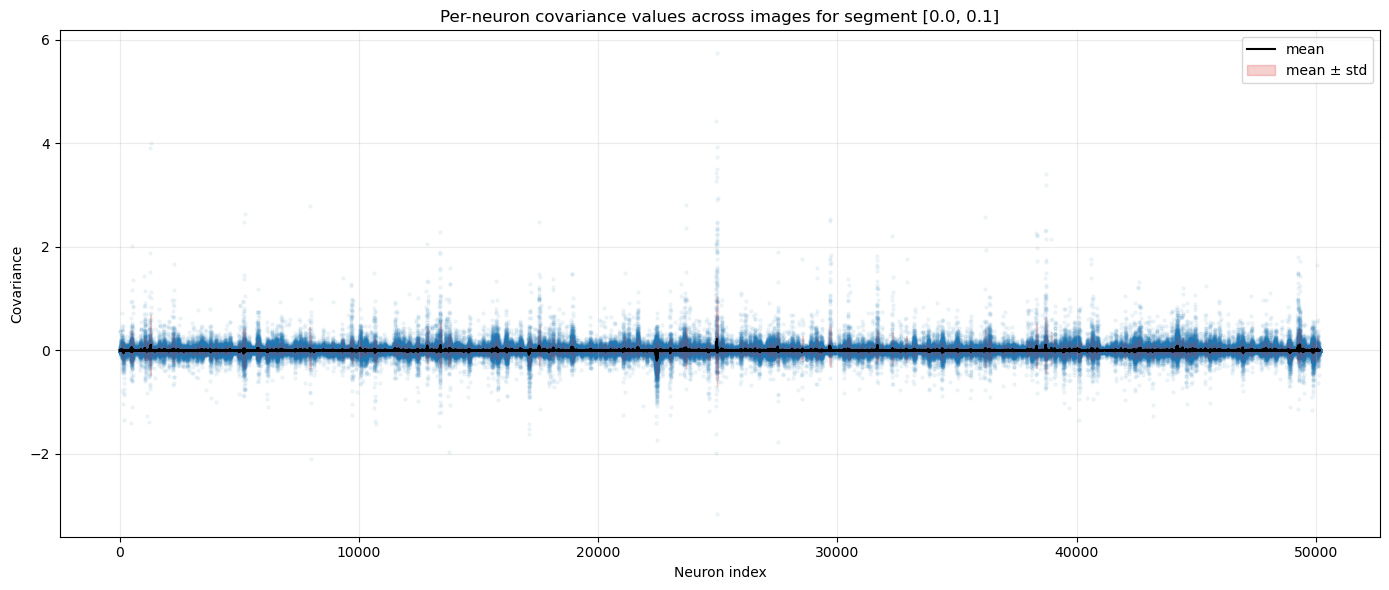

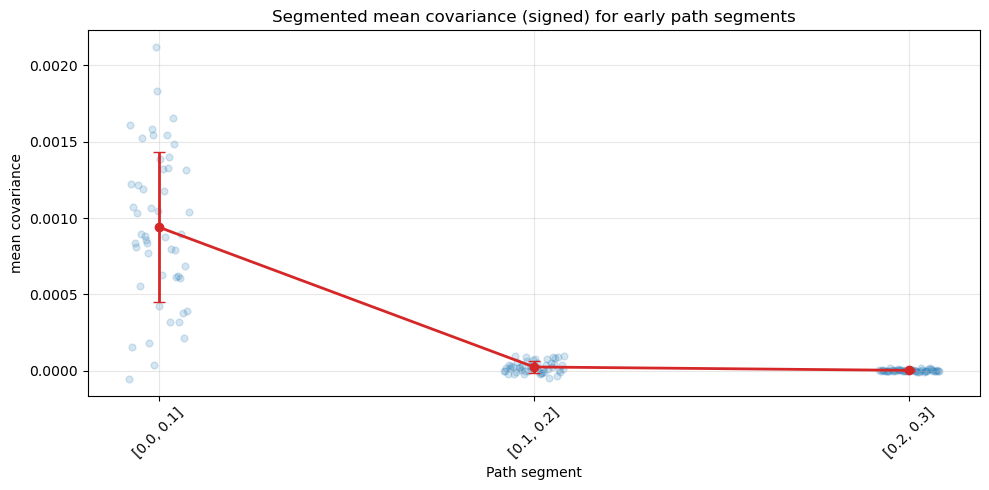

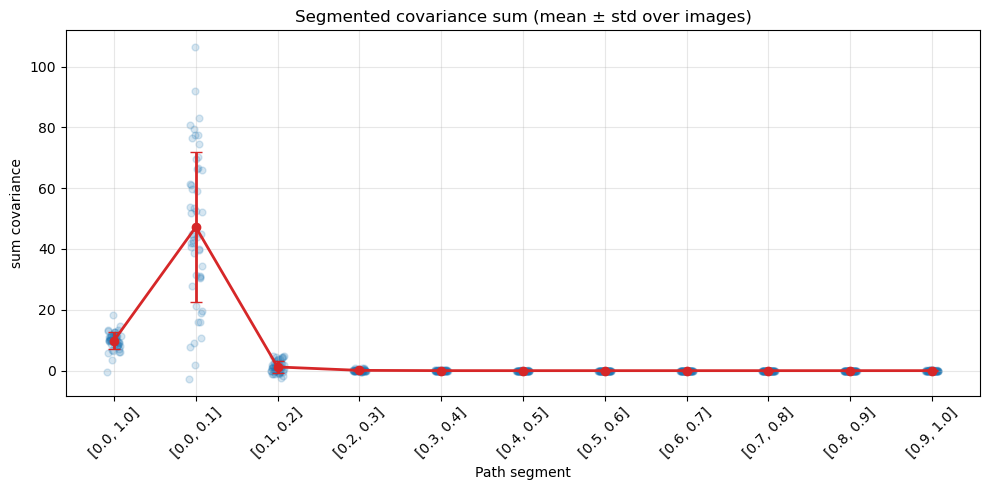

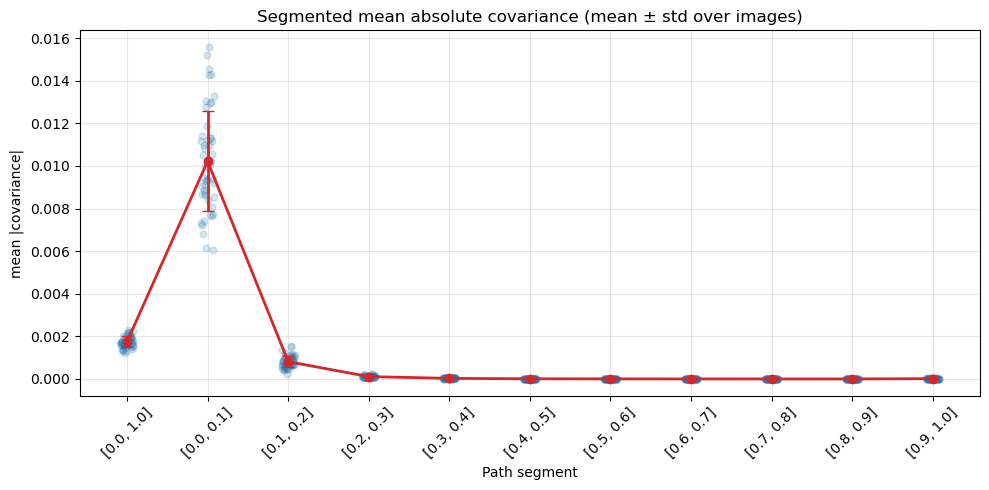

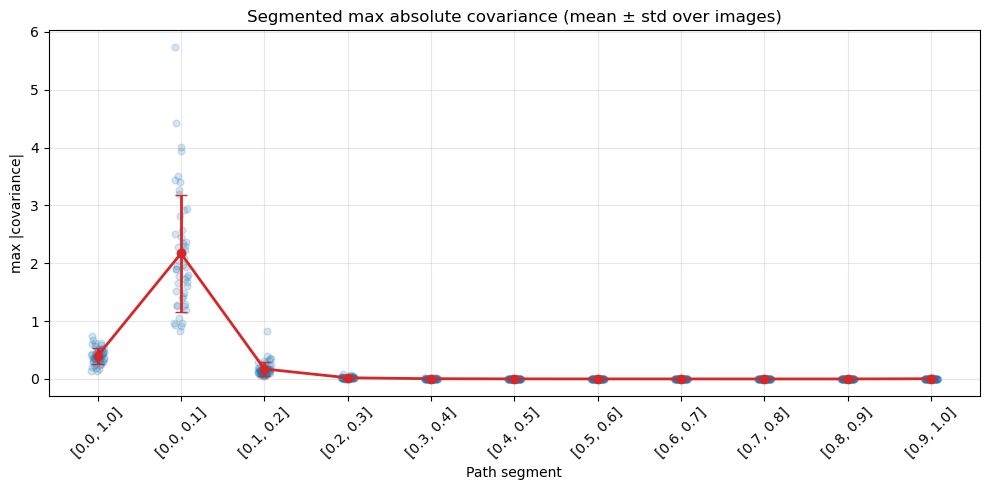

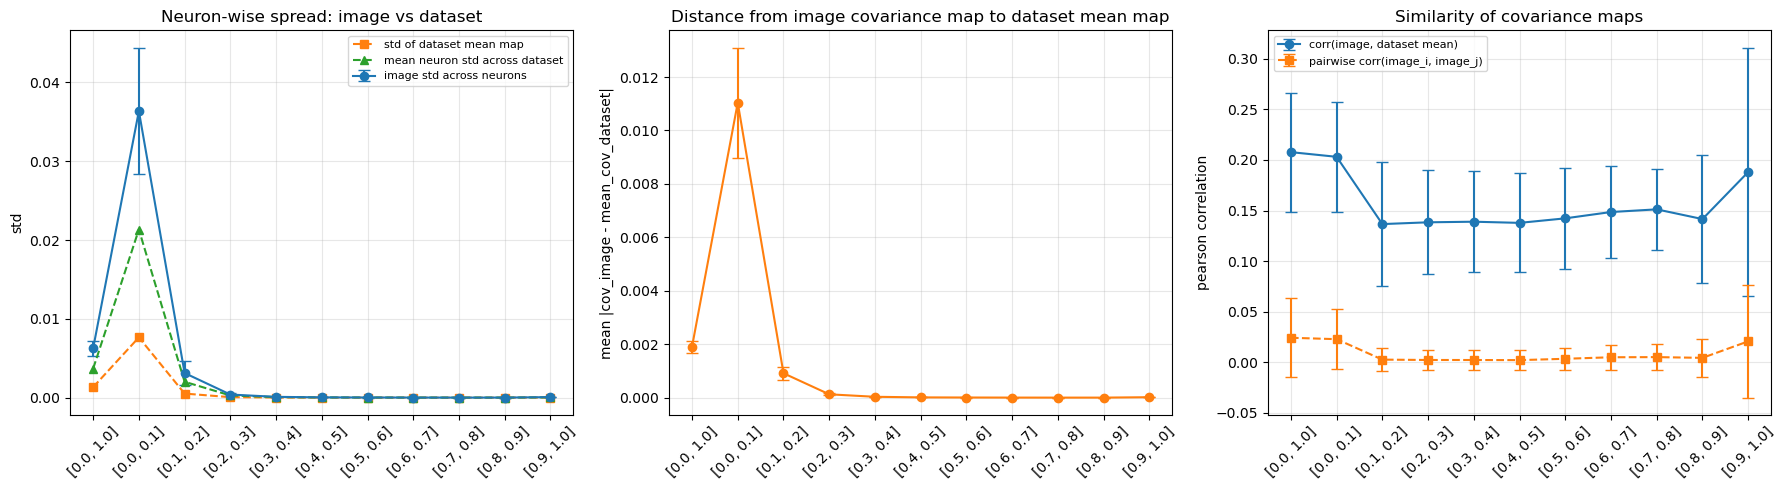

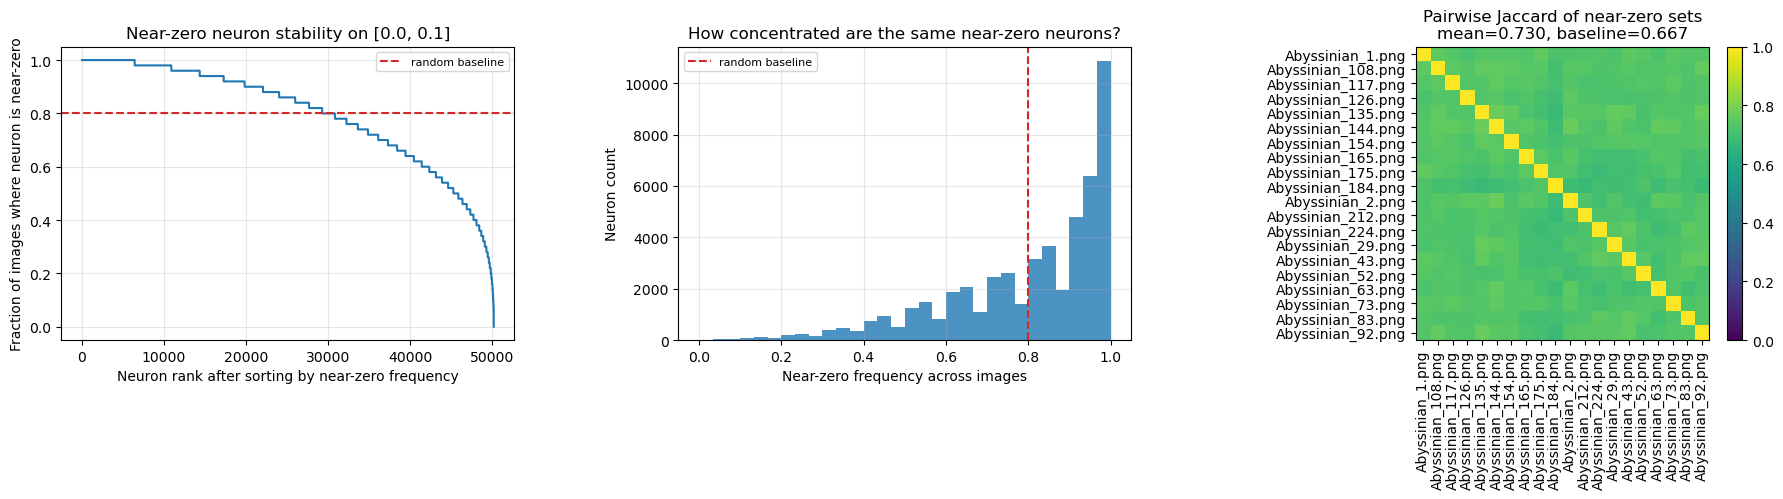

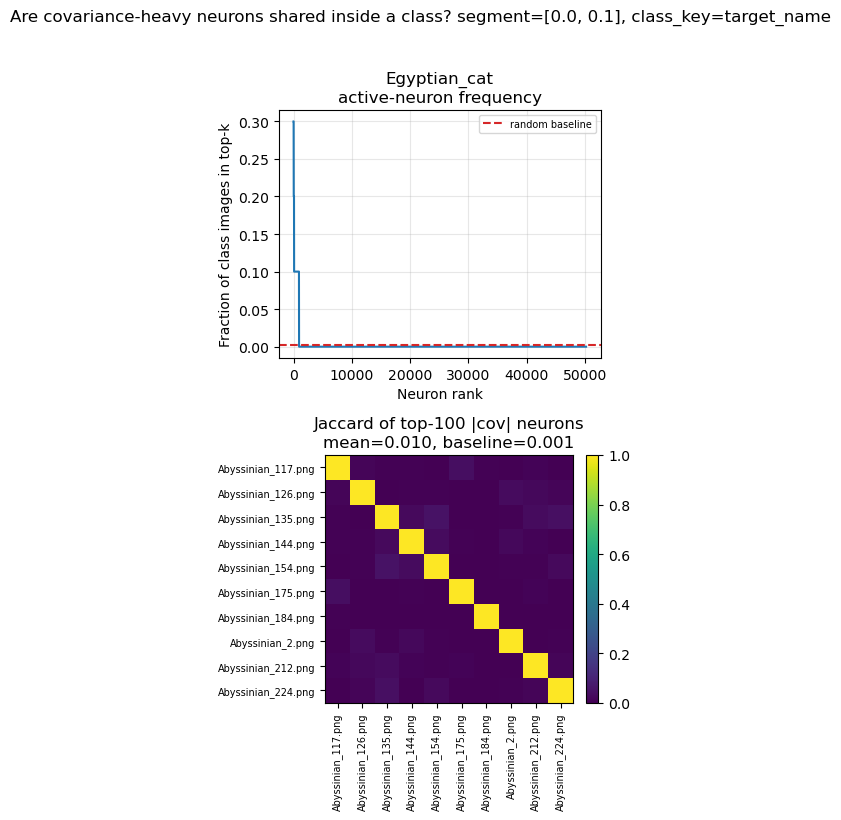

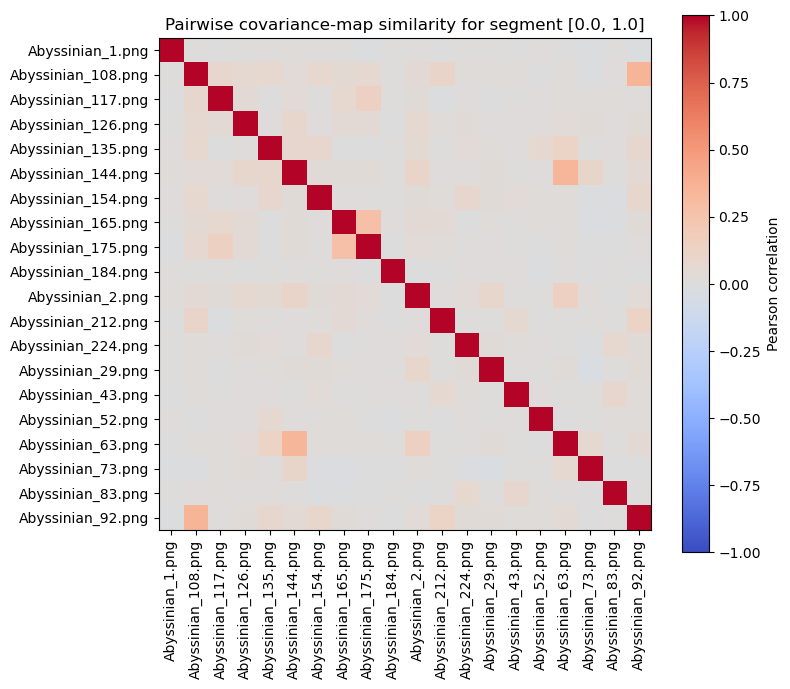

In [40]:

folder_cov_result = run_folder_segmented_covariance_analysis(
    folder_path="../stats/oxford_padded",
    n=50,
    step_quant=0.1,
    layer_name="model.6",
    n_steps=128,
    clear_every=8,
)

In [41]:
def _segment_index_mask(alphas, start, end):
    alphas = np.asarray(alphas, dtype=np.float64)
    if end < 1.0:
        return np.nonzero((alphas >= start) & (alphas < end))[0]
    return np.nonzero((alphas >= start) & (alphas <= end))[0]



def _safe_divide_np(num, den):
    num = np.asarray(num, dtype=np.float64)
    den = np.asarray(den, dtype=np.float64)
    out = np.zeros_like(num, dtype=np.float64)
    mask = np.abs(den) > 1e-12
    out[mask] = num[mask] / den[mask]
    return out



def _nan_to_num_dict(row):
    clean = {}
    for key, value in row.items():
        if isinstance(value, (np.floating, float)):
            if not np.isfinite(value):
                clean[key] = 0.0
            else:
                clean[key] = float(value)
        elif isinstance(value, (np.integer, int)):
            clean[key] = int(value)
        else:
            clean[key] = value
    return clean



def compute_covariance_regression_features(structure, segment_start=0.0, segment_end=0.1, micro_bins=5):
    alphas = np.asarray(structure["alphas"], dtype=np.float64)
    idx = _segment_index_mask(alphas, segment_start, segment_end)
    if len(idx) == 0:
        raise ValueError(f"Нет alpha-сэмплов в сегменте [{segment_start}, {segment_end}]")

    a_seg = structure["a_seq"][idx]
    b_seg = structure["b_seq"][idx]
    seg_stats = _stack_path_statistics(a_seg, b_seg)

    a_np = a_seg.detach().cpu().numpy().reshape(len(idx), -1).astype(np.float64)
    b_np = b_seg.detach().cpu().numpy().reshape(len(idx), -1).astype(np.float64)
    cov_np = seg_stats["cov"].detach().cpu().numpy().reshape(-1).astype(np.float64)

    mean_a = seg_stats["mean_a"].detach().cpu().numpy().reshape(-1).astype(np.float64)
    mean_b = seg_stats["mean_b"].detach().cpu().numpy().reshape(-1).astype(np.float64)
    std_a = seg_stats["std_a"].detach().cpu().numpy().reshape(-1).astype(np.float64)
    std_b = seg_stats["std_b"].detach().cpu().numpy().reshape(-1).astype(np.float64)
    var_a = seg_stats["var_a"].detach().cpu().numpy().reshape(-1).astype(np.float64)
    var_b = seg_stats["var_b"].detach().cpu().numpy().reshape(-1).astype(np.float64)
    corr_ab = seg_stats["corr"].detach().cpu().numpy().reshape(-1).astype(np.float64)
    sign_flip_a = seg_stats["sign_flip_a"].detach().cpu().numpy().reshape(-1).astype(np.float64)
    sign_flip_b = seg_stats["sign_flip_b"].detach().cpu().numpy().reshape(-1).astype(np.float64)
    mean_abs_diff_a = seg_stats["mean_abs_diff_a"].detach().cpu().numpy().reshape(-1).astype(np.float64)
    mean_abs_diff_b = seg_stats["mean_abs_diff_b"].detach().cpu().numpy().reshape(-1).astype(np.float64)

    approx_attr = mean_a * mean_b
    a_first = a_np[0]
    a_last = a_np[-1]
    b_first = b_np[0]
    b_last = b_np[-1]
    delta_a_endpoint = a_last - a_first
    delta_b_endpoint = b_last - b_first
    max_abs_a = np.abs(a_np).max(axis=0)
    max_abs_b = np.abs(b_np).max(axis=0)
    min_a = a_np.min(axis=0)
    max_a = a_np.max(axis=0)
    min_b = b_np.min(axis=0)
    max_b = b_np.max(axis=0)

    feature_rows = []
    for neuron_idx in range(cov_np.shape[0]):
        row = {
            "neuron_idx": neuron_idx,
            "target_cov": cov_np[neuron_idx],
            "mean_a": mean_a[neuron_idx],
            "mean_b": mean_b[neuron_idx],
            "std_a": std_a[neuron_idx],
            "std_b": std_b[neuron_idx],
            "var_a": var_a[neuron_idx],
            "var_b": var_b[neuron_idx],
            "corr_ab": corr_ab[neuron_idx],
            "approx_attr": approx_attr[neuron_idx],
            "sign_flip_a": sign_flip_a[neuron_idx],
            "sign_flip_b": sign_flip_b[neuron_idx],
            "mean_abs_diff_a": mean_abs_diff_a[neuron_idx],
            "mean_abs_diff_b": mean_abs_diff_b[neuron_idx],
            "a_first": a_first[neuron_idx],
            "a_last": a_last[neuron_idx],
            "b_first": b_first[neuron_idx],
            "b_last": b_last[neuron_idx],
            "delta_a_endpoint": delta_a_endpoint[neuron_idx],
            "delta_b_endpoint": delta_b_endpoint[neuron_idx],
            "max_abs_a": max_abs_a[neuron_idx],
            "max_abs_b": max_abs_b[neuron_idx],
            "min_a": min_a[neuron_idx],
            "max_a": max_a[neuron_idx],
            "min_b": min_b[neuron_idx],
            "max_b": max_b[neuron_idx],
        }
        feature_rows.append(row)

    micro_edges = np.linspace(segment_start, segment_end, micro_bins + 1, dtype=np.float64)
    for bin_idx, (start, end) in enumerate(zip(micro_edges[:-1], micro_edges[1:])):
        micro_mask = _segment_index_mask(alphas, start, end)
        if len(micro_mask) == 0:
            for row in feature_rows:
                row[f"micro_{bin_idx}_mean_a"] = 0.0
                row[f"micro_{bin_idx}_mean_b"] = 0.0
                row[f"micro_{bin_idx}_std_a"] = 0.0
                row[f"micro_{bin_idx}_std_b"] = 0.0
            continue

        micro_a = structure["a_seq"][micro_mask].detach().cpu().numpy().reshape(len(micro_mask), -1).astype(np.float64)
        micro_b = structure["b_seq"][micro_mask].detach().cpu().numpy().reshape(len(micro_mask), -1).astype(np.float64)
        micro_mean_a = micro_a.mean(axis=0)
        micro_mean_b = micro_b.mean(axis=0)
        micro_std_a = micro_a.std(axis=0)
        micro_std_b = micro_b.std(axis=0)

        for neuron_idx, row in enumerate(feature_rows):
            row[f"micro_{bin_idx}_mean_a"] = micro_mean_a[neuron_idx]
            row[f"micro_{bin_idx}_mean_b"] = micro_mean_b[neuron_idx]
            row[f"micro_{bin_idx}_std_a"] = micro_std_a[neuron_idx]
            row[f"micro_{bin_idx}_std_b"] = micro_std_b[neuron_idx]

    image_context = {
        "img_mean_mean_a": float(mean_a.mean()),
        "img_std_mean_a": float(mean_a.std()),
        "img_mean_mean_b": float(mean_b.mean()),
        "img_std_mean_b": float(mean_b.std()),
        "img_mean_approx_attr": float(approx_attr.mean()),
        "img_std_approx_attr": float(approx_attr.std()),
        "img_mean_std_a": float(std_a.mean()),
        "img_std_std_a": float(std_a.std()),
        "img_mean_std_b": float(std_b.mean()),
        "img_std_std_b": float(std_b.std()),
        "image_sum_cov": float(cov_np.sum()),
        "image_mean_cov": float(cov_np.mean()),
        "image_std_cov": float(cov_np.std()),
    }

    feature_rows = [{**row, **image_context} for row in feature_rows]
    feature_rows = [_nan_to_num_dict(row) for row in feature_rows]

    feature_groups = {
        "approx_only": ["approx_attr"],
        "base_moments": [
            "mean_a", "mean_b", "std_a", "std_b", "var_a", "var_b", "corr_ab", "approx_attr",
        ],
        "dynamics_endpoints": [
            "sign_flip_a", "sign_flip_b", "mean_abs_diff_a", "mean_abs_diff_b",
            "a_first", "a_last", "b_first", "b_last",
            "delta_a_endpoint", "delta_b_endpoint",
            "max_abs_a", "max_abs_b", "min_a", "max_a", "min_b", "max_b",
        ],
        "micro_segments": [
            name
            for bin_idx in range(micro_bins)
            for name in [
                f"micro_{bin_idx}_mean_a",
                f"micro_{bin_idx}_mean_b",
                f"micro_{bin_idx}_std_a",
                f"micro_{bin_idx}_std_b",
            ]
        ],
        "image_context": [
            "img_mean_mean_a", "img_std_mean_a",
            "img_mean_mean_b", "img_std_mean_b",
            "img_mean_approx_attr", "img_std_approx_attr",
            "img_mean_std_a", "img_std_std_a",
            "img_mean_std_b", "img_std_std_b",
        ],
    }
    feature_groups["base_plus_dynamics_endpoints"] = feature_groups["base_moments"] + feature_groups["dynamics_endpoints"]
    feature_groups["full_summary"] = (
        feature_groups["base_plus_dynamics_endpoints"]
        + feature_groups["micro_segments"]
        + feature_groups["image_context"]
    )

    return {
        "rows": feature_rows,
        "feature_groups": feature_groups,
        "segment": (segment_start, segment_end),
        "num_neurons": cov_np.shape[0],
    }



def build_covariance_regression_dataset(
    folder_path,
    n,
    layer_name="model.6",
    n_steps=128,
    clear_every=8,
    segment_start=0.0,
    segment_end=0.1,
    micro_bins=5,
):
    image_paths = _list_image_files(folder_path)[:n]
    if n <= 0:
        raise ValueError(f"n должен быть положительным, получено {n}")

    rows = []
    image_summaries = []
    feature_groups = None

    for image_path in image_paths:
        x, _ = load_image(str(image_path))
        x0 = black_baseline_like(x)

        hook = LayerHook(model, layer_name)
        try:
            hook.clear()
            out = model(x)
            _, logits = split_classifier_output(out)
            target_class = int(logits[0].argmax().item())
            target_name = class_names[target_class]

            structure = compute_path_covariance_structure(
                model=model,
                hook=hook,
                x=x,
                x0=x0,
                target_class=target_class,
                n_steps=n_steps,
                clear_every=clear_every,
            )
            feat_payload = compute_covariance_regression_features(
                structure,
                segment_start=segment_start,
                segment_end=segment_end,
                micro_bins=micro_bins,
            )
        finally:
            hook.remove()
            clear_backend_cache()

        if feature_groups is None:
            feature_groups = feat_payload["feature_groups"]

        for row in feat_payload["rows"]:
            rows.append({
                "image_path": str(image_path),
                "image_name": image_path.name,
                "target_class": target_class,
                "target_name": target_name,
                "layer_name": layer_name,
                **row,
            })

        image_summaries.append({
            "image_path": str(image_path),
            "image_name": image_path.name,
            "target_class": target_class,
            "target_name": target_name,
            "layer_name": layer_name,
            "image_sum_cov": float(feat_payload["rows"][0]["image_sum_cov"]),
            "image_mean_cov": float(feat_payload["rows"][0]["image_mean_cov"]),
            "image_std_cov": float(feat_payload["rows"][0]["image_std_cov"]),
            "num_neurons": int(feat_payload["num_neurons"]),
        })

    if not rows:
        raise ValueError("Не удалось собрать regression dataset.")

    feature_names = [
        key for key, value in rows[0].items()
        if key not in {
            "image_path", "image_name", "target_class", "target_name", "layer_name",
            "neuron_idx", "target_cov", "image_sum_cov", "image_mean_cov", "image_std_cov",
        } and isinstance(value, (float, int, np.floating, np.integer))
    ]

    banned = {"mean_ab", "exact_attr"}
    bad_feature_names = [name for name in feature_names if name in banned]
    if bad_feature_names:
        raise ValueError(f"Leakage-prone features detected: {bad_feature_names}")

    return {
        "rows": rows,
        "image_summaries": image_summaries,
        "feature_names": feature_names,
        "feature_groups": feature_groups,
        "segment": (segment_start, segment_end),
    }



def _feature_matrix_from_rows(rows, feature_names):
    X = np.asarray([[float(row[name]) for name in feature_names] for row in rows], dtype=np.float64)
    y = np.asarray([float(row["target_cov"]) for row in rows], dtype=np.float64)
    return X, y



def _compute_standardization_stats(X):
    mean = X.mean(axis=0)
    std = X.std(axis=0)
    std[std < 1e-12] = 1.0
    return mean, std



def _apply_standardization(X, mean, std):
    return (X - mean) / std



def fit_linear_regression_closed_form(X, y):
    X = np.asarray(X, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    X_aug = np.concatenate([np.ones((X.shape[0], 1), dtype=np.float64), X], axis=1)
    beta = np.linalg.pinv(X_aug.T @ X_aug) @ X_aug.T @ y
    return {
        "intercept": float(beta[0]),
        "coef": beta[1:],
    }



def fit_ridge_closed_form(X, y, alpha=1.0):
    X = np.asarray(X, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    X_aug = np.concatenate([np.ones((X.shape[0], 1), dtype=np.float64), X], axis=1)
    penalty = np.eye(X_aug.shape[1], dtype=np.float64)
    penalty[0, 0] = 0.0
    beta = np.linalg.pinv(X_aug.T @ X_aug + alpha * penalty) @ X_aug.T @ y
    return {
        "intercept": float(beta[0]),
        "coef": beta[1:],
        "alpha": float(alpha),
    }



def predict_linear_model(model, X):
    X = np.asarray(X, dtype=np.float64)
    return model["intercept"] + X @ np.asarray(model["coef"], dtype=np.float64)



def _mae_np(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    return float(np.mean(np.abs(y_true - y_pred)))



def _rmse_np(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))



def _r2_np(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    denom = np.sum((y_true - y_true.mean()) ** 2)
    if denom < 1e-12:
        return float("nan")
    return float(1.0 - np.sum((y_true - y_pred) ** 2) / denom)



def _spearman_signed_np(y_true, y_pred):
    return _spearman_np(y_true, y_pred)



def _spearman_abs_np(y_true, y_pred):
    return _spearman_np(np.abs(y_true), np.abs(y_pred))



def _group_kfold_split(image_names, n_splits=5, seed=13):
    image_names = np.asarray(sorted(set(image_names)))
    if len(image_names) < n_splits:
        raise ValueError(f"Недостаточно изображений для {n_splits}-fold split: {len(image_names)}")
    rng = np.random.default_rng(seed)
    shuffled = image_names.copy()
    rng.shuffle(shuffled)
    folds = np.array_split(shuffled, n_splits)

    split_payload = []
    for fold_idx in range(n_splits):
        test_images = set(folds[fold_idx].tolist())
        train_images = [img for img in shuffled.tolist() if img not in test_images]
        split_payload.append({
            "fold_idx": fold_idx,
            "train_images": train_images,
            "test_images": sorted(test_images),
        })
    return split_payload



def _aggregate_image_predictions(rows, y_true, y_pred):
    payload = {}
    for row, true_val, pred_val in zip(rows, y_true, y_pred):
        image_name = row["image_name"]
        if image_name not in payload:
            payload[image_name] = {
                "image_name": image_name,
                "target_class": row["target_class"],
                "target_name": row["target_name"],
                "true_sum_cov": 0.0,
                "pred_sum_cov": 0.0,
                "num_neurons": 0,
            }
        payload[image_name]["true_sum_cov"] += float(true_val)
        payload[image_name]["pred_sum_cov"] += float(pred_val)
        payload[image_name]["num_neurons"] += 1
    return list(payload.values())



def _evaluate_predictions(rows, y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)

    neuron_metrics = {
        "mae": _mae_np(y_true, y_pred),
        "rmse": _rmse_np(y_true, y_pred),
        "pearson": _pearson_np(y_true, y_pred),
        "spearman_signed": _spearman_signed_np(y_true, y_pred),
        "spearman_abs": _spearman_abs_np(y_true, y_pred),
        "r2": _r2_np(y_true, y_pred),
    }

    image_rows = _aggregate_image_predictions(rows, y_true, y_pred)
    true_sum = np.asarray([row["true_sum_cov"] for row in image_rows], dtype=np.float64)
    pred_sum = np.asarray([row["pred_sum_cov"] for row in image_rows], dtype=np.float64)
    image_metrics = {
        "mae_sum_cov": _mae_np(true_sum, pred_sum),
        "pearson_sum_cov": _pearson_np(true_sum, pred_sum),
    }

    return {
        "neuron_metrics": neuron_metrics,
        "image_metrics": image_metrics,
        "image_rows": image_rows,
        "y_true": y_true,
        "y_pred": y_pred,
    }



def evaluate_covariance_regression(dataset, n_splits=5, seed=13, ridge_alpha=1.0):
    rows = dataset["rows"]
    feature_groups = dataset["feature_groups"]
    image_splits = _group_kfold_split([row["image_name"] for row in rows], n_splits=n_splits, seed=seed)

    feature_sets = {
        "approx_only": feature_groups["approx_only"],
        "base_moments": feature_groups["base_moments"],
        "base_plus_dynamics_endpoints": feature_groups["base_plus_dynamics_endpoints"],
        "full_summary": feature_groups["full_summary"],
    }
    model_names = ["global_mean", "ols", "ridge"]

    results = {
        "folds": [],
        "summary": {},
        "best_model": None,
        "feature_sets": feature_sets,
    }

    for feature_set_name, feature_names in feature_sets.items():
        results["summary"][feature_set_name] = {model_name: [] for model_name in model_names}

    sanity = {
        "num_rows": len(rows),
        "num_images": len(sorted(set(row["image_name"] for row in rows))),
        "leakage_features": [name for name in dataset["feature_names"] if name in {"mean_ab", "exact_attr"}],
        "split_integrity": [],
    }

    for split in image_splits:
        fold_idx = split["fold_idx"]
        train_set = set(split["train_images"])
        test_set = set(split["test_images"])
        train_rows = [row for row in rows if row["image_name"] in train_set]
        test_rows = [row for row in rows if row["image_name"] in test_set]
        overlap = sorted(train_set & test_set)
        sanity["split_integrity"].append({
            "fold_idx": fold_idx,
            "num_train_images": len(train_set),
            "num_test_images": len(test_set),
            "overlap": overlap,
        })

        fold_payload = {
            "fold_idx": fold_idx,
            "train_images": sorted(train_set),
            "test_images": sorted(test_set),
            "models": {},
        }

        y_train_full = np.asarray([row["target_cov"] for row in train_rows], dtype=np.float64)
        y_test_full = np.asarray([row["target_cov"] for row in test_rows], dtype=np.float64)

        for feature_set_name, feature_names in feature_sets.items():
            X_train, y_train = _feature_matrix_from_rows(train_rows, feature_names)
            X_test, y_test = _feature_matrix_from_rows(test_rows, feature_names)
            mean, std = _compute_standardization_stats(X_train)
            X_train_std = _apply_standardization(X_train, mean, std)
            X_test_std = _apply_standardization(X_test, mean, std)

            sanity_key = f"fold_{fold_idx}_{feature_set_name}"
            sanity[sanity_key] = {
                "train_shape": tuple(X_train.shape),
                "test_shape": tuple(X_test.shape),
                "has_nan_train": bool(np.isnan(X_train_std).any()),
                "has_nan_test": bool(np.isnan(X_test_std).any()),
                "has_inf_train": bool(np.isinf(X_train_std).any()),
                "has_inf_test": bool(np.isinf(X_test_std).any()),
            }

            fold_payload["models"][feature_set_name] = {}

            global_mean_pred = np.full_like(y_test, y_train.mean())
            global_eval = _evaluate_predictions(test_rows, y_test, global_mean_pred)
            global_eval.update({
                "predictions": global_mean_pred,
                "coefficients": None,
                "feature_names": feature_names,
                "test_rows": test_rows,
            })
            fold_payload["models"][feature_set_name]["global_mean"] = global_eval
            results["summary"][feature_set_name]["global_mean"].append(global_eval)

            ols_model = fit_linear_regression_closed_form(X_train_std, y_train)
            ols_pred = predict_linear_model(ols_model, X_test_std)
            ols_eval = _evaluate_predictions(test_rows, y_test, ols_pred)
            ols_eval.update({
                "predictions": ols_pred,
                "coefficients": ols_model["coef"],
                "intercept": ols_model["intercept"],
                "feature_names": feature_names,
                "test_rows": test_rows,
            })
            fold_payload["models"][feature_set_name]["ols"] = ols_eval
            results["summary"][feature_set_name]["ols"].append(ols_eval)

            ridge_model = fit_ridge_closed_form(X_train_std, y_train, alpha=ridge_alpha)
            ridge_pred = predict_linear_model(ridge_model, X_test_std)
            ridge_eval = _evaluate_predictions(test_rows, y_test, ridge_pred)
            ridge_eval.update({
                "predictions": ridge_pred,
                "coefficients": ridge_model["coef"],
                "intercept": ridge_model["intercept"],
                "feature_names": feature_names,
                "alpha": ridge_alpha,
                "test_rows": test_rows,
            })
            fold_payload["models"][feature_set_name]["ridge"] = ridge_eval
            results["summary"][feature_set_name]["ridge"].append(ridge_eval)

        results["folds"].append(fold_payload)

    best_name = None
    best_score = -np.inf
    for feature_set_name, by_model in results["summary"].items():
        for model_name, metrics_list in by_model.items():
            avg_pearson = float(np.nanmean([m["neuron_metrics"]["pearson"] for m in metrics_list]))
            if avg_pearson > best_score:
                best_score = avg_pearson
                best_name = (feature_set_name, model_name)

    results["best_model"] = {
        "feature_set": best_name[0],
        "model_name": best_name[1],
        "avg_neuron_pearson": best_score,
    }
    results["sanity"] = sanity
    return results



def _collect_feature_correlations(rows, feature_names):
    y = np.asarray([row["target_cov"] for row in rows], dtype=np.float64)
    y_abs = np.abs(y)
    table = []
    for feature_name in feature_names:
        values = np.asarray([row[feature_name] for row in rows], dtype=np.float64)
        table.append({
            "feature_name": feature_name,
            "pearson_signed": _pearson_np(values, y),
            "spearman_abs": _spearman_np(np.abs(values), y_abs),
        })
    return sorted(table, key=lambda row: abs(row["pearson_signed"]), reverse=True)



def plot_covariance_regression_feature_diagnostics(dataset, top_k_scatter=8, top_k_feature_dist=300):
    rows = dataset["rows"]
    feature_names = dataset["feature_names"]
    corr_rows = _collect_feature_correlations(rows, feature_names)
    top_features = [row["feature_name"] for row in corr_rows[:top_k_scatter]]
    y = np.asarray([row["target_cov"] for row in rows], dtype=np.float64)
    y_abs = np.abs(y)

    plt.figure(figsize=(8, 5))
    plt.hist(y, bins=80)
    plt.xlabel("signed covariance target")
    plt.ylabel("count")
    plt.title("Distribution of per-neuron target covariance on [0.0, 0.1]")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    feat_labels = [row["feature_name"] for row in corr_rows[:12]]
    pearson_vals = [row["pearson_signed"] for row in corr_rows[:12]]
    spearman_vals = [row["spearman_abs"] for row in corr_rows[:12]]
    axes[0].barh(np.arange(len(feat_labels)), pearson_vals)
    axes[0].set_yticks(np.arange(len(feat_labels)))
    axes[0].set_yticklabels(feat_labels)
    axes[0].invert_yaxis()
    axes[0].set_title("Top feature Pearson with signed covariance")
    axes[0].grid(True, axis="x", alpha=0.3)
    axes[1].barh(np.arange(len(feat_labels)), spearman_vals)
    axes[1].set_yticks(np.arange(len(feat_labels)))
    axes[1].set_yticklabels(feat_labels)
    axes[1].invert_yaxis()
    axes[1].set_title("Top feature Spearman with |covariance|")
    axes[1].grid(True, axis="x", alpha=0.3)
    fig.tight_layout()
    plt.show()

    n_cols = 2
    n_rows = int(np.ceil(len(top_features) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
    axes = np.atleast_1d(axes).reshape(-1)
    for ax, feature_name in zip(axes, top_features):
        vals = np.asarray([row[feature_name] for row in rows], dtype=np.float64)
        ax.scatter(vals, y, s=8, alpha=0.15)
        ax.set_xlabel(feature_name)
        ax.set_ylabel("target_cov")
        ax.set_title(f"{feature_name} vs signed covariance")
        ax.grid(True, alpha=0.3)
    for ax in axes[len(top_features):]:
        ax.axis("off")
    fig.tight_layout()
    plt.show()

    corr_matrix_features = top_features[: min(12, len(top_features))]
    if corr_matrix_features:
        feat_matrix = np.asarray([[row[name] for name in corr_matrix_features] for row in rows], dtype=np.float64)
        corr_mat = np.corrcoef(feat_matrix, rowvar=False)
        plt.figure(figsize=(8, 6))
        plt.imshow(corr_mat, cmap="coolwarm", vmin=-1.0, vmax=1.0)
        plt.colorbar(label="correlation")
        plt.xticks(range(len(corr_matrix_features)), corr_matrix_features, rotation=90)
        plt.yticks(range(len(corr_matrix_features)), corr_matrix_features)
        plt.title("Correlation heatmap for top summary features")
        plt.tight_layout()
        plt.show()

    top_idx = np.argsort(y_abs)[::-1][: min(top_k_feature_dist, len(rows))]
    rest_idx = np.setdiff1d(np.arange(len(rows)), top_idx)
    dist_features = top_features[:4]
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.reshape(-1)
    for ax, feature_name in zip(axes, dist_features):
        vals = np.asarray([row[feature_name] for row in rows], dtype=np.float64)
        ax.hist(vals[top_idx], bins=50, alpha=0.6, label=f"top-{len(top_idx)} |cov|")
        ax.hist(vals[rest_idx], bins=50, alpha=0.6, label="rest")
        ax.set_title(f"Feature distribution: {feature_name}")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
    for ax in axes[len(dist_features):]:
        ax.axis("off")
    fig.tight_layout()
    plt.show()

    image_rows = dataset["image_summaries"]
    image_names = [row["image_name"] for row in image_rows]
    image_sum_cov = np.asarray([row["image_sum_cov"] for row in image_rows], dtype=np.float64)
    plt.figure(figsize=(11, 4))
    plt.errorbar(
        np.arange(len(image_rows)),
        image_sum_cov,
        yerr=np.full(len(image_rows), image_sum_cov.std()),
        fmt="o",
        capsize=3,
        alpha=0.8,
    )
    plt.xticks(np.arange(len(image_rows)), image_names, rotation=90)
    plt.ylabel("true image sum_cov on [0.0, 0.1]")
    plt.title("Per-image covariance mass on the early segment")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()



def _summarize_metrics_list(metrics_list, metric_path):
    values = []
    for item in metrics_list:
        current = item
        for key in metric_path:
            current = current[key]
        values.append(float(current))
    arr = np.asarray(values, dtype=np.float64)
    return float(np.nanmean(arr)), float(np.nanstd(arr))



def print_covariance_regression_report(dataset, evaluation):
    print("Regression dataset summary:")
    print("  rows:", len(dataset["rows"]))
    print("  images:", len(dataset["image_summaries"]))
    print("  segment:", dataset["segment"])
    print("  num features:", len(dataset["feature_names"]))
    print("  leakage feature hits:", evaluation["sanity"]["leakage_features"])
    print()

    print("Feature groups:")
    for group_name, group_features in dataset["feature_groups"].items():
        print(f"  {group_name:28s} | n={len(group_features):2d} | {group_features}")
    print()

    print("Sanity checks:")
    for split_info in evaluation["sanity"]["split_integrity"]:
        print(
            f"  fold={split_info['fold_idx']} | train_images={split_info['num_train_images']} "
            f"| test_images={split_info['num_test_images']} | overlap={split_info['overlap']}"
        )
    print()

    print("Benchmark summary (mean ± std over folds):")
    for feature_set_name, by_model in evaluation["summary"].items():
        print(f"feature_set: {feature_set_name}")
        for model_name, metrics_list in by_model.items():
            neuron_mae = _summarize_metrics_list(metrics_list, ["neuron_metrics", "mae"])
            neuron_rmse = _summarize_metrics_list(metrics_list, ["neuron_metrics", "rmse"])
            neuron_pearson = _summarize_metrics_list(metrics_list, ["neuron_metrics", "pearson"])
            neuron_spearman_signed = _summarize_metrics_list(metrics_list, ["neuron_metrics", "spearman_signed"])
            neuron_spearman_abs = _summarize_metrics_list(metrics_list, ["neuron_metrics", "spearman_abs"])
            neuron_r2 = _summarize_metrics_list(metrics_list, ["neuron_metrics", "r2"])
            image_mae = _summarize_metrics_list(metrics_list, ["image_metrics", "mae_sum_cov"])
            image_pearson = _summarize_metrics_list(metrics_list, ["image_metrics", "pearson_sum_cov"])
            print(
                f"  {model_name:12s} | neuron MAE={neuron_mae[0]:.6f} ± {neuron_mae[1]:.6f} "
                f"| RMSE={neuron_rmse[0]:.6f} ± {neuron_rmse[1]:.6f} "
                f"| Pearson={neuron_pearson[0]:+.6f} ± {neuron_pearson[1]:.6f}"
            )
            print(
                f"{'':16s} | neuron Spearman(signed)={neuron_spearman_signed[0]:+.6f} ± {neuron_spearman_signed[1]:.6f} "
                f"| Spearman(|cov|)={neuron_spearman_abs[0]:+.6f} ± {neuron_spearman_abs[1]:.6f}"
            )
            print(
                f"{'':16s} | neuron R2={neuron_r2[0]:+.6f} ± {neuron_r2[1]:.6f}"
            )
            print(
                f"{'':16s} | image sum MAE={image_mae[0]:.6f} ± {image_mae[1]:.6f} "
                f"| image sum Pearson={image_pearson[0]:+.6f} ± {image_pearson[1]:.6f}"
            )
        print()

    print("Best model:", evaluation["best_model"])



def plot_covariance_regression_benchmark(dataset, evaluation):
    feature_set_names = list(evaluation["summary"].keys())
    model_names = ["global_mean", "ols", "ridge"]
    x = np.arange(len(feature_set_names), dtype=np.float64)
    width = 0.23

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for offset_idx, model_name in enumerate(model_names):
        means = []
        stds = []
        img_means = []
        img_stds = []
        for feature_set_name in feature_set_names:
            metrics_list = evaluation["summary"][feature_set_name][model_name]
            mean_val, std_val = _summarize_metrics_list(metrics_list, ["neuron_metrics", "pearson"])
            img_mean_val, img_std_val = _summarize_metrics_list(metrics_list, ["image_metrics", "pearson_sum_cov"])
            means.append(mean_val)
            stds.append(std_val)
            img_means.append(img_mean_val)
            img_stds.append(img_std_val)
        axes[0].bar(x + (offset_idx - 1) * width, means, width=width, yerr=stds, capsize=3, label=model_name)
        axes[1].bar(x + (offset_idx - 1) * width, img_means, width=width, yerr=img_stds, capsize=3, label=model_name)

    axes[0].set_xticks(x)
    axes[0].set_xticklabels(feature_set_names, rotation=30)
    axes[0].set_ylabel("Neuron-level Pearson")
    axes[0].set_title("Per-neuron signed covariance benchmark")
    axes[0].grid(True, axis="y", alpha=0.3)
    axes[0].legend()

    axes[1].set_xticks(x)
    axes[1].set_xticklabels(feature_set_names, rotation=30)
    axes[1].set_ylabel("Image-level Pearson for sum_cov")
    axes[1].set_title("Per-image sum covariance reconstruction")
    axes[1].grid(True, axis="y", alpha=0.3)
    axes[1].legend()

    fig.tight_layout()
    plt.show()



def _gather_best_model_predictions(evaluation):
    best_feature_set = evaluation["best_model"]["feature_set"]
    best_model_name = evaluation["best_model"]["model_name"]
    y_true_all = []
    y_pred_all = []
    image_rows = []
    coefs = []
    feature_names = None

    for fold in evaluation["folds"]:
        payload = fold["models"][best_feature_set][best_model_name]
        if feature_names is None:
            feature_names = payload.get("feature_names")
        image_rows.extend(payload["image_rows"])
        if payload.get("coefficients") is not None:
            coefs.append(np.asarray(payload["coefficients"], dtype=np.float64))
        y_true_all.extend(np.asarray(payload["y_true"], dtype=np.float64).tolist())
        y_pred_all.extend(np.asarray(payload["y_pred"], dtype=np.float64).tolist())

    return {
        "feature_set": best_feature_set,
        "model_name": best_model_name,
        "y_true": np.asarray(y_true_all, dtype=np.float64),
        "y_pred": np.asarray(y_pred_all, dtype=np.float64),
        "image_rows": image_rows,
        "coef_mean": np.mean(coefs, axis=0) if coefs else None,
        "feature_names": feature_names,
    }



def plot_covariance_regression_best_model(evaluation, top_coef_k=20):
    best_payload = _gather_best_model_predictions(evaluation)

    if best_payload["y_true"].size:
        plt.figure(figsize=(6, 6))
        plt.scatter(best_payload["y_true"], best_payload["y_pred"], s=8, alpha=0.15)
        plt.xlabel("true signed covariance")
        plt.ylabel("predicted signed covariance")
        plt.title(
            f"Best neuron-level model: {best_payload['feature_set']} / {best_payload['model_name']}"
        )
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    if best_payload["image_rows"]:
        true_sum = np.asarray([row["true_sum_cov"] for row in best_payload["image_rows"]], dtype=np.float64)
        pred_sum = np.asarray([row["pred_sum_cov"] for row in best_payload["image_rows"]], dtype=np.float64)
        plt.figure(figsize=(6, 6))
        plt.scatter(true_sum, pred_sum, s=24, alpha=0.7)
        plt.xlabel("true image sum_cov")
        plt.ylabel("predicted image sum_cov")
        plt.title("Best model: per-image sum covariance reconstruction")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    if best_payload["coef_mean"] is not None and best_payload["feature_names"] is not None:
        coef = np.asarray(best_payload["coef_mean"], dtype=np.float64)
        order = np.argsort(np.abs(coef))[::-1][: min(top_coef_k, len(coef))]
        labels = [best_payload["feature_names"][idx] for idx in order]
        values = coef[order]
        plt.figure(figsize=(10, 6))
        plt.barh(np.arange(len(order)), values)
        plt.yticks(np.arange(len(order)), labels)
        plt.gca().invert_yaxis()
        plt.xlabel("mean coefficient across folds")
        plt.title("Best linear model coefficients")
        plt.grid(True, axis="x", alpha=0.3)
        plt.tight_layout()
        plt.show()



def run_covariance_regression_benchmark(
    folder_path,
    n=50,
    layer_name="model.6",
    n_steps=128,
    clear_every=8,
    segment_start=0.0,
    segment_end=0.1,
    micro_bins=5,
    n_splits=5,
    seed=13,
    ridge_alpha=1.0,
):
    dataset = build_covariance_regression_dataset(
        folder_path=folder_path,
        n=n,
        layer_name=layer_name,
        n_steps=n_steps,
        clear_every=clear_every,
        segment_start=segment_start,
        segment_end=segment_end,
        micro_bins=micro_bins,
    )

    plot_covariance_regression_feature_diagnostics(dataset)
    evaluation = evaluate_covariance_regression(
        dataset,
        n_splits=n_splits,
        seed=seed,
        ridge_alpha=ridge_alpha,
    )

    print_covariance_regression_report(dataset, evaluation)
    plot_covariance_regression_benchmark(dataset, evaluation)
    plot_covariance_regression_best_model(evaluation)

    return {
        "dataset": dataset,
        "evaluation": evaluation,
    }


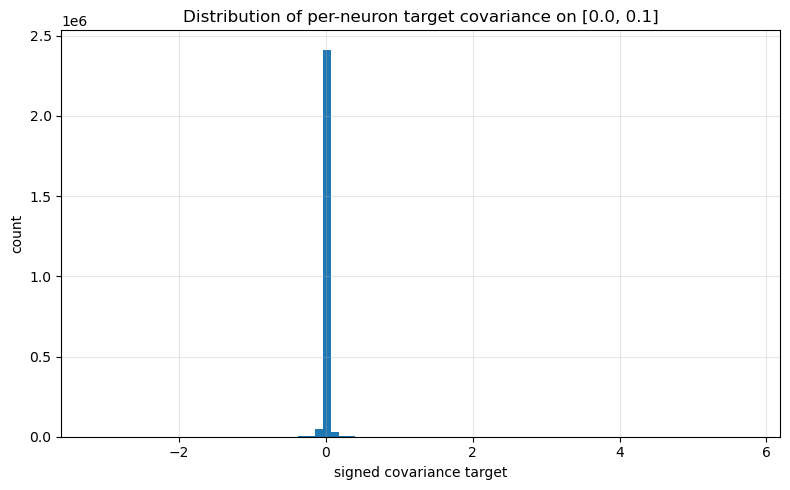

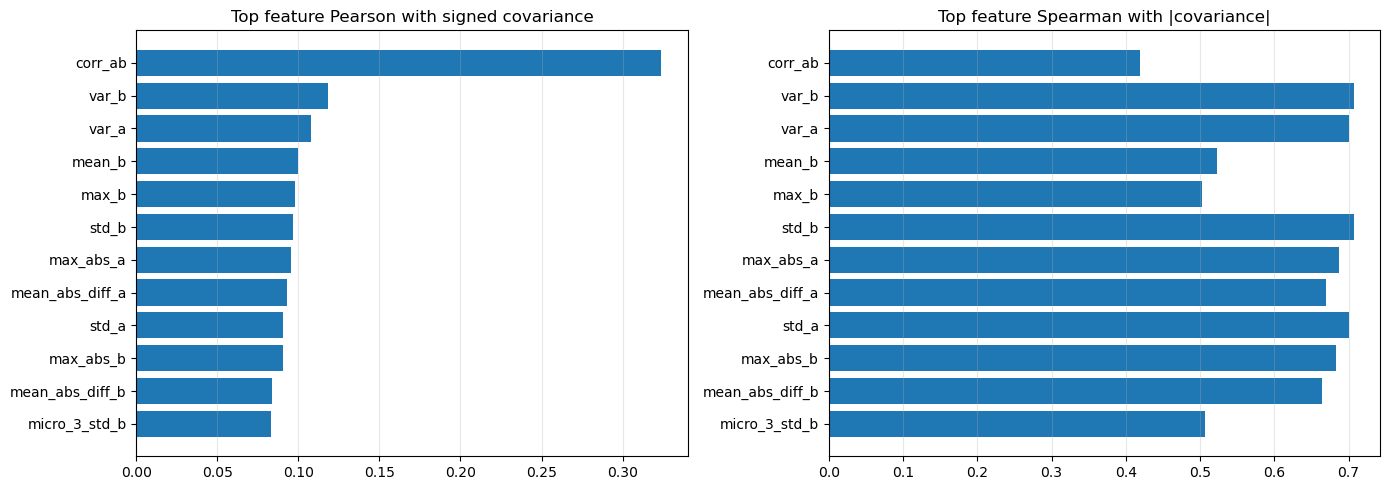

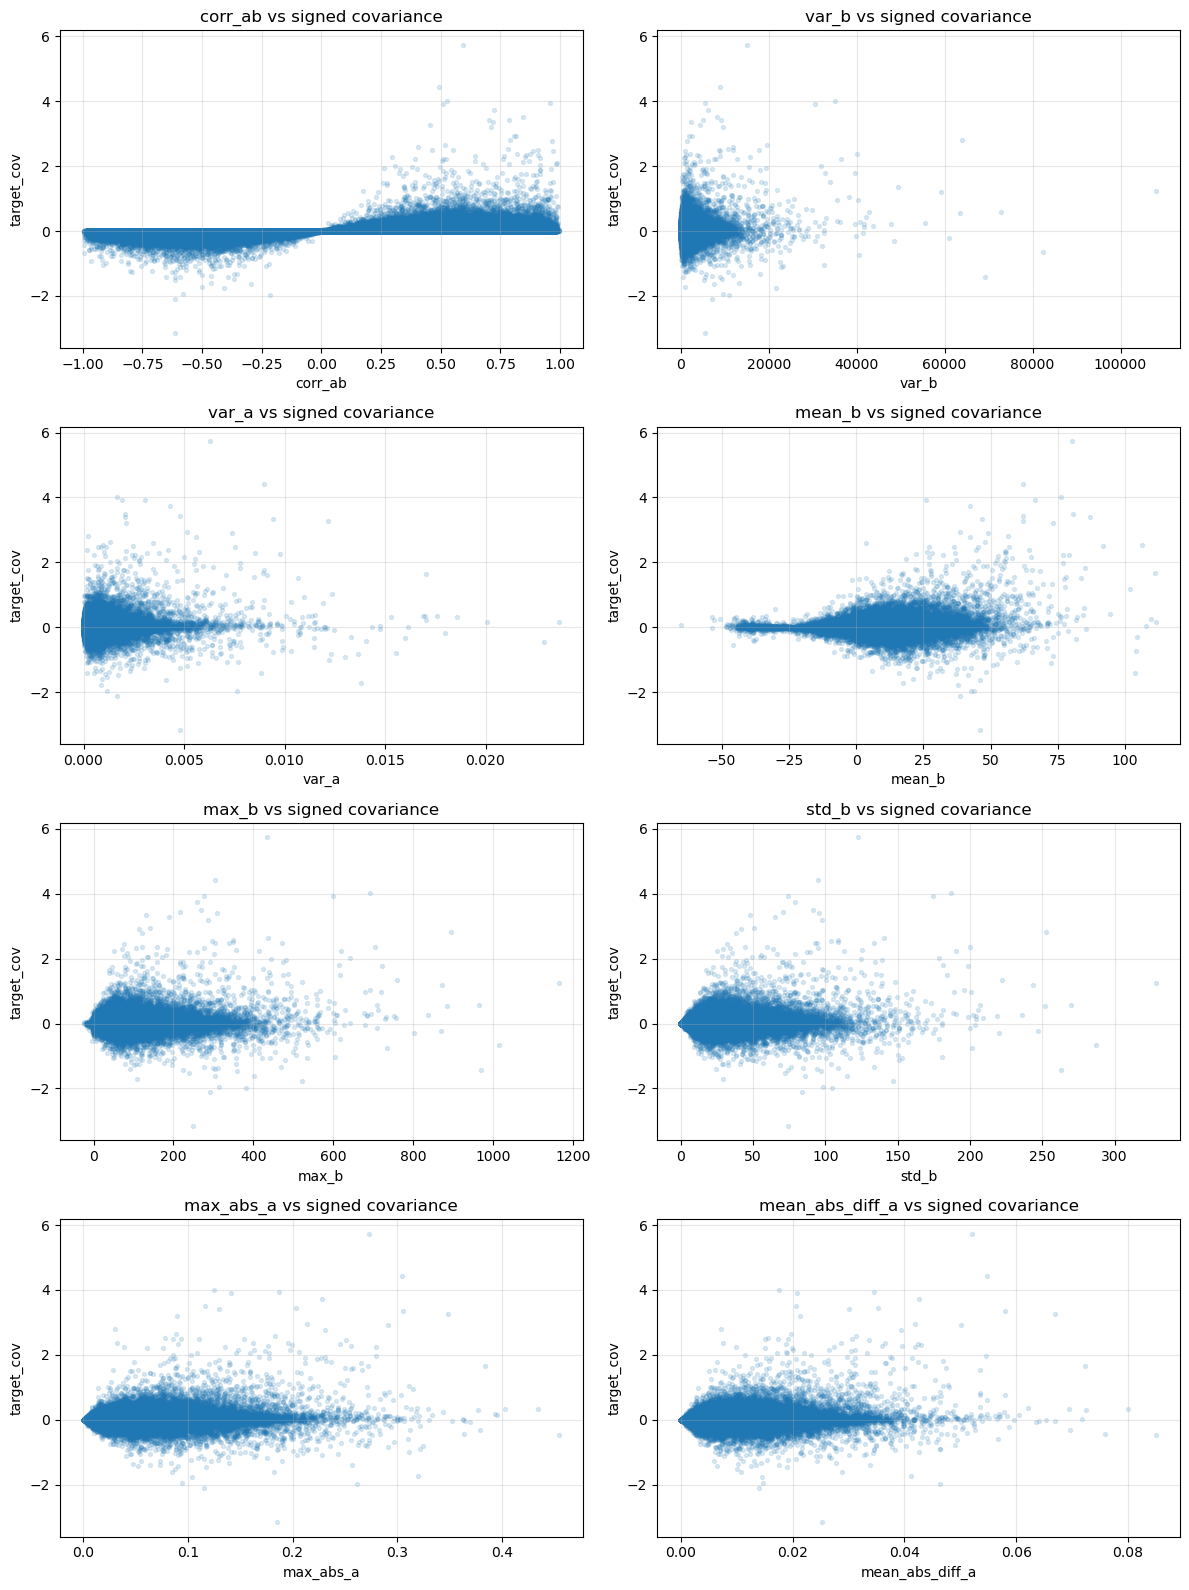

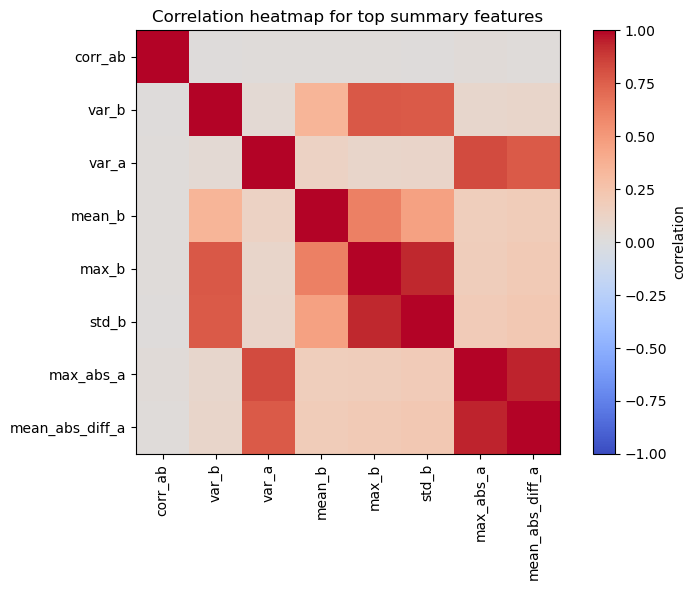

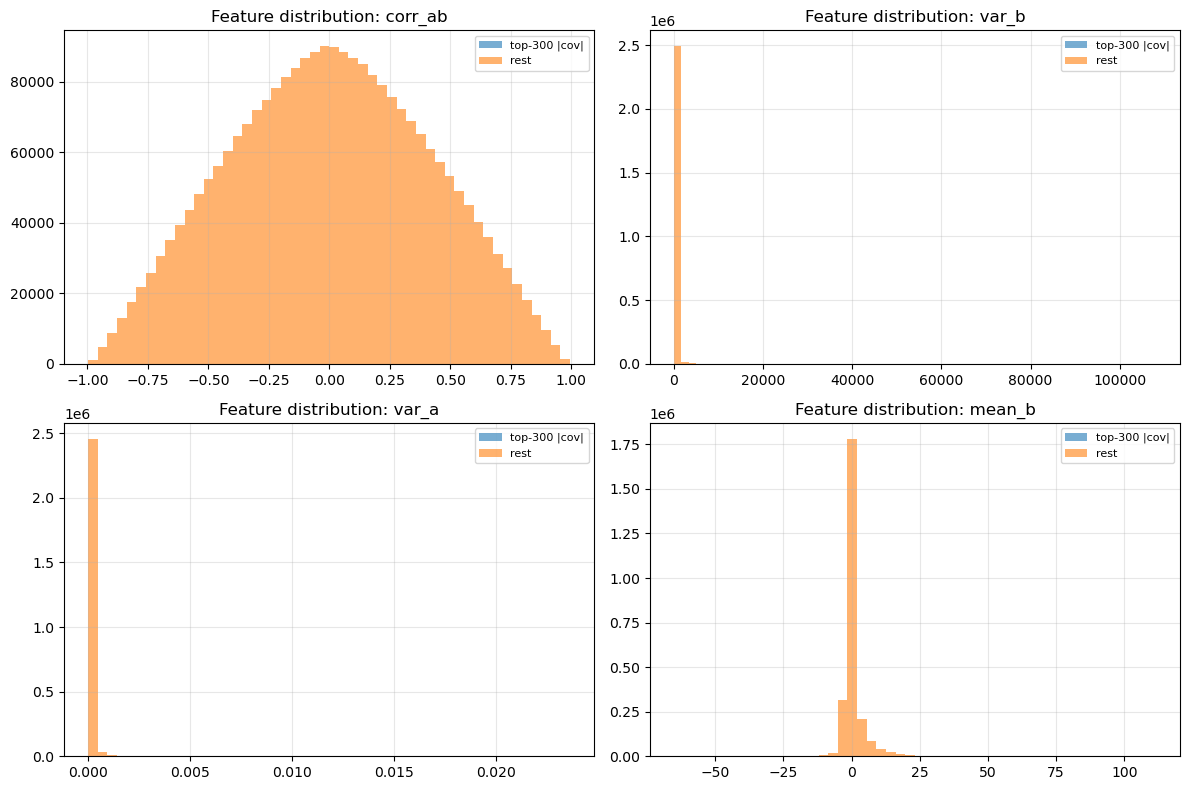

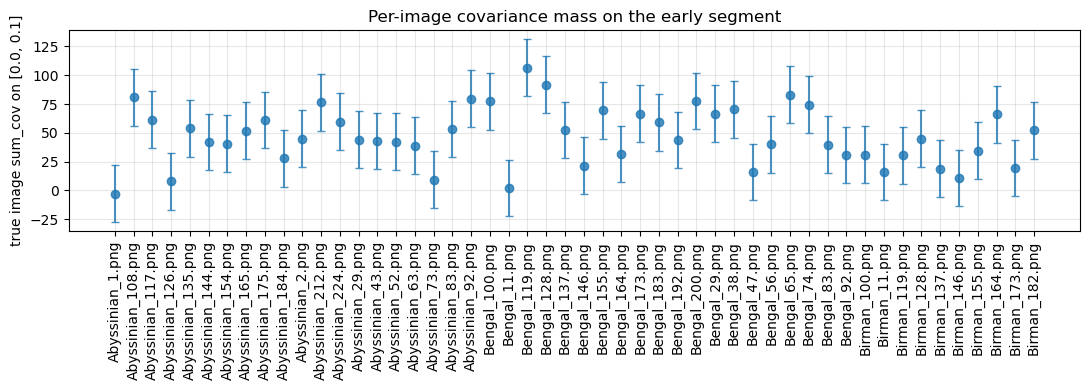

Regression dataset summary:
  rows: 2508800
  images: 50
  segment: (0.0, 0.1)
  num features: 54
  leakage feature hits: []

Feature groups:
  approx_only                  | n= 1 | ['approx_attr']
  base_moments                 | n= 8 | ['mean_a', 'mean_b', 'std_a', 'std_b', 'var_a', 'var_b', 'corr_ab', 'approx_attr']
  dynamics_endpoints           | n=16 | ['sign_flip_a', 'sign_flip_b', 'mean_abs_diff_a', 'mean_abs_diff_b', 'a_first', 'a_last', 'b_first', 'b_last', 'delta_a_endpoint', 'delta_b_endpoint', 'max_abs_a', 'max_abs_b', 'min_a', 'max_a', 'min_b', 'max_b']
  micro_segments               | n=20 | ['micro_0_mean_a', 'micro_0_mean_b', 'micro_0_std_a', 'micro_0_std_b', 'micro_1_mean_a', 'micro_1_mean_b', 'micro_1_std_a', 'micro_1_std_b', 'micro_2_mean_a', 'micro_2_mean_b', 'micro_2_std_a', 'micro_2_std_b', 'micro_3_mean_a', 'micro_3_mean_b', 'micro_3_std_a', 'micro_3_std_b', 'micro_4_mean_a', 'micro_4_mean_b', 'micro_4_std_a', 'micro_4_std_b']
  image_context                | n=

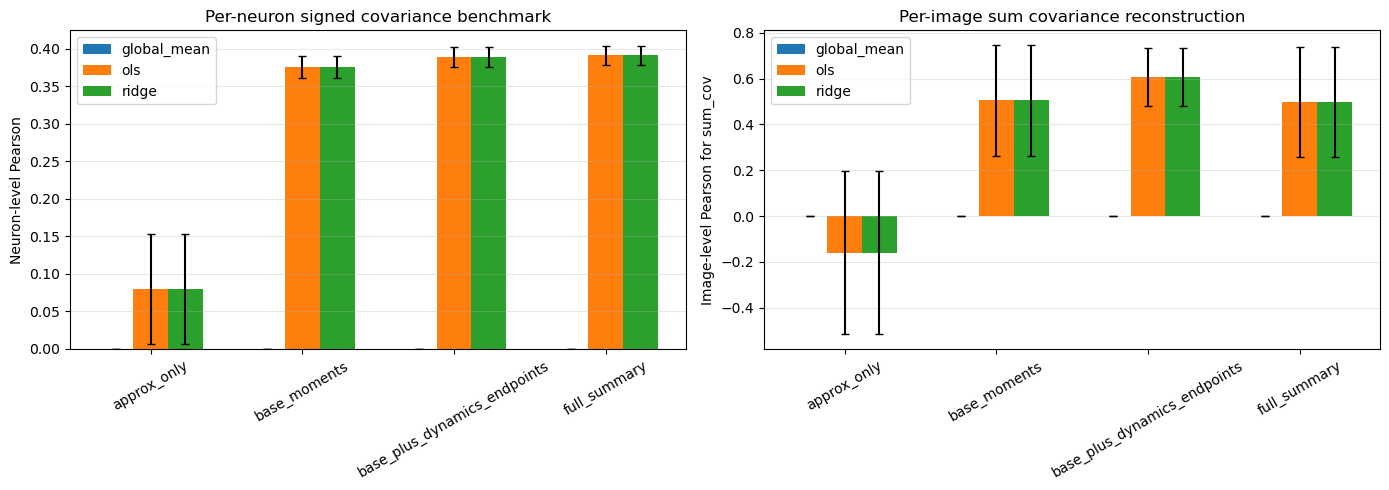

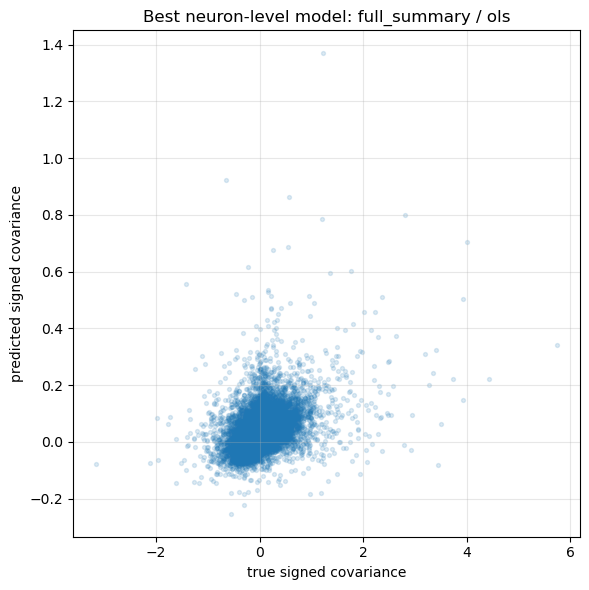

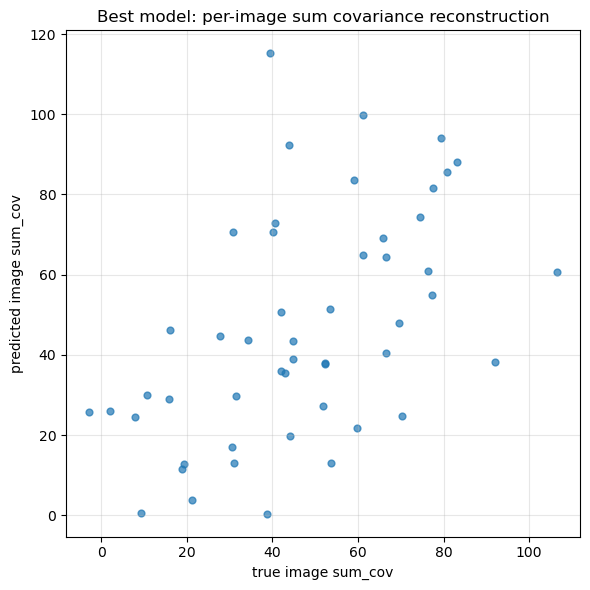

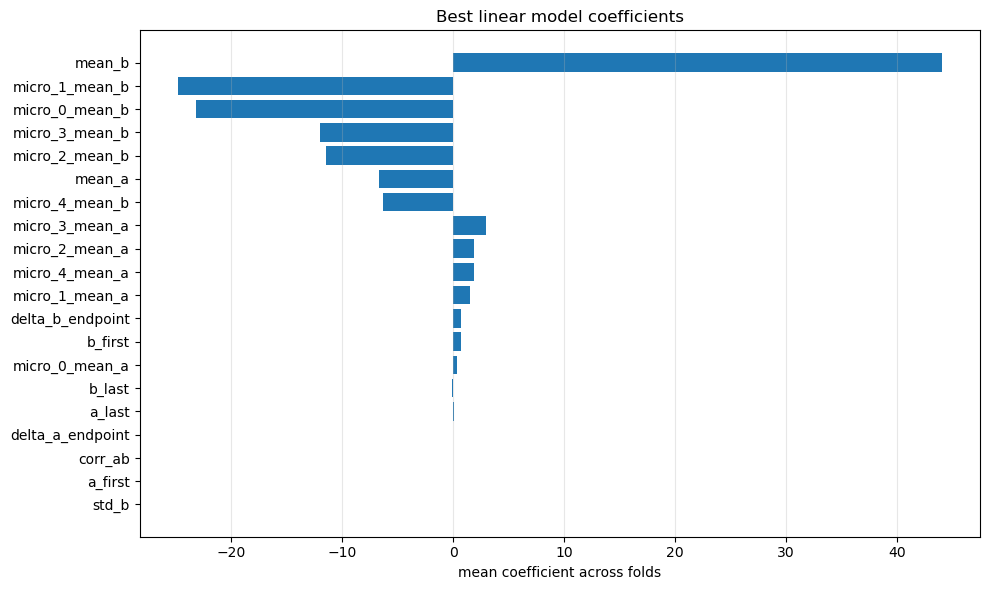

In [42]:

cov_regression_result = run_covariance_regression_benchmark(
    folder_path="../stats/oxford_padded",
    n=50,
    layer_name="model.6",
    n_steps=128,
    clear_every=8,
    segment_start=0.0,
    segment_end=0.1,
    micro_bins=5,
    n_splits=5,
    seed=13,
    ridge_alpha=1.0,
)